In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA RTX 5000 Ada Generation


Generating population data...
Source particles shape: torch.Size([500, 20, 2])
  = 500 patients × 20 particles × 2 dimensions
  Each patient is a DISTRIBUTION, not a point.

TRAINING WFM Network
Each training step:
  1. Sample B source patients (each = K particles)
  2. Sample B target patients (each = K particles)
  3. Level 2 OT: optimally pair source ↔ target patients
  4. Level 1 OT: within each pair, match particles
  5. Interpolate along geodesic: x_t = (1-t)x + t*T*(x)
  6. Regress network onto velocity: u_t = T*(x) - x



WFM: 100%|██████████| 8000/8000 [09:14<00:00, 14.43it/s]


WFM final loss: 0.55626

TRAINING Standard CFM (comparison)


Standard CFM: 100%|██████████| 8000/8000 [00:19<00:00, 411.51it/s]


Standard CFM final loss: 0.90426

Evaluating on test patients...


Evaluating: 100%|██████████| 100/100 [00:13<00:00,  7.37it/s]



Metric                           Standard CFM        WFM
────────────────────────────────────────────────────────
Mean position error                    2.2668     2.2489
Spread (σ) error               N/A (collapsed)     0.1031

Standard CFM cannot predict spread — it outputs a single point.
WFM outputs a full distribution, capturing both mean AND spread.


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/wfm_population_evolution.png'

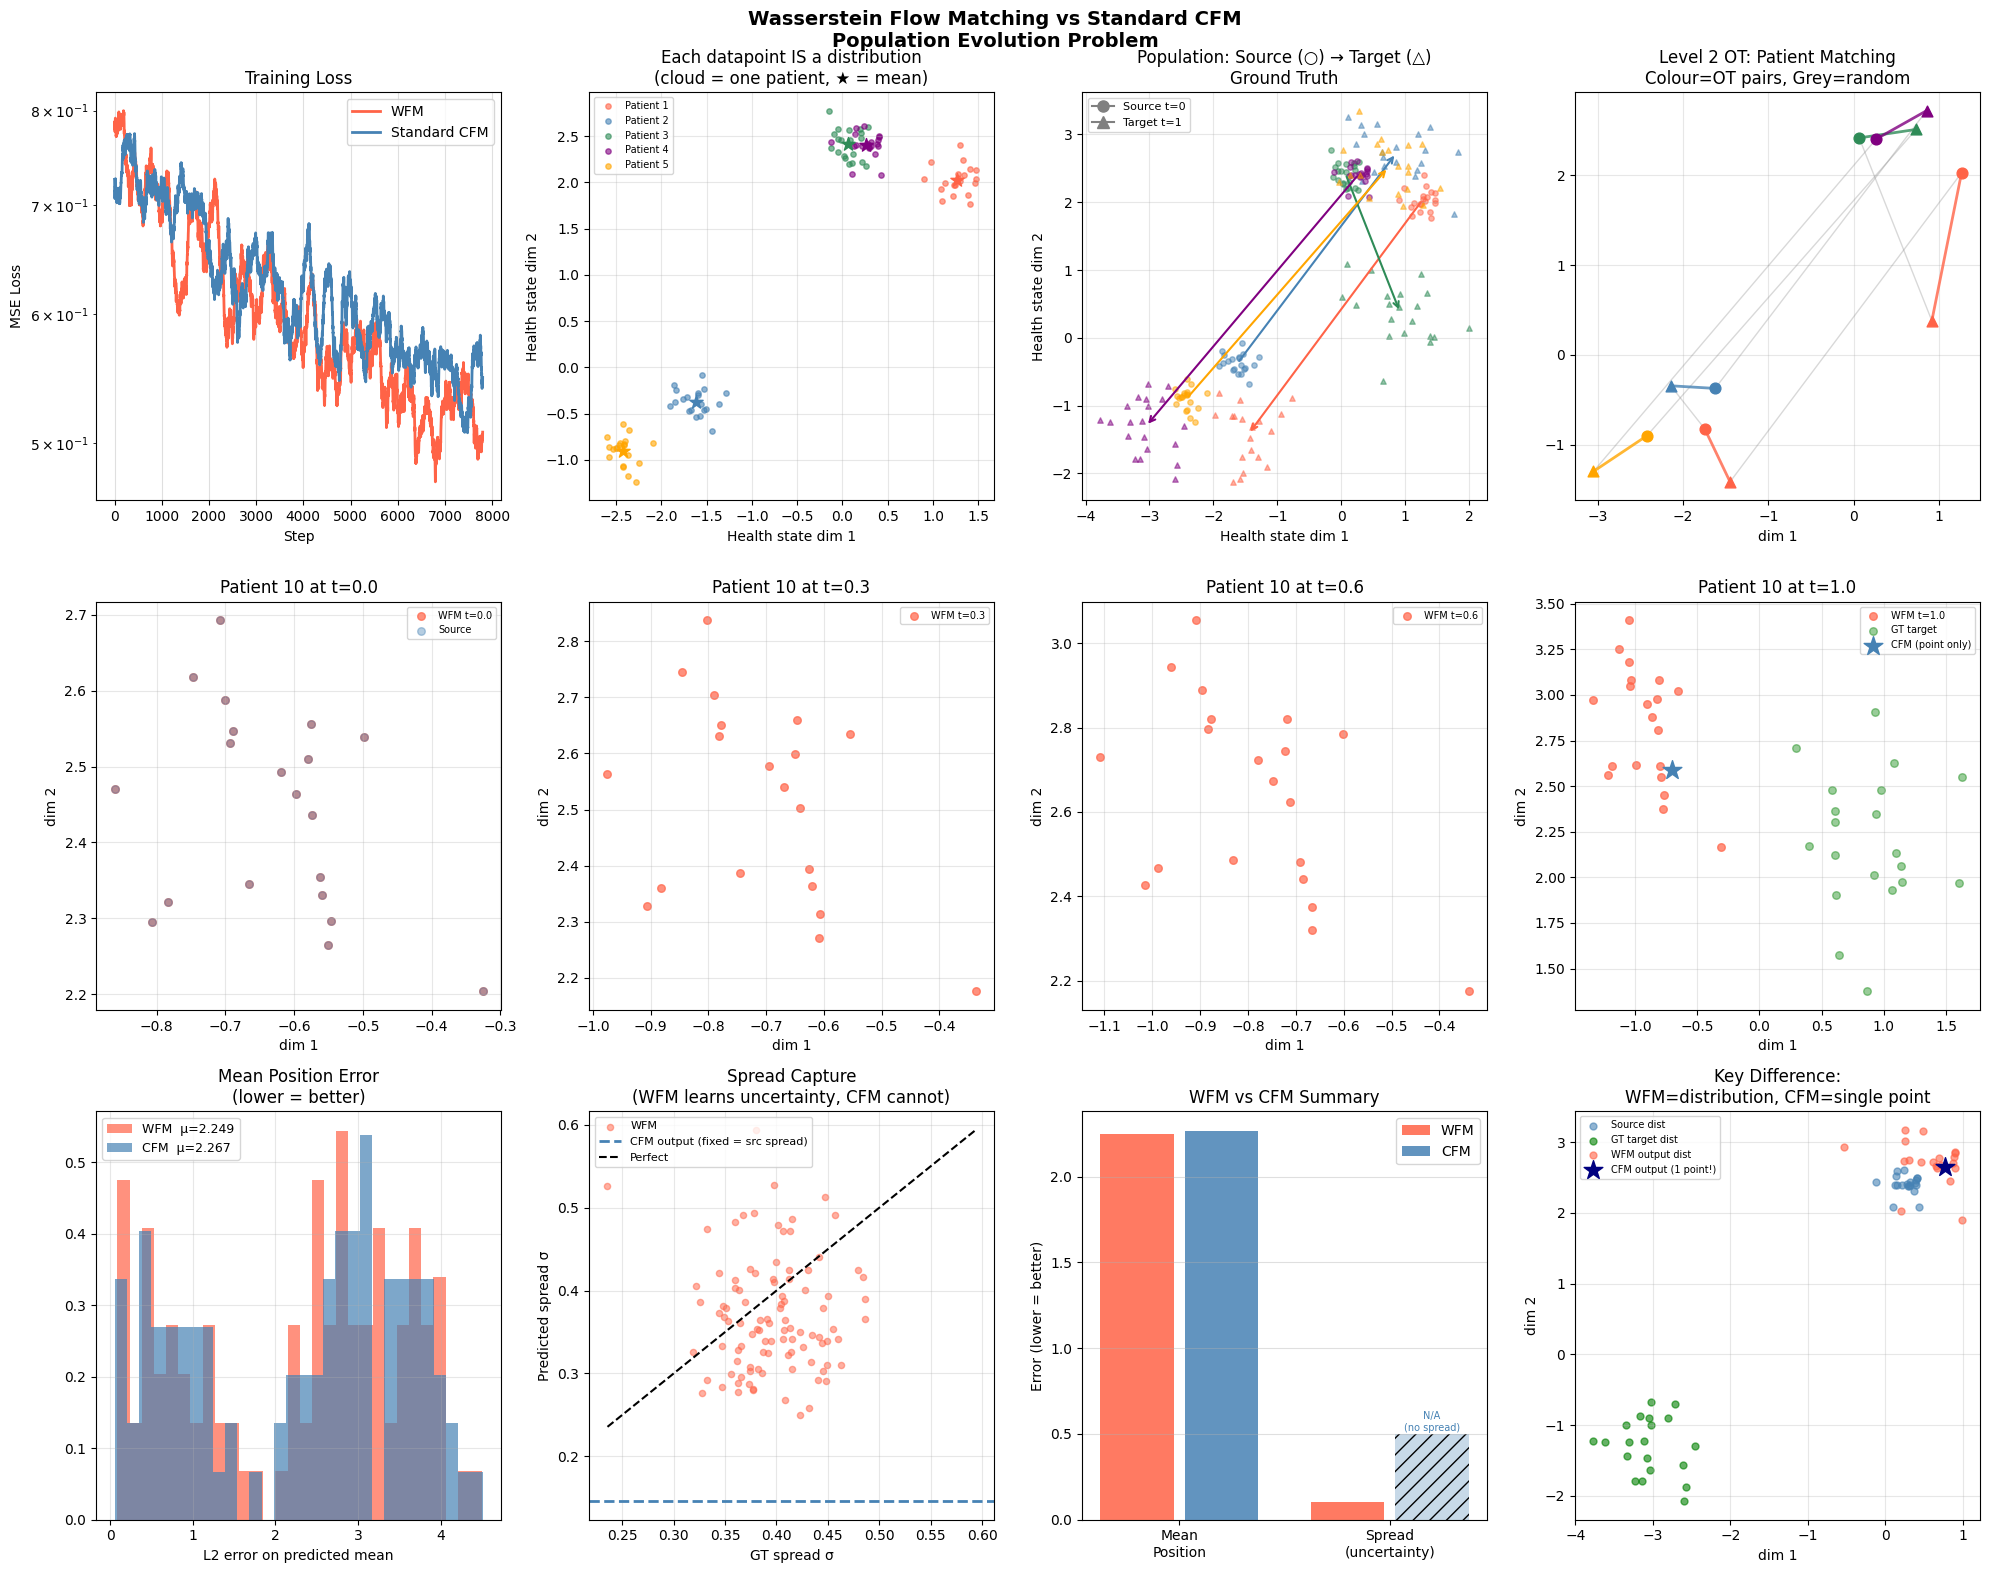

In [ ]:
"""
=============================================================
  WASSERSTEIN FLOW MATCHING — Population Evolution Example
=============================================================

THE PROBLEM:
  We have a population of "patients". Each patient is NOT a point —
  each patient IS a distribution over health states x ∈ R².

  At time t=0:  each patient has a NARROW distribution (certain state)
  At time t=1:  each patient has a WIDER, SHIFTED distribution (evolved)

  We want to learn the flow:
      Ω_0  (population of source distributions)
        →
      Ω_1  (population of target distributions)

  Standard CFM CANNOT do this naturally — it moves points, not distributions.
  WFM CAN — each "datapoint" is a cloud of K particles representing μ.

THE MATH BEING IMPLEMENTED:
  1. Each patient μ is represented as K particles {x¹,...,xᴷ} ~ μ
  2. OT map T* pairs source particles to target particles optimally
  3. Geodesic: x_t = (1-t)*x + t*T*(x)
  4. Velocity:  u_t = T*(x) - x
  5. Network:   v_θ({x_t^i}, t) → {u_t^i}  (set → set, uses attention)
  6. Loss:      E|| v_θ(x_t, context_t, t) - u_t ||²

TWO LEVELS:
  Level 1 (inside patient): particles x ∈ R²
  Level 2 (across patients): distributions μ ∈ P(R²)

COMPARISON:
  Standard CFM — treats each patient as a SINGLE POINT (mean of their dist)
  WFM          — treats each patient as a FULL DISTRIBUTION (K particles)
=============================================================
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cpu")

# ─────────────────────────────────────────────────────────────
# HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────
N_PATIENTS   = 500    # number of patients in population
K_PARTICLES  = 20    # particles per patient (represents μ)
D_STATE      = 2     # health state dimension
D_HIDDEN     = 64    # network width
EPOCHS       = 8000
BATCH_SIZE   = 32    # patients per batch
LR           = 1e-3

# ─────────────────────────────────────────────────────────────
# 1. DATA GENERATION
#    Each patient is parameterised by a "patient type" θ ∈ R²
#    Source: narrow distributions (low uncertainty)
#    Target: wider, shifted distributions (evolved state)
# ─────────────────────────────────────────────────────────────

def generate_population(n_patients, k_particles, split='source'):
    """
    Generate a population where each patient = K particles from their dist.

    Patient type θ = (θ₁, θ₂) drawn from a mixture of 3 Gaussians.
    This gives us 3 "subtypes" of patients.

    Source distribution for patient θ:
        μ_θ^source = N(θ, σ_source² I)   ← narrow

    Target distribution for patient θ:
        μ_θ^target = N(f(θ), σ_target² I)  ← wider, nonlinearly shifted
        f(θ) = (θ₁ + 0.5*sin(πθ₁), θ₂ + 0.5*cos(πθ₂))
    """
    # Patient types: 3-cluster mixture
    centers = np.array([[-2.0, -1.0],
                         [ 2.0, -1.0],
                         [ 0.0,  2.0]])
    assign  = np.random.randint(0, 3, n_patients)
    theta   = centers[assign] + np.random.randn(n_patients, 2) * 0.4

    if split == 'source':
        sigma = 0.15   # narrow source distributions
        means = theta
    else:
        sigma = 0.40   # wider target distributions
        # Nonlinear shift — this is what makes WFM hard
        means = np.stack([
            theta[:, 0] + 0.5 * np.sin(np.pi * theta[:, 0]),
            theta[:, 1] + 0.5 * np.cos(np.pi * theta[:, 1])
        ], axis=1)

    # For each patient, sample K particles from their distribution
    # Shape: (n_patients, k_particles, d_state)
    particles = means[:, None, :] + sigma * np.random.randn(n_patients, k_particles, D_STATE)

    return torch.tensor(particles, dtype=torch.float32), \
           torch.tensor(theta,     dtype=torch.float32), \
           torch.tensor(means,     dtype=torch.float32)


print("Generating population data...")
src_particles, src_theta, src_means = generate_population(N_PATIENTS, K_PARTICLES, 'source')
tgt_particles, tgt_theta, tgt_means = generate_population(N_PATIENTS, K_PARTICLES, 'target')

# src_particles: (N_PATIENTS, K_PARTICLES, D_STATE)
# Each row = one patient = K particles from their health state distribution

print(f"Source particles shape: {src_particles.shape}")
print(f"  = {N_PATIENTS} patients × {K_PARTICLES} particles × {D_STATE} dimensions")
print(f"  Each patient is a DISTRIBUTION, not a point.")


# ─────────────────────────────────────────────────────────────
# 2. MINI-BATCH OT MATCHING  (the core of WFM)
#
#    TWO LEVELS of OT here:
#
#    Level 2 OT: match SOURCE patients to TARGET patients optimally
#                Cost between two patients = W2 distance between their dists
#                (approximated as mean squared distance between particle sets)
#
#    Level 1 OT: within each (μ_src, μ_tgt) pair, match particles optimally
#                This gives the geodesic inside each patient's distribution
# ─────────────────────────────────────────────────────────────

def w2_approx(mu_src, mu_tgt):
    """
    Approximate W2² between two distributions represented as particle sets.
    mu_src: (K, D)  mu_tgt: (K, D)
    Returns: scalar cost
    """
    C = cdist(mu_src.numpy(), mu_tgt.numpy(), metric='sqeuclidean')
    row_ind, col_ind = linear_sum_assignment(C)
    return C[row_ind, col_ind].mean()


def ot_match_patients(src_batch, tgt_batch):
    """
    Level 2 OT: optimally pair source patients with target patients.

    src_batch: (B, K, D)  — B patients, each with K particles
    tgt_batch: (B, K, D)

    Returns: tgt_batch reordered to optimally pair with src_batch
    """
    B = src_batch.shape[0]

    # Cost matrix between patients: approximate W2 distance
    C = np.zeros((B, B))
    for i in range(B):
        for j in range(B):
            # Use mean distance as cheap proxy for W2
            C[i, j] = np.sum((src_batch[i].mean(0).numpy() -
                               tgt_batch[j].mean(0).numpy()) ** 2)

    row_ind, col_ind = linear_sum_assignment(C)
    return tgt_batch[col_ind]   # reordered target patients


def ot_match_particles(src_cloud, tgt_cloud):
    """
    Level 1 OT: for a single (μ_src, μ_tgt) pair,
    optimally match particles inside each distribution.

    src_cloud: (K, D)
    tgt_cloud: (K, D)

    Returns: tgt_cloud reordered to optimally pair with src_cloud
    """
    C = cdist(src_cloud.numpy(), tgt_cloud.numpy(), metric='sqeuclidean')
    row_ind, col_ind = linear_sum_assignment(C)
    return tgt_cloud[col_ind]


# ─────────────────────────────────────────────────────────────
# 3. THE WFM NETWORK  (set → set with attention)
#
#    Input for each patient at time t:
#      - K particle positions {x_t^i} ∈ R^D    (the current cloud)
#      - time t ∈ [0,1]
#
#    The key: each particle's velocity depends on the WHOLE CLOUD
#    because the network must understand the current distribution shape.
#    We use self-attention to let particles communicate.
#
#    Output: velocity u_t^i ∈ R^D  for each particle
# ─────────────────────────────────────────────────────────────

class WFMNetwork(nn.Module):
    """
    Set-to-set network for Wasserstein Flow Matching.

    Architecture:
      1. Embed each particle + time → hidden dim
      2. Self-attention: particles exchange information
         (so each particle "sees" the whole distribution)
      3. Decode → velocity for each particle

    This is what makes WFM different from standard CFM:
    the velocity of particle i depends on ALL particles {x_t^j},
    not just x_t^i alone.
    """
    def __init__(self, d_state=2, d_hidden=64, n_heads=4, n_layers=2):
        super().__init__()
        self.d_state  = d_state
        self.d_hidden = d_hidden

        # Embed particle + time into hidden space
        # Input: (x, t) = D + 1 dimensions
        self.embed = nn.Sequential(
            nn.Linear(d_state + 1, d_hidden),
            nn.SELU(),
            nn.Linear(d_hidden, d_hidden)
        )

        # Self-attention layers — particles talk to each other
        # This is the set-processing part
        encoder_layer = nn.TransformerEncoderLayer(
            d_model    = d_hidden,
            nhead      = n_heads,
            dim_feedforward = d_hidden * 2,
            dropout    = 0.0,
            batch_first = True    # (batch, seq, feature)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Decode to velocity
        self.decode = nn.Sequential(
            nn.Linear(d_hidden, d_hidden),
            nn.SELU(),
            nn.Linear(d_hidden, d_state)
        )

    def forward(self, x_t, t):
        """
        x_t: (B, K, D)   — B patients, K particles each, D dims
        t:   (B, 1)       — time for each patient in batch

        Returns: velocities (B, K, D)
        """
        B, K, D = x_t.shape

        # Broadcast time to each particle: (B, K, 1)
        t_exp = t.unsqueeze(1).expand(B, K, 1)

        # Concatenate position + time for each particle: (B, K, D+1)
        inp = torch.cat([x_t, t_exp], dim=-1)

        # Embed: (B, K, d_hidden)
        h = self.embed(inp)

        # Self-attention across particles in same patient: (B, K, d_hidden)
        # Each particle now has context about the whole cloud
        h = self.transformer(h)

        # Decode to velocity: (B, K, D)
        v = self.decode(h)

        return v


# ─────────────────────────────────────────────────────────────
# 4. STANDARD CFM NETWORK  (for comparison)
#    Treats each patient as a SINGLE POINT (their mean)
#    Standard architecture — no attention needed
# ─────────────────────────────────────────────────────────────

class StandardCFM(nn.Module):
    """
    Standard CFM: treats each patient as a single point (mean of their dist).
    Input:  (x_t, t) where x_t ∈ R^D is the mean position
    Output: velocity ∈ R^D

    This IGNORES the distributional nature of each patient.
    """
    def __init__(self, d_state=2, d_hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_state + 1, d_hidden), nn.SELU(),
            nn.Linear(d_hidden, d_hidden),    nn.SELU(),
            nn.Linear(d_hidden, d_hidden),    nn.SELU(),
            nn.Linear(d_hidden, d_state)
        )

    def forward(self, x_t, t):
        """
        x_t: (B, D)
        t:   (B, 1)
        Returns: (B, D)
        """
        inp = torch.cat([x_t, t], dim=-1)
        return self.net(inp)


# ─────────────────────────────────────────────────────────────
# 5. TRAINING — WFM
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("TRAINING WFM Network")
print("="*60)
print("Each training step:")
print("  1. Sample B source patients (each = K particles)")
print("  2. Sample B target patients (each = K particles)")
print("  3. Level 2 OT: optimally pair source ↔ target patients")
print("  4. Level 1 OT: within each pair, match particles")
print("  5. Interpolate along geodesic: x_t = (1-t)x + t*T*(x)")
print("  6. Regress network onto velocity: u_t = T*(x) - x\n")

wfm_model = WFMNetwork(D_STATE, D_HIDDEN).to(DEVICE)
wfm_opt   = optim.AdamW(wfm_model.parameters(), lr=LR)
wfm_losses = []

for step in tqdm(range(EPOCHS), desc="WFM"):

    # ── Sample a batch of patients ──────────────────────────
    idx = torch.randint(0, N_PATIENTS, (BATCH_SIZE,))

    src_batch = src_particles[idx]   # (B, K, D) source clouds
    tgt_batch = tgt_particles[idx]   # (B, K, D) target clouds

    # ── Level 2 OT: match patients across the batch ─────────
    tgt_batch = ot_match_patients(src_batch, tgt_batch)  # (B, K, D)

    # ── Level 1 OT: match particles within each patient ─────
    x0 = torch.zeros_like(src_batch)   # (B, K, D)
    x1 = torch.zeros_like(tgt_batch)
    for b in range(BATCH_SIZE):
        x0[b] = src_batch[b]
        x1[b] = ot_match_particles(src_batch[b], tgt_batch[b])

    # ── Interpolate along geodesic ───────────────────────────
    t = torch.rand(BATCH_SIZE, device=DEVICE)   # (B,)

    # x_t = (1-t)*x0 + t*x1   for each patient and each particle
    t_exp = t.view(BATCH_SIZE, 1, 1)            # (B, 1, 1)
    x_t   = (1 - t_exp) * x0 + t_exp * x1      # (B, K, D)

    # ── True velocity: u_t = x1 - x0 ────────────────────────
    u_t = x1 - x0                               # (B, K, D)

    # ── Network prediction ───────────────────────────────────
    # Network sees the whole cloud at time t
    v_pred = wfm_model(x_t, t.view(BATCH_SIZE, 1))   # (B, K, D)

    # ── Loss ─────────────────────────────────────────────────
    loss = ((v_pred - u_t) ** 2).mean()

    wfm_opt.zero_grad()
    loss.backward()
    wfm_opt.step()
    wfm_losses.append(loss.item())

print(f"WFM final loss: {wfm_losses[-1]:.5f}")


# ─────────────────────────────────────────────────────────────
# 6. TRAINING — Standard CFM (comparison baseline)
#    Treats each patient as their mean point only
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("TRAINING Standard CFM (comparison)")
print("="*60)

cfm_model  = StandardCFM(D_STATE, D_HIDDEN).to(DEVICE)
cfm_opt    = optim.AdamW(cfm_model.parameters(), lr=LR)
cfm_losses = []

for step in tqdm(range(EPOCHS), desc="Standard CFM"):
    idx = torch.randint(0, N_PATIENTS, (BATCH_SIZE,))

    # Represent each patient as their MEAN ONLY (ignores spread)
    x0_mean = src_particles[idx].mean(dim=1)   # (B, D)
    x1_mean = tgt_particles[idx].mean(dim=1)   # (B, D)

    # OT match patients by their means
    C = cdist(x0_mean.numpy(), x1_mean.numpy(), metric='sqeuclidean')
    _, col_ind = linear_sum_assignment(C)
    x1_mean = x1_mean[col_ind]

    t     = torch.rand(BATCH_SIZE, 1, device=DEVICE)
    x_t   = (1 - t) * x0_mean + t * x1_mean
    u_t   = x1_mean - x0_mean

    v_pred = cfm_model(x_t, t)
    loss   = ((v_pred - u_t) ** 2).mean()

    cfm_opt.zero_grad()
    loss.backward()
    cfm_opt.step()
    cfm_losses.append(loss.item())

print(f"Standard CFM final loss: {cfm_losses[-1]:.5f}")


# ─────────────────────────────────────────────────────────────
# 7. INFERENCE
#    Given a new source patient (K particles),
#    evolve them to t=1 using the learned velocity field.
# ─────────────────────────────────────────────────────────────

@torch.no_grad()
def wfm_sample(model, src_cloud, steps=100):
    """
    Evolve one patient's distribution from t=0 to t=1.

    src_cloud: (K, D) — source particles for one patient
    Returns:   (K, D) — evolved particles at t=1
    """
    model.eval()
    x  = src_cloud.unsqueeze(0)   # (1, K, D) — batch of 1 patient
    dt = 1.0 / steps

    for i in range(steps):
        t_val = torch.tensor([[i * dt]], dtype=torch.float32)
        v     = model(x, t_val)    # (1, K, D)
        x     = x + dt * v

    return x.squeeze(0)            # (K, D)


@torch.no_grad()
def cfm_sample(model, src_mean, steps=100):
    """
    Evolve one patient's MEAN from t=0 to t=1.
    Standard CFM — only knows about the mean, not the spread.
    """
    model.eval()
    x  = src_mean.unsqueeze(0)    # (1, D)
    dt = 1.0 / steps

    for i in range(steps):
        t_val = torch.tensor([[i * dt]], dtype=torch.float32)
        v     = model(x, t_val)
        x     = x + dt * v

    return x.squeeze(0)            # (D,)


# ─────────────────────────────────────────────────────────────
# 8. EVALUATION
#    Compare WFM vs Standard CFM vs Ground Truth
#    Metrics:
#      - Mean position error (how well do we predict where patient ends up)
#      - Spread error (how well do we capture the uncertainty/width)
#        THIS is what standard CFM cannot do — it collapses to a point
# ─────────────────────────────────────────────────────────────

print("\nEvaluating on test patients...")

N_TEST = 100
test_src, test_theta, _ = generate_population(N_TEST, K_PARTICLES, 'source')
test_tgt, _,         _  = generate_population(N_TEST, K_PARTICLES, 'target')

wfm_mean_errors   = []
wfm_spread_errors = []
cfm_mean_errors   = []

for i in tqdm(range(N_TEST), desc="Evaluating"):
    src_cloud = test_src[i]   # (K, D)
    tgt_cloud = test_tgt[i]   # (K, D)

    # Ground truth stats for this patient
    gt_mean   = tgt_cloud.mean(0)    # (D,)
    gt_spread = tgt_cloud.std(0)     # (D,) — distributional width

    # WFM prediction: evolves full distribution
    wfm_out    = wfm_sample(wfm_model, src_cloud)
    wfm_mean   = wfm_out.mean(0)
    wfm_spread = wfm_out.std(0)

    # Standard CFM prediction: only predicts mean
    cfm_out    = cfm_sample(cfm_model, src_cloud.mean(0))

    wfm_mean_errors.append(  float(((wfm_mean   - gt_mean  )**2).mean().sqrt()))
    wfm_spread_errors.append(float(((wfm_spread - gt_spread)**2).mean().sqrt()))
    cfm_mean_errors.append(  float(((cfm_out    - gt_mean  )**2).mean().sqrt()))

print(f"\n{'Metric':<30} {'Standard CFM':>14} {'WFM':>10}")
print("─"*56)
print(f"{'Mean position error':<30} {np.mean(cfm_mean_errors):>14.4f} {np.mean(wfm_mean_errors):>10.4f}")
print(f"{'Spread (σ) error':<30} {'N/A (collapsed)':>14} {np.mean(wfm_spread_errors):>10.4f}")
print(f"\nStandard CFM cannot predict spread — it outputs a single point.")
print(f"WFM outputs a full distribution, capturing both mean AND spread.")


# ─────────────────────────────────────────────────────────────
# 9. PLOTTING
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 16))
fig.suptitle("Wasserstein Flow Matching vs Standard CFM\nPopulation Evolution Problem",
             fontsize=14, fontweight='bold')

# ── Plot 1: Training losses ───────────────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
w = 200
def smooth(x, w):
    return np.convolve(x, np.ones(w)/w, mode='valid')

ax1.semilogy(smooth(wfm_losses, w), color='tomato',    label='WFM',          linewidth=2)
ax1.semilogy(smooth(cfm_losses, w), color='steelblue', label='Standard CFM', linewidth=2)
ax1.set_title("Training Loss")
ax1.set_xlabel("Step")
ax1.set_ylabel("MSE Loss")
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── Plot 2: What "each datapoint" looks like ─────────────────
ax2 = fig.add_subplot(3, 4, 2)
colors_pat = ['tomato', 'steelblue', 'seagreen', 'purple', 'orange']
for p in range(5):
    cloud = src_particles[p].numpy()
    ax2.scatter(cloud[:, 0], cloud[:, 1], s=15, alpha=0.6,
                color=colors_pat[p], label=f'Patient {p+1}')
    ax2.scatter(*cloud.mean(0), s=100, color=colors_pat[p],
                marker='*', zorder=5)
ax2.set_title("Each datapoint IS a distribution\n(cloud = one patient, ★ = mean)")
ax2.set_xlabel("Health state dim 1")
ax2.set_ylabel("Health state dim 2")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Population at t=0 vs t=1 (ground truth) ──────────
ax3 = fig.add_subplot(3, 4, 3)
# Plot 5 patients' source and target clouds
for p in range(5):
    s_cloud = src_particles[p].numpy()
    t_cloud = tgt_particles[p].numpy()
    ax3.scatter(s_cloud[:, 0], s_cloud[:, 1], s=15, alpha=0.5,
                color=colors_pat[p], marker='o')
    ax3.scatter(t_cloud[:, 0], t_cloud[:, 1], s=15, alpha=0.5,
                color=colors_pat[p], marker='^')
    # Arrow from source mean to target mean
    sm = s_cloud.mean(0)
    tm = t_cloud.mean(0)
    ax3.annotate('', xy=tm, xytext=sm,
                 arrowprops=dict(arrowstyle='->', color=colors_pat[p], lw=1.5))

ax3.set_title("Population: Source (○) → Target (△)\nGround Truth")
ax3.set_xlabel("Health state dim 1")
ax3.set_ylabel("Health state dim 2")
from matplotlib.lines import Line2D
ax3.legend(handles=[
    Line2D([0],[0], marker='o', color='grey', markersize=8, label='Source t=0'),
    Line2D([0],[0], marker='^', color='grey', markersize=8, label='Target t=1'),
], fontsize=8)
ax3.grid(True, alpha=0.3)

# ── Plot 4: The two-level OT illustrated ─────────────────────
ax4 = fig.add_subplot(3, 4, 4)
b_demo = 6
src_demo = src_particles[:b_demo]
tgt_demo = tgt_particles[:b_demo]

# Show random pairing (grey)
for i in range(b_demo):
    sm = src_demo[i].mean(0).numpy()
    tm = tgt_demo[i].mean(0).numpy()
    ax4.plot([sm[0], tm[0]], [sm[1], tm[1]], 'grey', alpha=0.3, linewidth=1)

# Show OT pairing (coloured)
tgt_ot = ot_match_patients(src_demo, tgt_demo)
for i in range(b_demo):
    sm = src_demo[i].mean(0).numpy()
    tm = tgt_ot[i].mean(0).numpy()
    ax4.plot([sm[0], tm[0]], [sm[1], tm[1]], color=colors_pat[i % 5],
             linewidth=2, alpha=0.8)
    ax4.scatter(*sm, s=60, color=colors_pat[i % 5], marker='o', zorder=4)
    ax4.scatter(*tm, s=60, color=colors_pat[i % 5], marker='^', zorder=4)

ax4.set_title("Level 2 OT: Patient Matching\nColour=OT pairs, Grey=random")
ax4.set_xlabel("dim 1")
ax4.grid(True, alpha=0.3)

# ── Plots 5-7: One patient's flow trajectory ─────────────────
patient_idx = 10
src_cloud   = src_particles[patient_idx]
tgt_cloud   = tgt_particles[patient_idx]

# Evolve the patient step by step to see the trajectory
@torch.no_grad()
def wfm_trajectory(model, src_cloud, steps=10):
    model.eval()
    x  = src_cloud.unsqueeze(0)
    dt = 1.0 / steps
    traj = [x.squeeze(0).numpy().copy()]
    for i in range(steps):
        t_val = torch.tensor([[i * dt]], dtype=torch.float32)
        v     = model(x, t_val)
        x     = x + dt * v
        traj.append(x.squeeze(0).numpy().copy())
    return traj

traj = wfm_trajectory(wfm_model, src_cloud, steps=10)

for step_i, t_label in enumerate([0, 3, 6, 10]):
    ax = fig.add_subplot(3, 4, 5 + step_i)
    cloud_t = traj[t_label]

    ax.scatter(cloud_t[:, 0], cloud_t[:, 1],
               s=30, color='tomato', alpha=0.7, label=f'WFM t={t_label/10:.1f}')

    if t_label == 0:
        ax.scatter(src_cloud[:, 0], src_cloud[:, 1],
                   s=30, color='steelblue', alpha=0.4, label='Source')
    if t_label == 10:
        ax.scatter(tgt_cloud[:, 0], tgt_cloud[:, 1],
                   s=30, color='green', alpha=0.4, label='GT target')
        cfm_pt = cfm_sample(cfm_model, src_cloud.mean(0)).numpy()
        ax.scatter(*cfm_pt, s=200, color='steelblue', marker='*',
                   zorder=5, label='CFM (point only)')

    ax.set_title(f"Patient {patient_idx} at t={t_label/10:.1f}")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# ── Plot 9: Mean error comparison ────────────────────────────
ax9 = fig.add_subplot(3, 4, 9)
ax9.hist(wfm_mean_errors, bins=30, color='tomato',    alpha=0.7, label=f'WFM  μ={np.mean(wfm_mean_errors):.3f}', density=True)
ax9.hist(cfm_mean_errors, bins=30, color='steelblue', alpha=0.7, label=f'CFM  μ={np.mean(cfm_mean_errors):.3f}', density=True)
ax9.set_title("Mean Position Error\n(lower = better)")
ax9.set_xlabel("L2 error on predicted mean")
ax9.legend(fontsize=9)
ax9.grid(True, alpha=0.3)

# ── Plot 10: Spread capture ───────────────────────────────────
ax10 = fig.add_subplot(3, 4, 10)
gt_spreads  = [tgt_particles[i].std(0).mean().item() for i in range(N_TEST)]
wfm_spreads = []
for i in range(N_TEST):
    out = wfm_sample(wfm_model, test_src[i])
    wfm_spreads.append(out.std(0).mean().item())

ax10.scatter(gt_spreads, wfm_spreads, s=20, alpha=0.5, color='tomato', label='WFM')
ax10.axhline(y=src_particles[:N_TEST].std(dim=1).mean(0).mean().item(),
             color='steelblue', linestyle='--', linewidth=2, label='CFM output (fixed = src spread)')
mn = min(min(gt_spreads), min(wfm_spreads))
mx = max(max(gt_spreads), max(wfm_spreads))
ax10.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect')
ax10.set_xlabel("GT spread σ")
ax10.set_ylabel("Predicted spread σ")
ax10.set_title("Spread Capture\n(WFM learns uncertainty, CFM cannot)")
ax10.legend(fontsize=8)
ax10.grid(True, alpha=0.3)

# ── Plot 11: Summary bar ──────────────────────────────────────
ax11 = fig.add_subplot(3, 4, 11)
categories  = ['Mean\nPosition', 'Spread\n(uncertainty)']
wfm_scores  = [np.mean(wfm_mean_errors), np.mean(wfm_spread_errors)]
cfm_scores  = [np.mean(cfm_mean_errors), None]

x_pos = np.arange(2)
ax11.bar(x_pos - 0.2, wfm_scores,        0.35, color='tomato',    alpha=0.85, label='WFM')
ax11.bar([0 + 0.2],   [cfm_scores[0]],   0.35, color='steelblue', alpha=0.85, label='CFM')
ax11.bar([1 + 0.2],   [0.5],             0.35, color='steelblue', alpha=0.3,  hatch='//')
ax11.text(1 + 0.2, 0.52, 'N/A\n(no spread)', ha='center', fontsize=7, color='steelblue')
ax11.set_xticks(x_pos)
ax11.set_xticklabels(categories)
ax11.set_ylabel("Error (lower = better)")
ax11.set_title("WFM vs CFM Summary")
ax11.legend()
ax11.grid(True, axis='y', alpha=0.4)

# ── Plot 12: What WFM captures that CFM cannot ───────────────
ax12 = fig.add_subplot(3, 4, 12)
p_show = 3

src_c   = src_particles[p_show].numpy()
tgt_c   = tgt_particles[p_show].numpy()
wfm_out = wfm_sample(wfm_model, src_particles[p_show]).numpy()
cfm_pt  = cfm_sample(cfm_model, src_particles[p_show].mean(0)).numpy()

ax12.scatter(src_c[:, 0],   src_c[:, 1],   s=25, color='steelblue', alpha=0.6, label='Source dist')
ax12.scatter(tgt_c[:, 0],   tgt_c[:, 1],   s=25, color='green',     alpha=0.6, label='GT target dist')
ax12.scatter(wfm_out[:, 0], wfm_out[:, 1], s=25, color='tomato',    alpha=0.6, label='WFM output dist')
ax12.scatter(*cfm_pt,                       s=200, color='navy',    marker='*', zorder=5, label='CFM output (1 point!)')

ax12.set_title("Key Difference:\nWFM=distribution, CFM=single point")
ax12.set_xlabel("dim 1")
ax12.set_ylabel("dim 2")
ax12.legend(fontsize=7)
ax12.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/wfm_population_evolution.png", dpi=150, bbox_inches='tight')
print("\nPlot saved!")
plt.show()


# ─────────────────────────────────────────────────────────────
# 10. FINAL EXPLANATION
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("WHAT THIS CODE DEMONSTRATES")
print("="*70)
print(f"""
THE PROBLEM:
  Each patient = a distribution (K={K_PARTICLES} particles in R^{D_STATE})
  NOT a single point.
  Goal: learn how the population of distributions evolves from t=0 to t=1.

TWO LEVELS OF OT:
  Level 2 — ot_match_patients():
    Optimally pairs source patient μ_i with target patient μ_j
    Cost = squared distance between their means (W2 proxy)

  Level 1 — ot_match_particles():
    Within each (μ_src, μ_tgt) pair, optimally matches particles
    This gives the geodesic INSIDE each patient's distribution

THE NETWORK (WFMNetwork):
  Input:  cloud of K particles at time t  +  time t
  Key:    self-attention lets each particle "see" the whole cloud
  Output: velocity for each particle

  This is what standard CFM cannot do — its network only sees one point,
  so it cannot learn how the SHAPE (spread, uncertainty) evolves.

RESULTS:
  Standard CFM  → predicts where the mean goes. Shape is lost.
  WFM           → predicts how the full distribution evolves.
                  Captures both mean position AND uncertainty spread.
""")

# For FWI dataset

In [ ]:
pip install pot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.3 MB/s  0:00:0036m-:--:--

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import glob

def load_all(data_dir, model_dir):
    data_files = sorted(glob.glob(f"{data_dir}/data*.npy"))
    model_files = sorted(glob.glob(f"{model_dir}/model*.npy"))

    assert len(data_files) == len(model_files), f"Mismatch in number of data and model files: {len(data_files)} vs {len(model_files)}"

    X, Y = [], []

    for d, m in zip(data_files, model_files):
        X.append(np.load(d))   # seismic
        Y.append(np.load(m))   # velocity

    if not X or not Y:
        raise ValueError(f"No data or model files found in {data_dir} and {model_dir}")

    X = np.concatenate(X, axis=0)
    Y = np.concatenate(Y, axis=0)

    return X, Y

X, Y = load_all(
"/home/user/Desktop/Flow Base matching For inverse problem/curve_val_A/data",
"/home/user/Desktop/Flow Base matching For inverse problem/curve_val_A/model"
)

print(X.shape, Y.shape)

(2500, 5, 1000, 70) (2500, 1, 70, 70)


In [ ]:
import torch
from torch.utils.data import Dataset

class FWIDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.Y[idx], self.X[idx]   # (x, y)

In [ ]:
v_min, v_max = Y.min(), Y.max()
Y = (Y - v_min) / (v_max - v_min)  # → [0, 1]

In [ ]:
X = X / np.abs(X).max()

In [ ]:
from torch.utils.data import DataLoader, random_split

dataset = FWIDataset(X, Y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
"""
Wasserstein Flow Matching for Full Waveform Inversion (FWI)
Dataset : OpenFWI — CurveVelA family
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

try:
    import ot
except ImportError:
    raise ImportError("Install POT: pip install POT")


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  SEISMIC ENCODER  (same strong encoder from CFM model)
# ═══════════════════════════════════════════════════════════════════════════════

class SeismicEncoder(nn.Module):
    """
    Input : (B, 5, 1000, 70)
    Output: (B, cond_channels, 70, 70)  — spatial feature map for UNet injection
    """
    def __init__(self, out_channels: int = 32):
        super().__init__()
        self.time_compress = nn.Sequential(
            nn.Conv2d(5,   16,  kernel_size=(7, 3), stride=(2, 1), padding=(3, 1)), nn.ReLU(),
            nn.Conv2d(16,  32,  kernel_size=(7, 3), stride=(2, 1), padding=(3, 1)), nn.ReLU(),
            nn.Conv2d(32,  64,  kernel_size=(5, 3), stride=(2, 1), padding=(2, 1)), nn.ReLU(),
            nn.Conv2d(64,  128, kernel_size=(5, 3), stride=(2, 1), padding=(2, 1)), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=(5, 3), stride=(2, 1), padding=(2, 1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),   # → (B, 128, 70, 70)
        )
        # project to desired channel count
        self.proj = nn.Conv2d(128, out_channels, 1)

    def forward(self, y: torch.Tensor) -> torch.Tensor:   # (B,5,1000,70)
        h = self.time_compress(y)     # (B,128,70,70)
        return self.proj(h)           # (B,out_channels,70,70)


# ═══════════════════════════════════════════════════════════════════════════════
# 2.  TIME EMBEDDING  (sinusoidal → MLP)
# ═══════════════════════════════════════════════════════════════════════════════

class TimeEmbed(nn.Module):
    def __init__(self, embed_dim: int = 128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, 64), nn.SiLU(),
            nn.Linear(64, embed_dim), nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:   # (B,1) → (B,embed_dim)
        return self.mlp(t)


# ═══════════════════════════════════════════════════════════════════════════════
# 3.  CONV BLOCK with GroupNorm + FiLM time conditioning
# ═══════════════════════════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    """Double conv with GroupNorm (not BatchNorm) + FiLM time conditioning."""
    def __init__(self, in_c: int, out_c: int, embed_dim: int = 128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)   # ✅ GroupNorm, not BatchNorm
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)
        self.film  = nn.Linear(embed_dim, out_c * 2)       # scale + shift from t

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        # FiLM conditioning on time
        scale, shift = self.film(t_emb).chunk(2, dim=-1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        h = F.silu(self.norm1(self.conv1(x)))
        h = h * (1 + scale) + shift               # ✅ time-aware
        h = F.silu(self.norm2(self.conv2(h)))
        return h


# ═══════════════════════════════════════════════════════════════════════════════
# 4.  FLOWUNET  (time-conditioned, seismic-conditioned)
# ═══════════════════════════════════════════════════════════════════════════════

class FlowUNet(nn.Module):
    COND_CH = 32
    EMB_DIM = 128

    def __init__(self):
        super().__init__()
        self.seismic_enc = SeismicEncoder(out_channels=self.COND_CH)
        self.t_embed     = TimeEmbed(embed_dim=self.EMB_DIM)

        in_ch = 1 + self.COND_CH   # 33

        # Encoder
        self.c1   = ConvBlock(in_ch, 64,  self.EMB_DIM)   # 33→64
        self.c2   = ConvBlock(64,   128,  self.EMB_DIM)   # 64→128
        self.c3   = ConvBlock(128,  256,  self.EMB_DIM)   # 128→256
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.mid  = ConvBlock(256, 256, self.EMB_DIM)     # 256→256

        # Decoder
        # up1 takes bottleneck(256) → 128, then cat with x3(256) = 384
        self.up1  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1   = ConvBlock(128 + 256, 128, self.EMB_DIM)  # ✅ 384→128

        # up2 takes d1(128) → 64, then cat with x2(128) = 192
        self.up2  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.d2   = ConvBlock(64 + 128,  64, self.EMB_DIM)   # ✅ 192→64

        # up3 takes d2(64) → 32, then cat with x1(64) = 96
        self.up3  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.d3   = ConvBlock(32 + 64,   32, self.EMB_DIM)   # ✅ 96→32

        self.out  = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, x, t, y):
        cond  = self.seismic_enc(y)           # (B, 32, 70, 70)
        t_emb = self.t_embed(t)               # (B, 128)

        inp = torch.cat([x, cond], dim=1)     # (B, 33, 70, 70)

        # encoder
        x1 = self.c1(inp,           t_emb)   # (B, 64,  70, 70)
        x2 = self.c2(self.pool(x1), t_emb)   # (B, 128, 35, 35)
        x3 = self.c3(self.pool(x2), t_emb)   # (B, 256, 17, 17)

        # bottleneck
        h  = self.mid(self.pool(x3), t_emb)  # (B, 256,  8,  8)

        # decoder — cat channels written explicitly to make it easy to verify
        h  = self._match(self.up1(h), x3)    # (B, 128, 17, 17)
        h  = self.d1(torch.cat([h, x3], 1), t_emb)  # (B, 384→128, 17, 17)

        h  = self._match(self.up2(h), x2)    # (B,  64, 35, 35)
        h  = self.d2(torch.cat([h, x2], 1), t_emb)  # (B, 192→64,  35, 35)

        h  = self._match(self.up3(h), x1)    # (B,  32, 70, 70)
        h  = self.d3(torch.cat([h, x1], 1), t_emb)  # (B,  96→32,  70, 70)

        return self.out(h)                   # (B, 1, 70, 70)


# ═══════════════════════════════════════════════════════════════════════════════
# 5.  WASSERSTEIN FLOW MATCHING LOSS
# ═══════════════════════════════════════════════════════════════════════════════

def image_gradients(z: torch.Tensor):
    dh = z[:, :, 1:, :]  - z[:, :, :-1, :]
    dw = z[:, :, :, 1:]  - z[:, :, :, :-1]
    return dh, dw


def wfm_loss(model: nn.Module,
             x1:    torch.Tensor,
             y:     torch.Tensor,
             grad_weight: float = 0.1) -> torch.Tensor:
    """
    Wasserstein-coupled flow matching loss.
    OT matching is done on flattened images to find optimal x0↔x1 pairs.
    """
    B  = x1.size(0)
    x0 = torch.randn_like(x1)

    # ── optimal transport coupling (CPU, float64 for stability) ─────
    x0_np = x0.view(B, -1).detach().cpu().double().numpy()
    x1_np = x1.view(B, -1).detach().cpu().double().numpy()

    cost  = ot.dist(x0_np, x1_np, metric='sqeuclidean')
    cost  = cost / (cost.max() + 1e-8)               # ✅ normalise for stability

    a, b  = np.ones(B) / B, np.ones(B) / B
    gamma = ot.emd(a, b, cost)                        # (B,B) transport plan

    # hard assignment: each x0_i is paired with argmax x1_j
    idx       = gamma.argmax(axis=1)
    x1_match  = x1[idx]                               # OT-matched pairs

    # ── interpolate ──────────────────────────────────────────────────
    t   = torch.rand(B, 1, device=x1.device)
    xt  = (1 - t.view(B,1,1,1)) * x0 + t.view(B,1,1,1) * x1_match
    target = x1_match - x0

    pred = model(xt, t, y)

    mse  = ((pred - target) ** 2).mean()

    # gradient loss for sharp curved boundaries
    ph, pw = image_gradients(pred)
    th, tw = image_gradients(target)
    grad_loss = ((ph - th)**2).mean() + ((pw - tw)**2).mean()

    return mse + grad_weight * grad_loss


# ═══════════════════════════════════════════════════════════════════════════════
# 6.  SAMPLING
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def sample_velocity(model: nn.Module,
                    y:     torch.Tensor,
                    steps: int = 100) -> torch.Tensor:
    """Single deterministic sample via Euler integration."""
    model.eval()
    B  = y.size(0)
    x  = torch.randn(B, 1, 70, 70, device=y.device)
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=y.device)
        v = model(x, t, y)
        x = x + v * dt

    return x   # (B,1,70,70)


@torch.no_grad()
def infer_velocity_distribution(model: nn.Module,
                                d:     torch.Tensor,
                                N:     int   = 50,
                                steps: int   = 100,
                                sigma: float = 0.02):
    """
    Draw N posterior samples by adding small noise to the seismic condition.
    Returns mean, std, and all samples.
    """
    model.eval()
    samples = []
    for _ in range(N):
        noisy_d = d + sigma * torch.randn_like(d)
        m = sample_velocity(model, noisy_d, steps=steps)
        samples.append(m.cpu())

    samples = torch.cat(samples, dim=0)        # (N,1,70,70)
    mean_m  = samples.mean(0)                  # (1,70,70)
    std_m   = samples.std(0)                   # (1,70,70)
    return mean_m, std_m, samples


# ═══════════════════════════════════════════════════════════════════════════════
# 7.  EVALUATION  (in physical m/s space)
# ═══════════════════════════════════════════════════════════════════════════════

def denormalize(vel, v_min, v_max):
    return vel * (v_max - v_min) + v_min


def evaluate(model, loader, v_min, v_max, steps=100):   # ✅ takes v_min/v_max
    """Evaluate MAE and RMSE in physical velocity units (m/s)."""
    model.eval()
    mae_total = rmse_total = 0.0
    count = 0

    with torch.no_grad():
        for x_true, y in tqdm(loader, desc="Evaluating", leave=False):
            x_true = x_true.to(device)
            y      = y.to(device)

            pred = sample_velocity(model, y, steps=steps)   # normalized

            # ✅ denormalize before computing metrics
            pred_vel = denormalize(pred.cpu().numpy(),      v_min, v_max)
            true_vel = denormalize(x_true.cpu().numpy(),   v_min, v_max)

            mae_total  += np.mean(np.abs(pred_vel - true_vel))
            rmse_total += np.sqrt(np.mean((pred_vel - true_vel)**2))
            count += 1

    return mae_total / count, rmse_total / count


# ═══════════════════════════════════════════════════════════════════════════════
# 8.  TRAINING
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    # ── your dataset / loaders here ─────────────────────────────────
    # from your_dataset import OpenFWIDataset
    # train_dataset = OpenFWIDataset(root="data/CurveVelA", split="train")
    # val_dataset   = OpenFWIDataset(root="data/CurveVelA", split="val")
    # train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True,
    #                            num_workers=4, pin_memory=True)
    # val_loader    = DataLoader(val_dataset,   batch_size=16, shuffle=False,
    #                            num_workers=4, pin_memory=True)
    # v_min, v_max  = train_dataset.v_min, train_dataset.v_max

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    model     = FlowUNet().to(device)
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

    epochs    = 500
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.05,
    )

    best_rmse    = float('inf')
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total = 0.0

        for x1, y in train_loader:
            x1 = x1.to(device)
            y  = y.to(device)

            loss = wfm_loss(model, x1, y, grad_weight=0.1)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()          # ✅ per-batch
            total += loss.item()

        train_loss = total / len(train_loader)
        loss_history.append(train_loss)

        if epoch % 5 == 0:
            val_mae, val_rmse = evaluate(model, val_loader, v_min, v_max, steps=50)
            print(f"Epoch {epoch:4d} | Loss {train_loss:.4f} | "
                  f"Val MAE {val_mae:.1f} m/s | Val RMSE {val_rmse:.1f} m/s")

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                torch.save(model.state_dict(), "best_wfm_fwi.pt")
                print(f"  ✓ Saved best model (RMSE={best_rmse:.1f})")

    # ── training curve ───────────────────────────────────────────────
    plt.figure(figsize=(9, 4))
    plt.plot(loss_history)
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("WFM FWI — Training Loss")
    plt.grid(True, alpha=0.4); plt.tight_layout()
    plt.savefig("wfm_training_curve.png", dpi=150)
    plt.show()
    print("Training complete.")


# ═══════════════════════════════════════════════════════════════════════════════
# 9.  INFERENCE + VISUALISATION
# ═══════════════════════════════════════════════════════════════════════════════

def visualize_prediction(model, dataset, idx, v_min, v_max,
                         N=50, steps=100, sigma=0.02, save_path=None):
    device = next(model.parameters()).device

    velocity, seismic = dataset[idx]
    seismic_in = seismic.unsqueeze(0).to(device)   # (1,5,1000,70)

    mean_m, std_m, _ = infer_velocity_distribution(
        model, seismic_in, N=N, steps=steps, sigma=sigma)

    gt   = denormalize(velocity.squeeze().numpy(),  v_min, v_max)
    pred = denormalize(mean_m[0].cpu().numpy(),     v_min, v_max)
    std  = std_m[0].cpu().numpy() * (v_max - v_min)
    err  = np.abs(gt - pred)

    mae  = err.mean()
    rmse = np.sqrt(((gt - pred)**2).mean())
    print(f"idx {idx} | MAE {mae:.1f} m/s | RMSE {rmse:.1f} m/s")

    vmin_p, vmax_p = gt.min(), gt.max()
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"WFM FWI — idx {idx}", fontsize=13, fontweight='bold')

    for ax, data, title, cmap, vn, vx in [
        (axes[0], gt,   "Ground Truth",    "jet",    vmin_p, vmax_p),
        (axes[1], pred, "Prediction Mean", "jet",    vmin_p, vmax_p),
        (axes[2], err,  f"Error (MAE={mae:.0f})", "hot_r", None, None),
        (axes[3], std,  "Uncertainty (Std)", "plasma", None, None),
    ]:
        im = ax.imshow(data, cmap=cmap, vmin=vn, vmax=vx, aspect='auto')
        ax.set_title(title)
        plt.colorbar(im, ax=ax, label="m/s")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()


# ── Example inference call ────────────────────────────────────────────
# model = FlowUNet().to(device)
# model.load_state_dict(torch.load("best_wfm_fwi.pt", map_location=device))
# model.eval()
#
# for idx in [0, 10, 50, 100]:
#     visualize_prediction(model, val_dataset, idx,
#                          v_min=v_min, v_max=v_max,
#                          save_path=f"wfm_pred_{idx}.png")

Using device: cuda
Parameters: 3,974,113


Epoch    0 | Loss 0.5577 | Val MAE 577.9 m/s | Val RMSE 735.6 m/s
  ✓ Saved best model (RMSE=735.6)


Epoch    5 | Loss 0.0818 | Val MAE 526.3 m/s | Val RMSE 632.9 m/s
  ✓ Saved best model (RMSE=632.9)


Epoch   10 | Loss 0.0555 | Val MAE 556.9 m/s | Val RMSE 699.6 m/s


Epoch   15 | Loss 0.0463 | Val MAE 533.4 m/s | Val RMSE 655.8 m/s


...

Epoch  340 | Loss 0.0181 | Val MAE 561.5 m/s | Val RMSE 704.3 m/s


Epoch  345 | Loss 0.0172 | Val MAE 578.0 m/s | Val RMSE 730.3 m/s


Epoch  350 | Loss 0.0190 | Val MAE 566.5 m/s | Val RMSE 709.4 m/s


Epoch  355 | Loss 0.0180 | Val MAE 582.0 m/s | Val RMSE 730.2 m/s


KeyboardInterrupt: 

In [ ]:
def visualize_prediction(model, dataset, idx, v_min, v_max,
                         N=50, steps=100, sigma=0.02, save_path=None):
    device = next(model.parameters()).device

    velocity, seismic = dataset[idx]
    seismic_in = seismic.unsqueeze(0).to(device)   # (1,5,1000,70)

    mean_m, std_m, _ = infer_velocity_distribution(
        model, seismic_in, N=N, steps=steps, sigma=sigma)

    gt   = denormalize(velocity.squeeze().numpy(),  v_min, v_max)
    pred = denormalize(mean_m[0].cpu().numpy(),     v_min, v_max)
    std  = std_m[0].cpu().numpy() * (v_max - v_min)
    err  = np.abs(gt - pred)

    mae  = err.mean()
    rmse = np.sqrt(((gt - pred)**2).mean())
    print(f"idx {idx} | MAE {mae:.1f} m/s | RMSE {rmse:.1f} m/s")

    vmin_p, vmax_p = gt.min(), gt.max()
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"WFM FWI — idx {idx}", fontsize=13, fontweight='bold')

    for ax, data, title, cmap, vn, vx in [
        (axes[0], gt,   "Ground Truth",    "jet",    vmin_p, vmax_p),
        (axes[1], pred, "Prediction Mean", "jet",    vmin_p, vmax_p),
        (axes[2], err,  f"Error (MAE={mae:.0f})", "hot_r", None, None),
        (axes[3], std,  "Uncertainty (Std)", "plasma", None, None),
    ]:
        im = ax.imshow(data, cmap=cmap, vmin=vn, vmax=vx, aspect='auto')
        ax.set_title(title)
        plt.colorbar(im, ax=ax, label="m/s")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()



/tmp/ipykernel_42965/3347178037.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_wfm_fwi.pt", map_location=device))


idx 0 | MAE 783.9 m/s | RMSE 901.9 m/s
Saved → wfm_pred_0.png


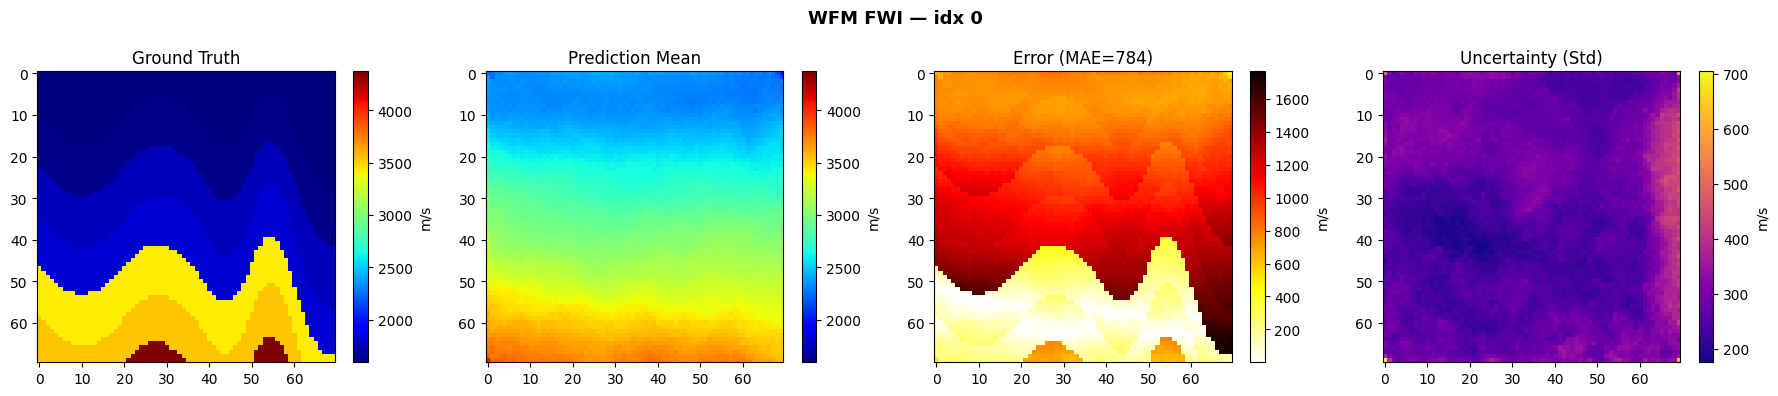

idx 10 | MAE 416.1 m/s | RMSE 448.7 m/s
Saved → wfm_pred_10.png


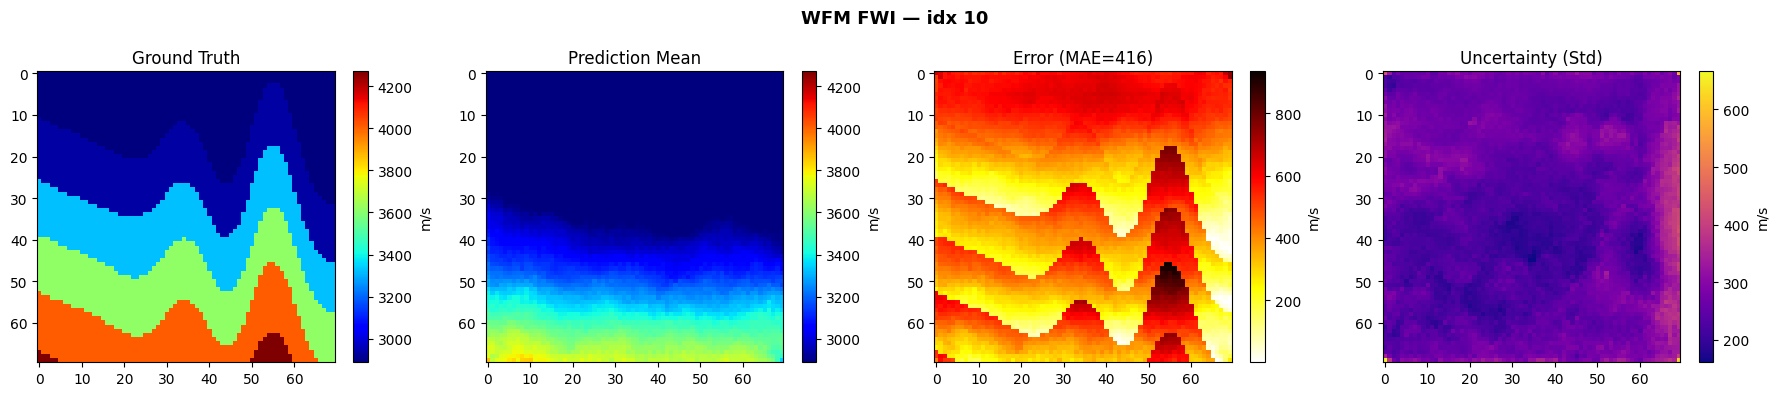

idx 50 | MAE 577.3 m/s | RMSE 633.8 m/s
Saved → wfm_pred_50.png


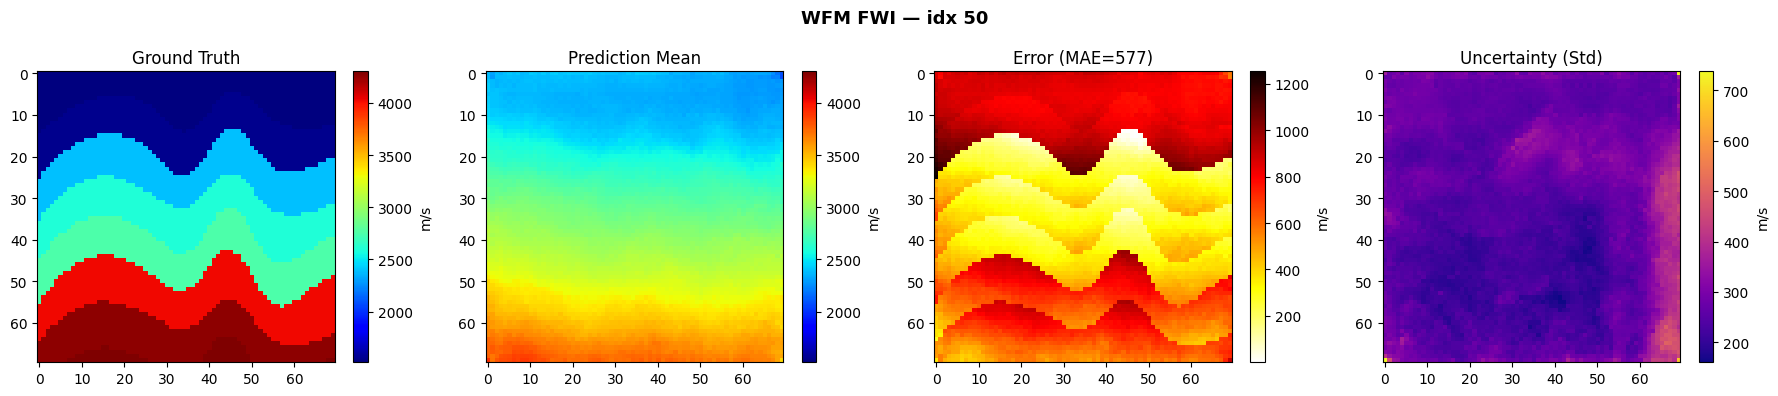

idx 100 | MAE 209.5 m/s | RMSE 253.9 m/s
Saved → wfm_pred_100.png


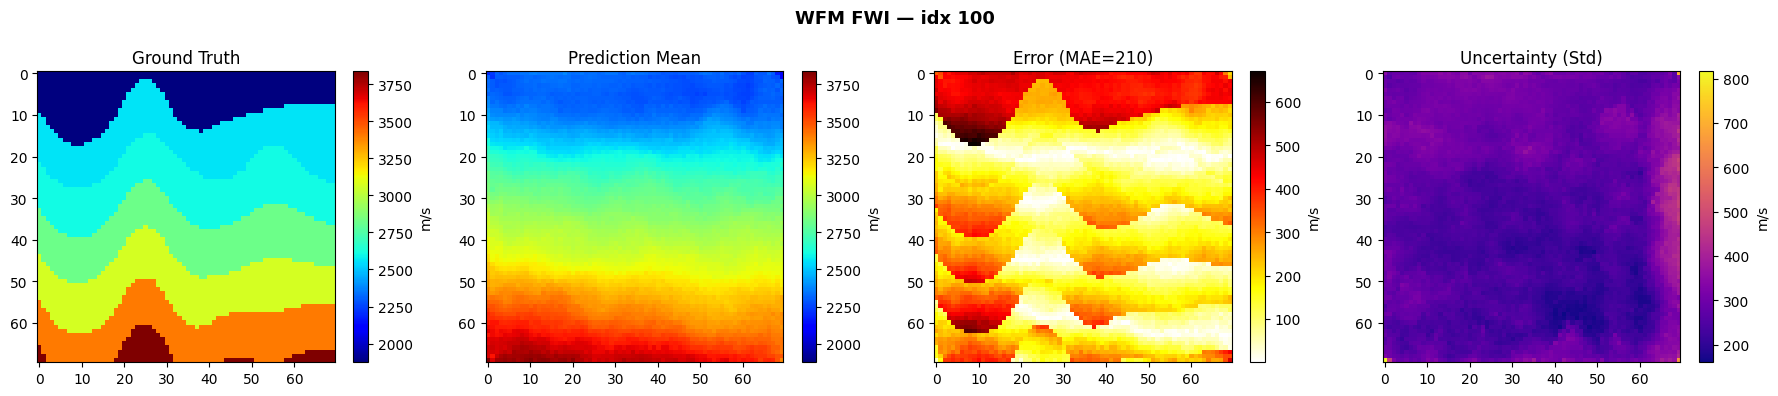

In [ ]:

# ── Example inference call ────────────────────────────────────────────
model = FlowUNet().to(device)
model.load_state_dict(torch.load("best_wfm_fwi.pt", map_location=device))
model.eval()

for idx in [0, 10, 50, 100]:
    visualize_prediction(model, val_dataset, idx,
                         v_min=v_min, v_max=v_max,
                         save_path=f"wfm_pred_{idx}.png")

# Joint  CFM on different dataset

Device: cuda
Loading OpenFWI families …
  CurveVelA       N= 30000  seis=(30000, 5, 1000, 70)  vel=(30000, 1, 70, 70)
  FlatVelA        N= 30000  seis=(30000, 5, 1000, 70)  vel=(30000, 1, 70, 70)
  CurveVelB       N= 30000  seis=(30000, 5, 1000, 70)  vel=(30000, 1, 70, 70)

Velocity statistics:
  CurveVelA       min=1500.0  max=4500.0
  FlatVelA        min=1500.0  max=4500.0
  CurveVelB       min=1500.0  max=4500.0
  GLOBAL          min=1500.0  max=4500.0

Splitting …
  CurveVelA       train= 24000  val= 6000
  FlatVelA        train= 24000  val= 6000
  CurveVelB       train= 24000  val= 6000

  Total  train=  72000  val= 18000
Parameters: 3,979,489


Epoch    0 | Loss 0.1787 | RMSE 648.6 m/s | Best inf m/s
  ✓ Saved  (RMSE=648.6 m/s)


/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
                         

Epoch    5 | Loss 0.0484 | RMSE 536.4 m/s | Best 648.6 m/s
  ✓ Saved  (RMSE=536.4 m/s)


Epoch   10 | Loss 0.0311 | RMSE 481.5 m/s | Best 536.4 m/s
  ✓ Saved  (RMSE=481.5 m/s)


...

Epoch  475 | Loss 0.0057 | RMSE 138.5 m/s | Best 138.5 m/s
  ✓ Saved  (RMSE=138.5 m/s)


Epoch  480 | Loss 0.0056 | RMSE 138.8 m/s | Best 138.5 m/s


Epoch  485 | Loss 0.0058 | RMSE 138.5 m/s | Best 138.5 m/s
  ✓ Saved  (RMSE=138.5 m/s)


Epoch  490 | Loss 0.0057 | RMSE 138.2 m/s | Best 138.5 m/s
  ✓ Saved  (RMSE=138.2 m/s)


Epoch  495 | Loss 0.0056 | RMSE 138.6 m/s | Best 138.2 m/s


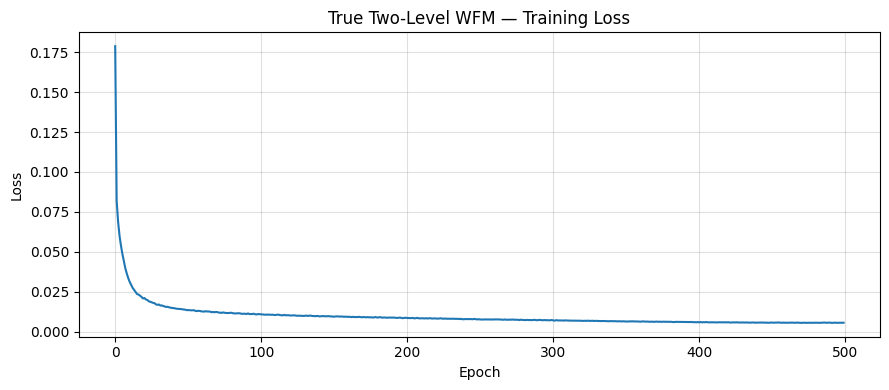

/tmp/ipykernel_142705/119158769.py:660: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("best_cfm_multifamily.pt", map_location=device)


Training complete.
Loaded epoch 490  val RMSE 138.2 m/s

── Full Validation Evaluation ───────────────────────────



═══════════════════════════════════════════════════════════════════════════
  Metric             Overall       CurveVelA        FlatVelA       CurveVelB
───────────────────────────────────────────────────────────────────────────
  MAE(m/s)     84.175±76.132   70.427±30.408   21.358±13.086  160.739±79.343
  RMSE(m/s)   163.779±146.960  138.817±47.358   27.715±18.064  324.805±130.986
  PSNR(dB)     29.814±10.091   27.167±2.878   42.234±5.191   20.041±3.672
  SSIM          0.873±0.111    0.860±0.048    0.994±0.012    0.763±0.085
═══════════════════════════════════════════════════════════════════════════

── Visualising 6 samples ─────────────
[CurveVelA] idx 0 | MAE 141.2 | RMSE 178.0 | PSNR 24.53 dB | SSIM 0.8879


/tmp/ipykernel_142705/119158769.py:600: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved → wfm_CurveVelA_idx0.png


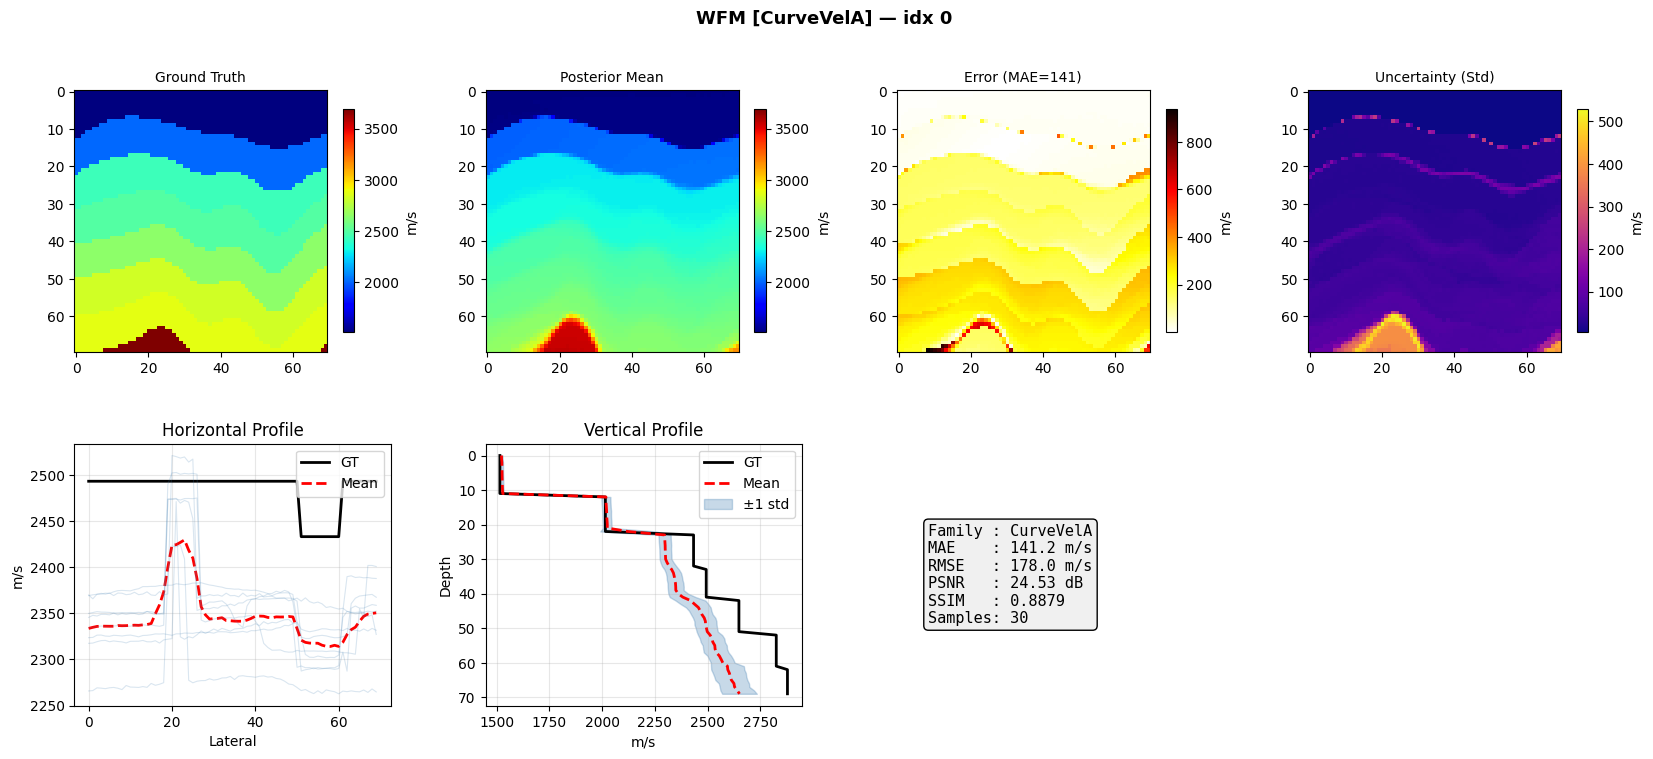

[CurveVelA] idx 1 | MAE 62.0 | RMSE 116.9 | PSNR 28.18 dB | SSIM 0.9466
Saved → wfm_CurveVelA_idx1.png


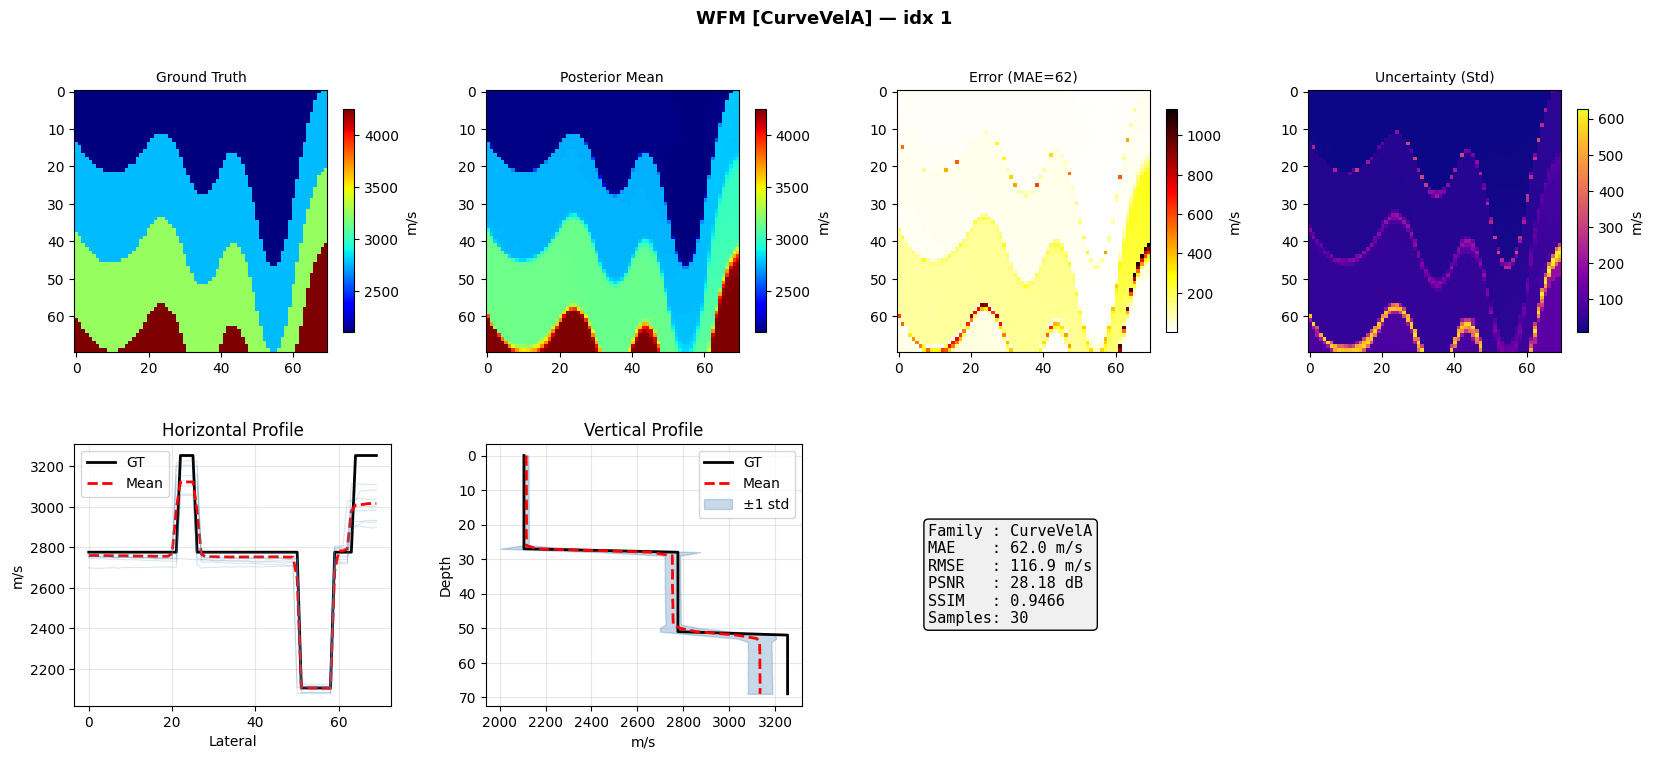

[FlatVelA] idx 6000 | MAE 189.1 | RMSE 276.7 | PSNR 20.70 dB | SSIM 0.8431
Saved → wfm_FlatVelA_idx6000.png


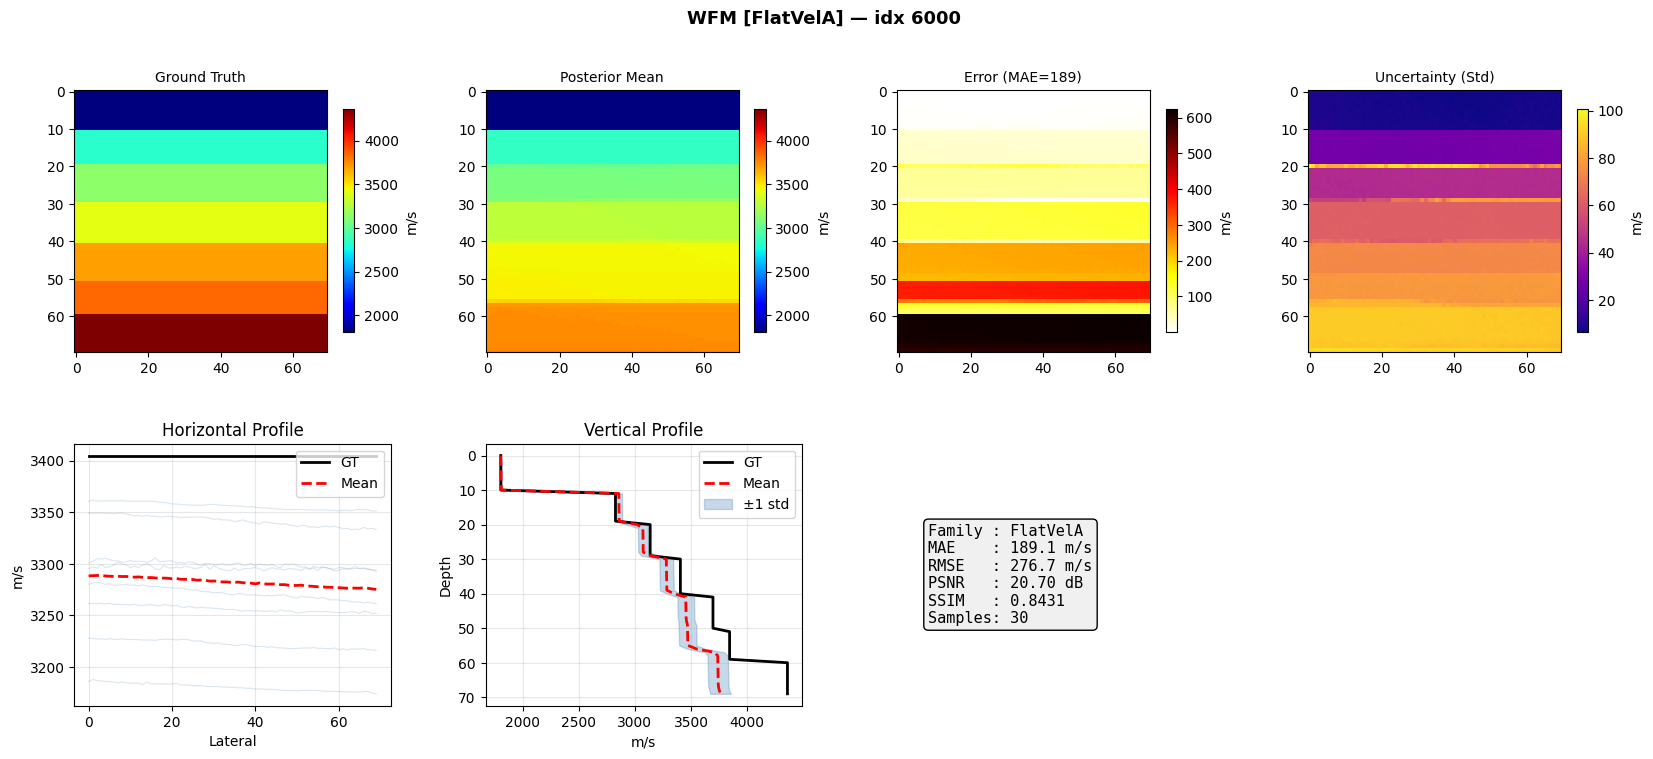

[FlatVelA] idx 6001 | MAE 82.4 | RMSE 175.6 | PSNR 24.65 dB | SSIM 0.9132
Saved → wfm_FlatVelA_idx6001.png


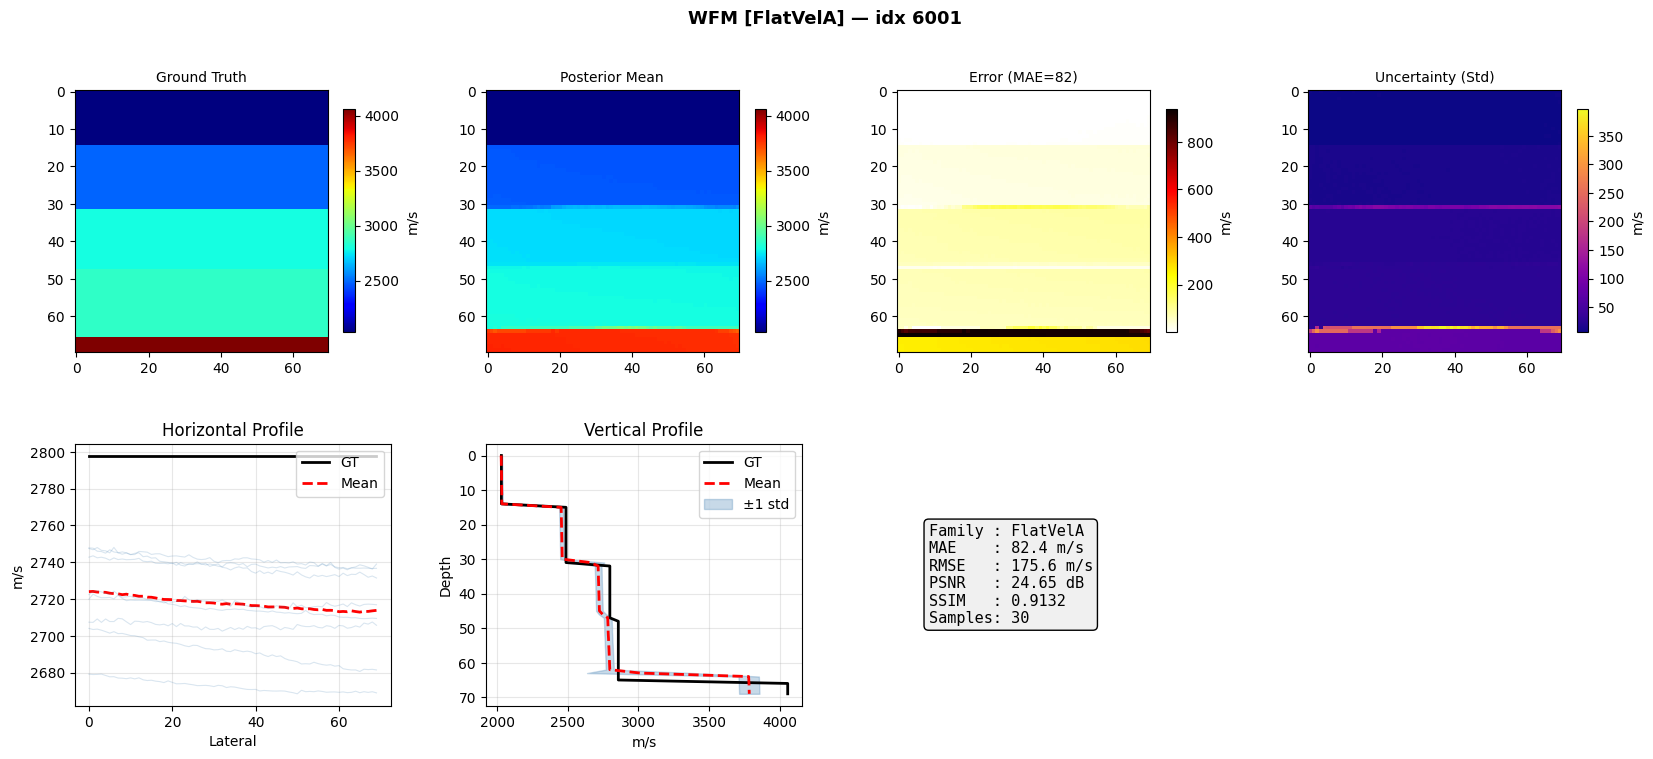

[CurveVelB] idx 12000 | MAE 113.2 | RMSE 251.9 | PSNR 21.52 dB | SSIM 0.8752
Saved → wfm_CurveVelB_idx12000.png


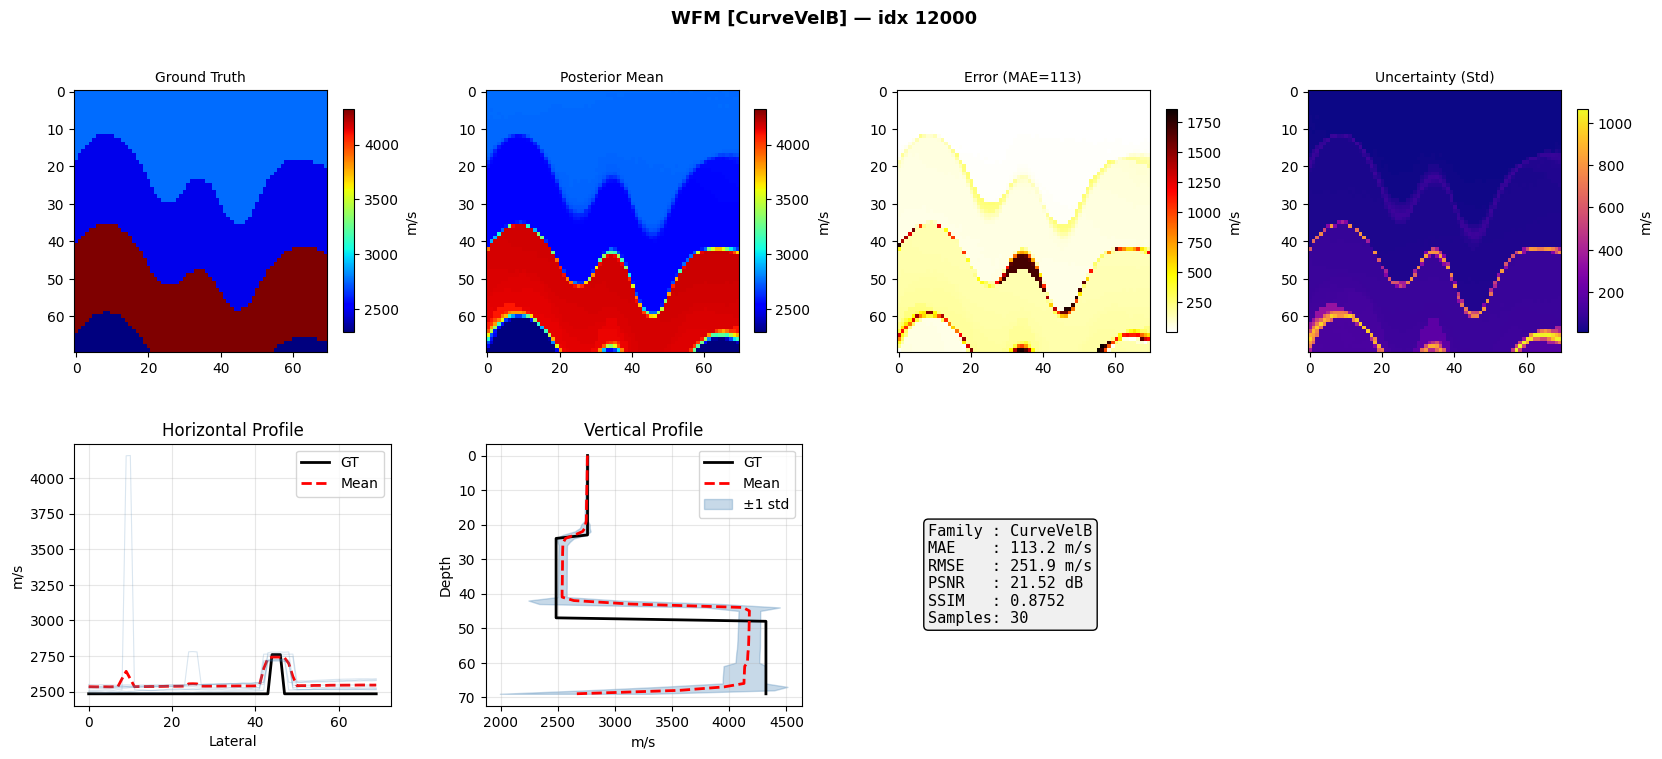

[CurveVelB] idx 12001 | MAE 147.3 | RMSE 274.0 | PSNR 20.79 dB | SSIM 0.8132
Saved → wfm_CurveVelB_idx12001.png


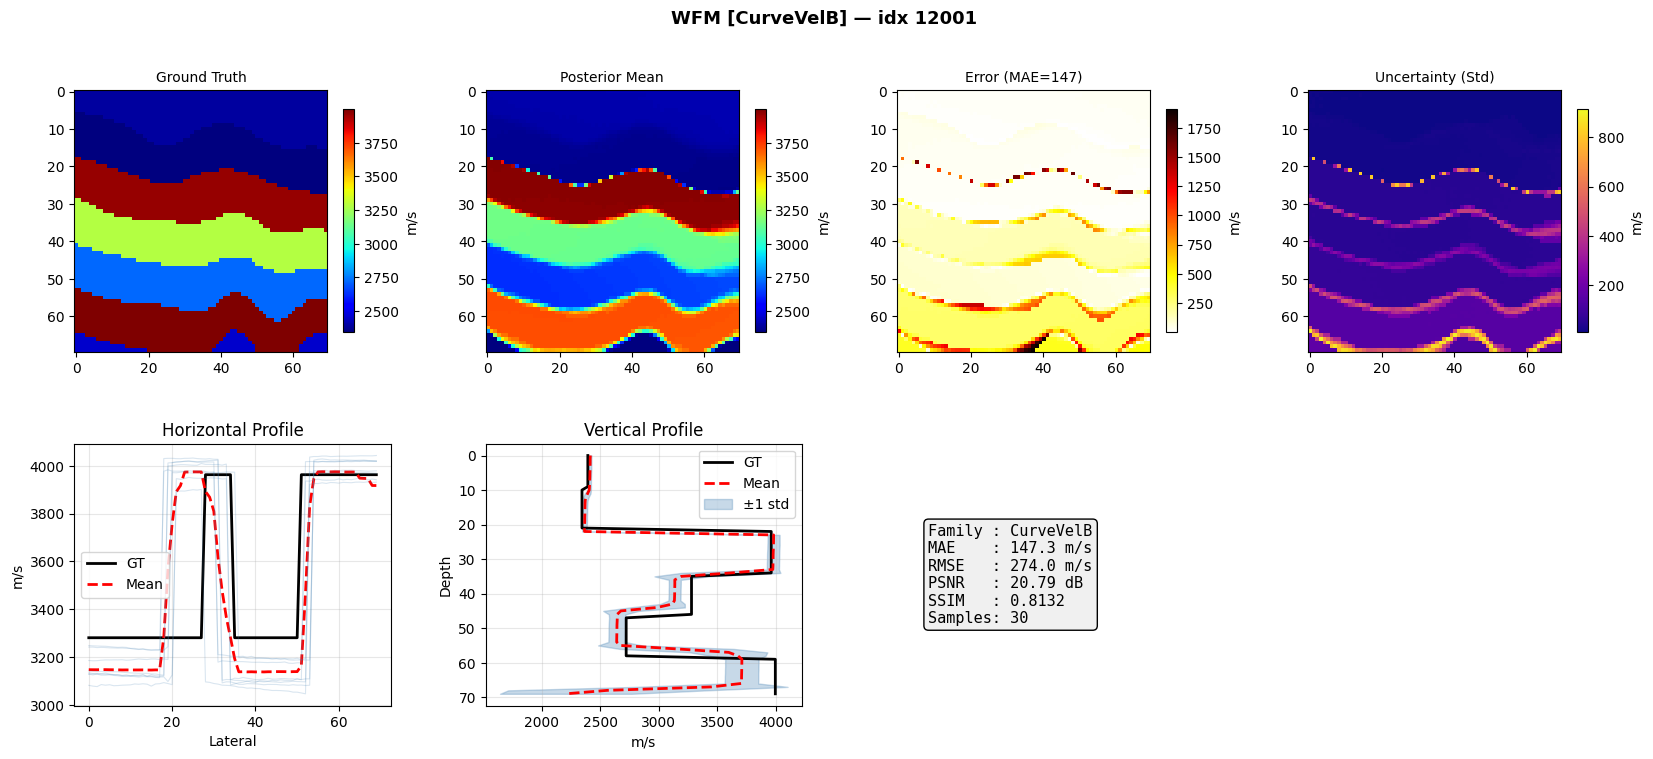

In [ ]:
"""
True Two-Level Wasserstein Flow Matching for FWI
Families : CurveVelA  |  FlatVelA  |  FlatFaultA

Your actual folder structure:
    <base_dir>/
        curve_val_A/
            data/    data*.npy    seismic  (N, 5, 1000, 70)
            model/   model*.npy   velocity (N, 1, 70,   70)
        flat_val_A/
            data/    data*.npy
            model/   model*.npy
        flat_fault_A/
            data/    data*.npy
            model/   model*.npy
"""

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
from skimage.metrics import structural_similarity as skssim

try:
    import ot
except ImportError:
    raise ImportError("pip install POT")


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  DATA LOADING
# ═══════════════════════════════════════════════════════════════════════════════

FAMILY_NAMES  = ["CurveVelA", "FlatVelA", "CurveVelB"]
FAMILY_TO_IDX = {n: i for i, n in enumerate(FAMILY_NAMES)}

# maps family name → (data subfolder, model subfolder)
FAMILY_DIRS = {
    "CurveVelA" : ("CurveVel_A",  "data", "model"),
    "FlatVelA"  : ("FlatVel_A",   "data", "model"),
    "CurveVelB": ("CurveVel_B", "data", "model"),
}


def load_family_arrays(base_dir: str, family_name: str):
    """
    Load all data*.npy / model*.npy for one family.
    Returns X (N,5,1000,70)  Y (N,1,70,70).
    """
    folder, data_sub, model_sub = FAMILY_DIRS[family_name]
    data_dir  = os.path.join(base_dir, folder, data_sub)
    model_dir = os.path.join(base_dir, folder, model_sub)

    data_files  = sorted(glob.glob(os.path.join(data_dir,  "data*.npy")))
    model_files = sorted(glob.glob(os.path.join(model_dir, "model*.npy")))

    assert len(data_files) > 0, \
        f"No data files found in {data_dir}"
    assert len(data_files) == len(model_files), \
        f"File count mismatch in {family_name}: " \
        f"{len(data_files)} data vs {len(model_files)} model"

    X = np.concatenate([np.load(f) for f in data_files],  axis=0)
    Y = np.concatenate([np.load(f) for f in model_files], axis=0)

    # ensure shape (N,1,70,70) for velocity
    if Y.ndim == 3:
        Y = Y[:, np.newaxis]

    return X.astype(np.float32), Y.astype(np.float32)


class SingleFamilyDataset(Dataset):
    """
    Wraps one family's arrays.  Normalisation applied in __getitem__
    so memory usage stays low.
    """
    def __init__(self, X: np.ndarray, Y: np.ndarray,
                 v_min: float, v_max: float):
        self.X, self.Y   = X, Y
        self.v_min, self.v_max = v_min, v_max

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seis = torch.from_numpy(self.X[idx].copy())   # (5,1000,70)
        vel  = torch.from_numpy(self.Y[idx].copy())   # (1,70,70)

        # velocity → [0,1]
        vel = (vel - self.v_min) / (self.v_max - self.v_min + 1e-8)

        # seismic → zero-mean unit-std per sample
        seis = (seis - seis.mean()) / (seis.std() + 1e-8)

        return vel, seis


class MultiOpenFWI(Dataset):
    """
    Combines all families.
    Returns (velocity, seismic, family_label).
    """
    def __init__(self, family_datasets: dict):
        self.samples = []
        for name, ds in family_datasets.items():
            label = FAMILY_TO_IDX[name]
            for i in range(len(ds)):
                self.samples.append((ds, i, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ds, i, label = self.samples[idx]
        vel, seis = ds[i]
        return vel, seis, torch.tensor(label, dtype=torch.long)


def build_dataloaders(base_dir:    str,
                      val_ratio:   float = 0.2,
                      batch_size:  int   = 48,
                      num_workers: int   = 4,
                      seed:        int   = 42):
    """
    Full pipeline: load → global stats → split → DataLoaders.

    Returns
    -------
    train_loader, val_loader, val_dataset (MultiOpenFWI), v_min, v_max
    """
    # ── load all three families ───────────────────────────────────────
    print("=" * 55)
    print("Loading OpenFWI families …")
    family_arrays = {}
    for name in FAMILY_NAMES:
        X, Y = load_family_arrays(base_dir, name)
        family_arrays[name] = (X, Y)
        print(f"  {name:<14}  N={len(X):6d}  "
              f"seis={X.shape}  vel={Y.shape}")

    # ── global velocity statistics ────────────────────────────────────
    print("\nVelocity statistics:")
    v_min, v_max = float('inf'), float('-inf')
    for name, (_, Y) in family_arrays.items():
        v_min = min(v_min, float(Y.min()))
        v_max = max(v_max, float(Y.max()))
        print(f"  {name:<14}  min={Y.min():.1f}  max={Y.max():.1f}")
    print(f"  {'GLOBAL':<14}  min={v_min:.1f}  max={v_max:.1f}")

    # ── train / val split ─────────────────────────────────────────────
    print("\nSplitting …")
    gen = torch.Generator().manual_seed(seed)
    family_train, family_val = {}, {}

    for name, (X, Y) in family_arrays.items():
        ds    = SingleFamilyDataset(X, Y, v_min, v_max)
        n_val = max(1, int(len(ds) * val_ratio))
        n_tr  = len(ds) - n_val
        tr, va = random_split(ds, [n_tr, n_val], generator=gen)
        family_train[name] = tr
        family_val[name]   = va
        print(f"  {name:<14}  train={n_tr:6d}  val={n_val:5d}")

    train_ds = MultiOpenFWI(family_train)
    val_ds   = MultiOpenFWI(family_val)
    print(f"\n  Total  train={len(train_ds):7d}  val={len(val_ds):6d}")
    print("=" * 55)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )

    return train_loader, val_loader, val_ds, v_min, v_max


# ═══════════════════════════════════════════════════════════════════════════════
# 2.  MODEL
# ═══════════════════════════════════════════════════════════════════════════════

class SeismicEncoder(nn.Module):
    def __init__(self, out_channels=32):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Conv2d(5,   16,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(16,  32,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(32,  64,  (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(64,  128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(128, 128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),
        )
        self.proj = nn.Conv2d(128, out_channels, 1)

    def forward(self, y):
        return self.proj(self.net(y))


class FamilyEmbed(nn.Module):
    def __init__(self, n_families=3, embed_dim=32):
        super().__init__()
        self.emb  = nn.Embedding(n_families, embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, lbl):
        return self.proj(self.emb(lbl))


class TimeEmbed(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, 64), nn.SiLU(),
            nn.Linear(64, embed_dim), nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, t):
        return self.mlp(t)


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)
        self.film  = nn.Linear(embed_dim, out_c * 2)

    def forward(self, x, emb):
        sc, sh = self.film(emb).chunk(2, dim=-1)
        h = F.silu(self.norm1(self.conv1(x)))
        h = h * (1 + sc[:,:,None,None]) + sh[:,:,None,None]
        h = F.silu(self.norm2(self.conv2(h)))
        return h


class FlowUNet(nn.Module):
    COND_CH = 32
    FAM_DIM = 32
    EMB_DIM = 128

    def __init__(self, n_families=3):
        super().__init__()
        self.seis_enc  = SeismicEncoder(self.COND_CH)
        self.fam_embed = FamilyEmbed(n_families, self.FAM_DIM)
        self.t_embed   = TimeEmbed(self.EMB_DIM)
        self.fam_proj  = nn.Linear(self.FAM_DIM, self.EMB_DIM)

        ic = 1 + self.COND_CH
        self.c1 = ConvBlock(ic,    64,  self.EMB_DIM)
        self.c2 = ConvBlock(64,   128,  self.EMB_DIM)
        self.c3 = ConvBlock(128,  256,  self.EMB_DIM)
        self.pool = nn.MaxPool2d(2)
        self.mid  = ConvBlock(256, 256, self.EMB_DIM)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1  = ConvBlock(128+256, 128, self.EMB_DIM)
        self.up2 = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.d2  = ConvBlock( 64+128,  64, self.EMB_DIM)
        self.up3 = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.d3  = ConvBlock( 32+ 64,  32, self.EMB_DIM)

        self.out = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, x, t, y, lbl):
        emb  = self.t_embed(t) + self.fam_proj(self.fam_embed(lbl))
        cond = self.seis_enc(y)
        inp  = torch.cat([x, cond], 1)

        x1 = self.c1(inp,           emb)
        x2 = self.c2(self.pool(x1), emb)
        x3 = self.c3(self.pool(x2), emb)
        h  = self.mid(self.pool(x3), emb)

        h = self._match(self.up1(h), x3)
        h = self.d1(torch.cat([h, x3], 1), emb)
        h = self._match(self.up2(h), x2)
        h = self.d2(torch.cat([h, x2], 1), emb)
        h = self._match(self.up3(h), x1)
        h = self.d3(torch.cat([h, x1], 1), emb)

        return self.out(h)


# ═══════════════════════════════════════════════════════════════════════════════
# 3.  LOSS — True Two-Level WFM
# ═══════════════════════════════════════════════════════════════════════════════

def image_gradients(z):
    return z[:,:,1:,:]-z[:,:,:-1,:], z[:,:,:,1:]-z[:,:,:,:-1]


def wfm_loss_two_level(model, x1, y, family_labels, grad_weight=0.1):
    B          = x1.size(0)
    x0         = torch.randn_like(x1)
    n_families = int(family_labels.max().item()) + 1
    D          = x1.view(B, -1).size(1)

    # ── Level 1 : distribution pairing ───────────────────────────────
    fam_vel, fam_noi = [], []
    for f in range(n_families):
        mask = (family_labels == f)
        fam_vel.append(x1[mask].view(-1,D).mean(0) if mask.sum()>0
                       else torch.zeros(D, device=x1.device))
        fam_noi.append(x0[mask].view(-1,D).mean(0) if mask.sum()>0
                       else torch.zeros(D, device=x1.device))

    vel_np = torch.stack(fam_vel).detach().cpu().double().numpy()
    noi_np = torch.stack(fam_noi).detach().cpu().double().numpy()
    vel_np = vel_np / (vel_np.std() + 1e-8)
    noi_np = noi_np / (noi_np.std() + 1e-8)

    c1 = ot.dist(noi_np, vel_np, metric='sqeuclidean')
    c1 = c1 / (c1.max() + 1e-8)
    g1 = ot.emd(np.ones(n_families)/n_families,
                np.ones(n_families)/n_families, c1)
    L1_map = g1.argmax(axis=1)

    # ── remap with guard against empty target family ──────────────────
    remap = torch.arange(B, device=x1.device)   # ✅ default: identity (no remap)

    for f in range(n_families):
        si = (family_labels == f).nonzero(as_tuple=True)[0]
        tf = int(L1_map[f])
        ti = (family_labels == tf).nonzero(as_tuple=True)[0]

        if len(si) == 0:
            continue                              # ✅ no source samples → skip
        if len(ti) == 0:
            # ✅ target family absent in batch → fall back to identity
            remap[si] = si
            continue
        if len(ti) < len(si):
            # ✅ sample with replacement only when ti is non-empty
            ti = ti[torch.randint(len(ti), (len(si),), device=x1.device)]

        remap[si] = ti[:len(si)]

    x1_L1  = x1[remap]
    y_L1   = y[remap]
    lbl_L1 = family_labels[remap]

    # ── Level 2 : sample pairing ──────────────────────────────────────
    x0_np = x0.view(B,-1).detach().cpu().double().numpy()
    x1_np = x1_L1.view(B,-1).detach().cpu().double().numpy()
    c2 = ot.dist(x0_np, x1_np, metric='sqeuclidean')
    c2 = c2 / (c2.max() + 1e-8)
    g2 = ot.emd(np.ones(B)/B, np.ones(B)/B, c2)

    g2t = torch.tensor(g2, dtype=torch.float32, device=x1.device)
    g2t = g2t / (g2t.sum(1, keepdim=True) + 1e-8)
    L2  = torch.multinomial(g2t, 1).squeeze(1)

    x1_m  = x1_L1[L2]
    y_m   = y_L1[L2]
    lbl_m = lbl_L1[L2]

    # ── flow matching ─────────────────────────────────────────────────
    t      = torch.rand(B, 1, device=x1.device)
    xt     = (1-t.view(B,1,1,1))*x0 + t.view(B,1,1,1)*x1_m
    target = x1_m - x0
    pred   = model(xt, t, y_m, lbl_m)

    mse   = ((pred-target)**2).mean()
    ph,pw = image_gradients(pred)
    th,tw = image_gradients(target)
    return mse + grad_weight*(((ph-th)**2).mean() + ((pw-tw)**2).mean())

# ═══════════════════════════════════════════════════════════════════════════════
# 4.  SAMPLING
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def sample_velocity(model, y, lbl, steps=100):
    model.eval()
    B  = y.size(0)
    x  = torch.randn(B, 1, 70, 70, device=y.device)
    dt = 1.0 / steps
    if isinstance(lbl, int):
        lbl = torch.full((B,), lbl, dtype=torch.long, device=y.device)
    for i in range(steps):
        t = torch.full((B,1), i/steps, device=y.device)
        x = x + model(x, t, y, lbl) * dt
    return x


@torch.no_grad()
def sample_posterior(model, y, lbl, n_samples=30, steps=100, sigma=0.02):
    model.eval()
    samples = [sample_velocity(model, y+sigma*torch.randn_like(y),
                               lbl, steps).cpu()
               for _ in range(n_samples)]
    samples = torch.cat(samples, 0)
    return samples.mean(0), samples.std(0), samples


# ═══════════════════════════════════════════════════════════════════════════════
# 5.  EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════

def denormalize(x, v_min, v_max):
    return x * (v_max - v_min) + v_min


def compute_metrics(pred, gt, v_min, v_max):
    dr  = float(v_max - v_min)
    mse = np.mean((pred-gt)**2)
    return dict(
        MAE  = float(np.mean(np.abs(pred-gt))),
        RMSE = float(np.sqrt(mse)),
        PSNR = float(10*np.log10(dr**2/(mse+1e-8))),
        SSIM = float(skssim(gt, pred, data_range=dr)),
        REL  = float(np.mean(np.abs(pred-gt))/(gt.max()-gt.min()+1e-8)*100),
    )


def evaluate(model, val_loader, v_min, v_max, steps=100, max_batches=None):
    model.eval()
    fres = {n: dict(MAE=[],RMSE=[],PSNR=[],SSIM=[],REL=[])
            for n in FAMILY_NAMES}
    ores = dict(MAE=[],RMSE=[],PSNR=[],SSIM=[],REL=[])

    with torch.no_grad():
        for bi,(xt,y,lbl) in enumerate(
                tqdm(val_loader, desc="Eval", leave=False)):
            if max_batches and bi >= max_batches: break
            xt=xt.to(device); y=y.to(device); lbl=lbl.to(device)
            pred    = sample_velocity(model, y, lbl, steps)
            pred_np = denormalize(pred.cpu().numpy(), v_min, v_max)
            gt_np   = denormalize(xt.cpu().numpy(),   v_min, v_max)
            for b in range(gt_np.shape[0]):
                m  = compute_metrics(pred_np[b,0], gt_np[b,0], v_min, v_max)
                fn = FAMILY_NAMES[lbl[b].item()]
                for k in m:
                    fres[fn][k].append(m[k]); ores[k].append(m[k])

    agg = lambda d: {k:(np.mean(v),np.std(v)) for k,v in d.items()}
    return agg(ores), {n:agg(v) for n,v in fres.items()}


def print_eval(overall, per_family):
    metrics = ["MAE","RMSE","PSNR","SSIM"]
    units   = {"MAE":"m/s","RMSE":"m/s","PSNR":"dB","SSIM":""}
    print("\n"+"═"*75)
    header = f"  {'Metric':<12}{'Overall':>14}"
    for n in FAMILY_NAMES: header += f"{n:>16}"
    print(header); print("─"*75)
    for m in metrics:
        u = units[m]; row = f"  {(m+'('+u+')' if u else m):<12}"
        mn,sd = overall[m]; row += f"{mn:>7.3f}±{sd:<5.3f}"
        for n in FAMILY_NAMES:
            mn,sd = per_family[n][m]; row += f"{mn:>9.3f}±{sd:<5.3f}"
        print(row)
    print("═"*75)


# ═══════════════════════════════════════════════════════════════════════════════
# 6.  TRAINING
# ═══════════════════════════════════════════════════════════════════════════════

def train(model, train_loader, val_loader, v_min, v_max,
          epochs=500, save_path="best_wfm_multifamily.pt"):

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.05)

    best_rmse = float('inf')
    history   = []

    for epoch in range(epochs):
        model.train(); total = 0.0
        for x1, y, lbl in train_loader:
            x1=x1.to(device); y=y.to(device); lbl=lbl.to(device)
            loss = wfm_loss_two_level(model, x1, y, lbl, grad_weight=0.1)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step()
            total += loss.item()

        train_loss = total / len(train_loader)
        history.append(train_loss)

        if epoch % 5 == 0:
            overall, pf = evaluate(model, val_loader, v_min, v_max,
                                   steps=50, max_batches=30)
            val_rmse = overall["RMSE"][0]
            print(f"Epoch {epoch:4d} | Loss {train_loss:.4f} | "
                  f"RMSE {val_rmse:.1f} m/s | Best {best_rmse:.1f} m/s")

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                torch.save({'epoch':epoch,'model':model.state_dict(),
                            'v_min':v_min,'v_max':v_max,
                            'val_rmse':val_rmse}, save_path)
                print(f"  ✓ Saved  (RMSE={best_rmse:.1f} m/s)")

    plt.figure(figsize=(9,4))
    plt.plot(history); plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("True Two-Level WFM — Training Loss")
    plt.grid(True,alpha=0.4); plt.tight_layout()
    plt.savefig("wfm_training_curve.png",dpi=150); plt.show()
    print("Training complete.")
    return history


# ═══════════════════════════════════════════════════════════════════════════════
# 7.  VISUALISATION
# ═══════════════════════════════════════════════════════════════════════════════

def visualize_sample(model, dataset, idx, v_min, v_max,
                     n_samples=30, steps=100, save_path=None):
    dev = next(model.parameters()).device
    vel, seis, lbl = dataset[idx]
    fname = FAMILY_NAMES[lbl.item()]

    mean_m, std_m, all_s = sample_posterior(
        model, seis.unsqueeze(0).to(dev),
        lbl.unsqueeze(0).to(dev),
        n_samples=n_samples, steps=steps)

    gt   = denormalize(vel[0].numpy(),    v_min, v_max)
    pred = denormalize(mean_m[0].numpy(), v_min, v_max)
    std  = std_m[0].numpy() * (v_max - v_min)
    err  = np.abs(gt - pred)
    m    = compute_metrics(pred, gt, v_min, v_max)

    print(f"[{fname}] idx {idx} | MAE {m['MAE']:.1f} | "
          f"RMSE {m['RMSE']:.1f} | PSNR {m['PSNR']:.2f} dB | "
          f"SSIM {m['SSIM']:.4f}")

    vn,vx = gt.min(), gt.max()
    fig = plt.figure(figsize=(20,8))
    fig.suptitle(f"WFM [{fname}] — idx {idx}",
                 fontsize=13, fontweight='bold')
    gs   = gridspec.GridSpec(2,4,figure=fig,hspace=0.35,wspace=0.3)
    axes = [fig.add_subplot(gs[r,c]) for r in range(2) for c in range(4)]

    def _show(ax, data, title, cmap, vmin=None, vmax=None):
        im = ax.imshow(data,cmap=cmap,vmin=vmin,vmax=vmax,aspect='auto')
        ax.set_title(title,fontsize=10)
        plt.colorbar(im,ax=ax,label="m/s",shrink=0.85)

    _show(axes[0], gt,   "Ground Truth",               "jet",   vn, vx)
    _show(axes[1], pred, "Posterior Mean",              "jet",   vn, vx)
    _show(axes[2], err,  f"Error (MAE={m['MAE']:.0f})", "hot_r")
    _show(axes[3], std,  "Uncertainty (Std)",           "plasma")

    mid = gt.shape[0]//2
    axes[4].plot(gt[mid],   'k-',  lw=2, label='GT')
    axes[4].plot(pred[mid], 'r--', lw=2, label='Mean')
    for s in all_s[:8]:
        sv = denormalize(s[0].numpy(), v_min, v_max)
        axes[4].plot(sv[mid], alpha=0.2, color='steelblue', lw=0.8)
    axes[4].set_title("Horizontal Profile")
    axes[4].set_xlabel("Lateral"); axes[4].set_ylabel("m/s")
    axes[4].legend(); axes[4].grid(True,alpha=0.3)

    mc = gt.shape[1]//2; depth=np.arange(gt.shape[0])
    axes[5].plot(gt[:,mc],   depth,'k-', lw=2, label='GT')
    axes[5].plot(pred[:,mc], depth,'r--',lw=2, label='Mean')
    axes[5].fill_betweenx(depth,
        pred[:,mc]-std[:,mc], pred[:,mc]+std[:,mc],
        alpha=0.3,color='steelblue',label='±1 std')
    axes[5].invert_yaxis()
    axes[5].set_title("Vertical Profile")
    axes[5].set_xlabel("m/s"); axes[5].set_ylabel("Depth")
    axes[5].legend(); axes[5].grid(True,alpha=0.3)

    axes[6].axis('off')
    axes[6].text(0.1,0.5,
        f"Family : {fname}\nMAE    : {m['MAE']:.1f} m/s\n"
        f"RMSE   : {m['RMSE']:.1f} m/s\nPSNR   : {m['PSNR']:.2f} dB\n"
        f"SSIM   : {m['SSIM']:.4f}\nSamples: {n_samples}",
        transform=axes[6].transAxes, fontsize=11, va='center',
        family='monospace',
        bbox=dict(boxstyle='round',facecolor='#f0f0f0'))
    axes[7].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path,dpi=150,bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()


def run_inference(model, val_loader, val_dataset, v_min, v_max):
    print("\n── Full Validation Evaluation ───────────────────────────")
    overall, per_family = evaluate(model,val_loader,v_min,v_max,steps=100)
    print_eval(overall, per_family)

    # 2 samples per family
    indices = []
    for fid in range(len(FAMILY_NAMES)):
        count = 0
        for i in range(len(val_dataset)):
            _,_,lbl = val_dataset[i]
            if lbl.item()==fid and count<2:
                indices.append(i); count+=1

    print(f"\n── Visualising {len(indices)} samples ─────────────")
    for idx in indices:
        _,_,lbl = val_dataset[idx]
        fname   = FAMILY_NAMES[lbl.item()]
        visualize_sample(model, val_dataset, idx,
                         v_min=v_min, v_max=v_max,
                         n_samples=30, steps=100,
                         save_path=f"wfm_{fname}_idx{idx}.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.  MAIN
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # ── change this to your base directory ───────────────────────────
    BASE_DIR = "/DATA/Flow_Matching"

    # ── 1. data ───────────────────────────────────────────────────────
    train_loader, val_loader, val_dataset, v_min, v_max = build_dataloaders(
        base_dir    = BASE_DIR,
        val_ratio   = 0.2,
        batch_size  = 48,
        num_workers = 4,
    )

    # ── 2. model ──────────────────────────────────────────────────────
    model = FlowUNet(n_families=3).to(device)
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # ── 3. train ──────────────────────────────────────────────────────
    train(model, train_loader, val_loader, v_min, v_max,
          epochs=500, save_path="best_cfm_multifamily.pt")

    # ── 4. load best & run inference ──────────────────────────────────
    ckpt = torch.load("best_cfm_multifamily.pt", map_location=device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    print(f"Loaded epoch {ckpt['epoch']}  "
          f"val RMSE {ckpt['val_rmse']:.1f} m/s")

    run_inference(model, val_loader, val_dataset, v_min, v_max)

# Joint  WFM with OT on both label with different datasets

Device: cuda
Loading OpenFWI families …
  CurveVelA       N= 30000  seis=(30000, 5, 1000, 70)  vel=(30000, 1, 70, 70)
  FlatVelA        N= 30000  seis=(30000, 5, 1000, 70)  vel=(30000, 1, 70, 70)
  CurveVelB       N= 30000  seis=(30000, 5, 1000, 70)  vel=(30000, 1, 70, 70)

Velocity statistics:
  CurveVelA       min=1500.0  max=4500.0
  FlatVelA        min=1500.0  max=4500.0
  CurveVelB       min=1500.0  max=4500.0
  GLOBAL          min=1500.0  max=4500.0

Splitting …
  CurveVelA       train= 24000  val= 6000
  FlatVelA        train= 24000  val= 6000
  CurveVelB       train= 24000  val= 6000

  Total  train=  72000  val= 18000
Parameters: 3,979,489


Epoch    0 | Loss 0.1962 | Val RMSE 629.7 m/s | Best inf m/s
  ✓ Saved  (RMSE=629.7 m/s)


/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/iit/Desktop/Mask_Flow_Matching/lib/python3.12/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
                         

Epoch    5 | Loss 0.0486 | Val RMSE 528.3 m/s | Best 629.7 m/s
  ✓ Saved  (RMSE=528.3 m/s)


Epoch   10 | Loss 0.0314 | Val RMSE 408.7 m/s | Best 528.3 m/s
  ✓ Saved  (RMSE=408.7 m/s)


...

Epoch  475 | Loss 0.0057 | Val RMSE 136.5 m/s | Best 135.6 m/s


Epoch  480 | Loss 0.0056 | Val RMSE 136.4 m/s | Best 135.6 m/s


Epoch  485 | Loss 0.0057 | Val RMSE 135.8 m/s | Best 135.6 m/s


Epoch  490 | Loss 0.0056 | Val RMSE 136.8 m/s | Best 135.6 m/s


Epoch  495 | Loss 0.0057 | Val RMSE 136.4 m/s | Best 135.6 m/s


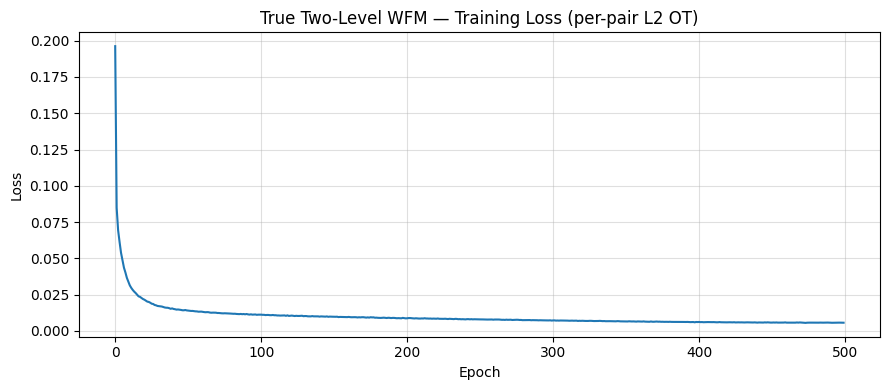

Training complete.


/tmp/ipykernel_44921/4023805016.py:736: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("best_wfm_multifamily.pt", map_location=device)


FileNotFoundError: [Errno 2] No such file or directory: 'best_wfm_multifamily.pt'

In [ ]:
"""
True Two-Level Wasserstein Flow Matching for FWI
Families : CurveVelA  |  FlatVelA  |  FlatFaultA

Folder structure:
    <base_dir>/
        curve_val_A/
            data/    data*.npy    seismic  (N, 5, 1000, 70)
            model/   model*.npy   velocity (N, 1, 70,   70)
        flat_val_A/
            data/    data*.npy
            model/   model*.npy
        flat_fault_A/
            data/    data*.npy
            model/   model*.npy
"""

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
from skimage.metrics import structural_similarity as skssim

try:
    import ot
except ImportError:
    raise ImportError("pip install POT")


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  DATA LOADING
# ═══════════════════════════════════════════════════════════════════════════════

FAMILY_NAMES  = ["CurveVelA", "FlatVelA", "CurveVelB"]
FAMILY_TO_IDX = {n: i for i, n in enumerate(FAMILY_NAMES)}

FAMILY_DIRS = {
    "CurveVelA" : ("CurveVel_A",  "data", "model"),
    "FlatVelA"  : ("FlatVel_A",   "data", "model"),
    "CurveVelB": ("CurveVel_B", "data", "model"),
}


def load_family_arrays(base_dir: str, family_name: str):
    folder, data_sub, model_sub = FAMILY_DIRS[family_name]
    data_dir  = os.path.join(base_dir, folder, data_sub)
    model_dir = os.path.join(base_dir, folder, model_sub)

    data_files  = sorted(glob.glob(os.path.join(data_dir,  "data*.npy")))
    model_files = sorted(glob.glob(os.path.join(model_dir, "model*.npy")))

    assert len(data_files) > 0, f"No data files found in {data_dir}"
    assert len(data_files) == len(model_files), \
        f"Mismatch in {family_name}: {len(data_files)} data vs {len(model_files)} model"

    X = np.concatenate([np.load(f) for f in data_files],  axis=0)
    Y = np.concatenate([np.load(f) for f in model_files], axis=0)
    if Y.ndim == 3:
        Y = Y[:, np.newaxis]
    return X.astype(np.float32), Y.astype(np.float32)


class SingleFamilyDataset(Dataset):
    def __init__(self, X, Y, v_min, v_max):
        self.X, self.Y       = X, Y
        self.v_min, self.v_max = v_min, v_max

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seis = torch.from_numpy(self.X[idx].copy())
        vel  = torch.from_numpy(self.Y[idx].copy())
        vel  = (vel - self.v_min) / (self.v_max - self.v_min + 1e-8)
        seis = (seis - seis.mean()) / (seis.std() + 1e-8)
        return vel, seis


class MultiOpenFWI(Dataset):
    """Returns (velocity, seismic, family_label)."""
    def __init__(self, family_datasets: dict):
        self.samples = []
        for name, ds in family_datasets.items():
            label = FAMILY_TO_IDX[name]
            for i in range(len(ds)):
                self.samples.append((ds, i, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ds, i, label = self.samples[idx]
        vel, seis = ds[i]
        return vel, seis, torch.tensor(label, dtype=torch.long)


def build_dataloaders(base_dir, val_ratio=0.2, batch_size=48,
                      num_workers=4, seed=42):
    print("=" * 55)
    print("Loading OpenFWI families …")
    family_arrays = {}
    for name in FAMILY_NAMES:
        X, Y = load_family_arrays(base_dir, name)
        family_arrays[name] = (X, Y)
        print(f"  {name:<14}  N={len(X):6d}  seis={X.shape}  vel={Y.shape}")

    print("\nVelocity statistics:")
    v_min, v_max = float('inf'), float('-inf')
    for name, (_, Y) in family_arrays.items():
        v_min = min(v_min, float(Y.min()))
        v_max = max(v_max, float(Y.max()))
        print(f"  {name:<14}  min={Y.min():.1f}  max={Y.max():.1f}")
    print(f"  {'GLOBAL':<14}  min={v_min:.1f}  max={v_max:.1f}")

    print("\nSplitting …")
    gen = torch.Generator().manual_seed(seed)
    family_train, family_val = {}, {}
    for name, (X, Y) in family_arrays.items():
        ds    = SingleFamilyDataset(X, Y, v_min, v_max)
        n_val = max(1, int(len(ds) * val_ratio))
        n_tr  = len(ds) - n_val
        tr, va = random_split(ds, [n_tr, n_val], generator=gen)
        family_train[name] = tr
        family_val[name]   = va
        print(f"  {name:<14}  train={n_tr:6d}  val={n_val:5d}")

    train_ds = MultiOpenFWI(family_train)
    val_ds   = MultiOpenFWI(family_val)
    print(f"\n  Total  train={len(train_ds):7d}  val={len(val_ds):6d}")
    print("=" * 55)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True,
                              drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, val_ds, v_min, v_max


# ═══════════════════════════════════════════════════════════════════════════════
# 2.  MODEL
# ═══════════════════════════════════════════════════════════════════════════════

class SeismicEncoder(nn.Module):
    def __init__(self, out_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(5,   16,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(16,  32,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(32,  64,  (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(64,  128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(128, 128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),
        )
        self.proj = nn.Conv2d(128, out_channels, 1)

    def forward(self, y):
        return self.proj(self.net(y))


class FamilyEmbed(nn.Module):
    def __init__(self, n_families=3, embed_dim=32):
        super().__init__()
        self.emb  = nn.Embedding(n_families, embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, lbl):
        return self.proj(self.emb(lbl))


class TimeEmbed(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, 64), nn.SiLU(),
            nn.Linear(64, embed_dim), nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, t):
        return self.mlp(t)


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)
        self.film  = nn.Linear(embed_dim, out_c * 2)

    def forward(self, x, emb):
        sc, sh = self.film(emb).chunk(2, dim=-1)
        h = F.silu(self.norm1(self.conv1(x)))
        h = h * (1 + sc[:,:,None,None]) + sh[:,:,None,None]
        h = F.silu(self.norm2(self.conv2(h)))
        return h


class FlowUNet(nn.Module):
    COND_CH = 32
    FAM_DIM = 32
    EMB_DIM = 128

    def __init__(self, n_families=3):
        super().__init__()
        self.seis_enc  = SeismicEncoder(self.COND_CH)
        self.fam_embed = FamilyEmbed(n_families, self.FAM_DIM)
        self.t_embed   = TimeEmbed(self.EMB_DIM)
        self.fam_proj  = nn.Linear(self.FAM_DIM, self.EMB_DIM)

        ic = 1 + self.COND_CH
        self.c1   = ConvBlock(ic,    64,  self.EMB_DIM)
        self.c2   = ConvBlock(64,   128,  self.EMB_DIM)
        self.c3   = ConvBlock(128,  256,  self.EMB_DIM)
        self.pool = nn.MaxPool2d(2)
        self.mid  = ConvBlock(256,  256,  self.EMB_DIM)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1  = ConvBlock(128+256, 128, self.EMB_DIM)
        self.up2 = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.d2  = ConvBlock( 64+128,  64, self.EMB_DIM)
        self.up3 = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.d3  = ConvBlock( 32+ 64,  32, self.EMB_DIM)
        self.out = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, x, t, y, lbl):
        emb  = self.t_embed(t) + self.fam_proj(self.fam_embed(lbl))
        cond = self.seis_enc(y)
        inp  = torch.cat([x, cond], 1)

        x1 = self.c1(inp,           emb)
        x2 = self.c2(self.pool(x1), emb)
        x3 = self.c3(self.pool(x2), emb)
        h  = self.mid(self.pool(x3), emb)

        h = self._match(self.up1(h), x3)
        h = self.d1(torch.cat([h, x3], 1), emb)
        h = self._match(self.up2(h), x2)
        h = self.d2(torch.cat([h, x2], 1), emb)
        h = self._match(self.up3(h), x1)
        h = self.d3(torch.cat([h, x1], 1), emb)

        return self.out(h)


# ═══════════════════════════════════════════════════════════════════════════════
# 3.  LOSS  —  True Two-Level WFM  (per-pair L2 OT)
# ═══════════════════════════════════════════════════════════════════════════════

def image_gradients(z):
    return z[:,:,1:,:]-z[:,:,:-1,:], z[:,:,:,1:]-z[:,:,:,:-1]


def wfm_loss_two_level(model, x1, y, family_labels, grad_weight=0.1):
    """
    Correct two-level WFM loss.

    Level 1 : OT between family-level distribution embeddings
              → decides which noise family pairs with which velocity family
              → gives 3 pairs  e.g. {0→2, 1→0, 2→1}

    Level 2 : OT run SEPARATELY for each L1 pair
              → within each pair, finds shortest sample-level paths
              → produces 3 sets of matched (x0_i, x1_j) pairs

    Then all 3 sets are concatenated and flow matching loss is computed.
    """
    B          = x1.size(0)
    x0         = torch.randn_like(x1)
    n_families = int(family_labels.max().item()) + 1
    D          = x1.view(B, -1).size(1)

    # ════════════════════════════════════════════════════════════════
    # LEVEL 1 — which noise family pairs with which velocity family?
    # ════════════════════════════════════════════════════════════════

    fam_vel, fam_noi = [], []
    for f in range(n_families):
        mask = (family_labels == f)
        fam_vel.append(x1[mask].view(-1,D).mean(0) if mask.sum()>0
                       else torch.zeros(D, device=x1.device))
        fam_noi.append(x0[mask].view(-1,D).mean(0) if mask.sum()>0
                       else torch.zeros(D, device=x1.device))

    vel_np = torch.stack(fam_vel).detach().cpu().double().numpy()
    noi_np = torch.stack(fam_noi).detach().cpu().double().numpy()
    vel_np = vel_np / (vel_np.std() + 1e-8)
    noi_np = noi_np / (noi_np.std() + 1e-8)

    c1     = ot.dist(noi_np, vel_np, metric='sqeuclidean')
    c1     = c1 / (c1.max() + 1e-8)
    g1     = ot.emd(np.ones(n_families)/n_families,
                    np.ones(n_families)/n_families, c1)
    L1_map = g1.argmax(axis=1)   # L1_map[f] = which velocity family f maps to

    # ════════════════════════════════════════════════════════════════
    # LEVEL 2 — per-pair OT  (3 separate OT solves)
    #
    # For each L1 pair (noise_family_f → vel_family_L1_map[f]):
    #   1. collect noise samples  from family f
    #   2. collect velocity samples from family L1_map[f]
    #   3. solve OT between them  → shortest sample-level paths
    #   4. soft-sample matched pairs from transport plan
    # ════════════════════════════════════════════════════════════════

    all_x0       = []
    all_x1_match = []
    all_y_match  = []
    all_lbl_match = []

    for f in range(n_families):

        # ── noise samples: from family f ─────────────────────────
        src_idx = (family_labels == f).nonzero(as_tuple=True)[0]
        if len(src_idx) == 0:
            continue                          # family absent in batch

        # ── velocity samples: from L1-paired family ──────────────
        tgt_family = int(L1_map[f])
        tgt_idx    = (family_labels == tgt_family).nonzero(as_tuple=True)[0]

        if len(tgt_idx) == 0:
            tgt_idx = src_idx                 # fallback: same family

        x0_pair  = x0[src_idx]               # (n_src, 1, 70, 70)
        x1_pair  = x1[tgt_idx]               # (n_tgt, 1, 70, 70)
        y_pair   = y[tgt_idx]                # (n_tgt, 5, 1000, 70)
        lbl_pair = family_labels[tgt_idx]    # (n_tgt,)

        n_src = len(src_idx)
        n_tgt = len(tgt_idx)

        # ── L2 OT within this pair only ───────────────────────────
        x0_np = x0_pair.view(n_src,-1).detach().cpu().double().numpy()
        x1_np = x1_pair.view(n_tgt,-1).detach().cpu().double().numpy()

        c2 = ot.dist(x0_np, x1_np, metric='sqeuclidean')
        c2 = c2 / (c2.max() + 1e-8)
        g2 = ot.emd(np.ones(n_src)/n_src,
                    np.ones(n_tgt)/n_tgt, c2)   # (n_src, n_tgt)

        # soft sampling from this pair's transport plan
        g2t    = torch.tensor(g2, dtype=torch.float32, device=x1.device)
        g2t    = g2t / (g2t.sum(1, keepdim=True) + 1e-8)
        L2_idx = torch.multinomial(g2t, 1).squeeze(1)  # (n_src,)

        # collect matched pairs for this L1 pair
        all_x0.append(x0_pair)
        all_x1_match.append(x1_pair[L2_idx])
        all_y_match.append(y_pair[L2_idx])
        all_lbl_match.append(lbl_pair[L2_idx])

    # ════════════════════════════════════════════════════════════════
    # CONCATENATE all 3 pairs and compute flow matching loss
    # ════════════════════════════════════════════════════════════════

    x0_cat   = torch.cat(all_x0,        dim=0)   # (B, 1, 70, 70)
    x1_cat   = torch.cat(all_x1_match,  dim=0)   # (B, 1, 70, 70)
    y_cat    = torch.cat(all_y_match,   dim=0)   # (B, 5, 1000, 70)
    lbl_cat  = torch.cat(all_lbl_match, dim=0)   # (B,)

    B_out  = x0_cat.size(0)
    t      = torch.rand(B_out, 1, device=x1.device)

    # straight-line interpolation between OT-matched pairs
    xt     = (1-t.view(B_out,1,1,1))*x0_cat + t.view(B_out,1,1,1)*x1_cat
    target = x1_cat - x0_cat     # direction of shortest path

    pred   = model(xt, t, y_cat, lbl_cat)

    mse    = ((pred - target)**2).mean()
    ph, pw = image_gradients(pred)
    th, tw = image_gradients(target)
    return mse + grad_weight*(((ph-th)**2).mean() + ((pw-tw)**2).mean())


# ═══════════════════════════════════════════════════════════════════════════════
# 4.  SAMPLING
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def sample_velocity(model, y, lbl, steps=100):
    """
    Euler ODE integration  x0 → x1  for one batch.

    y   : (B, 5, 1000, 70)
    lbl : (B,) int tensor  or  single int
    """
    model.eval()
    B  = y.size(0)
    x  = torch.randn(B, 1, 70, 70, device=y.device)
    dt = 1.0 / steps
    if isinstance(lbl, int):
        lbl = torch.full((B,), lbl, dtype=torch.long, device=y.device)
    for i in range(steps):
        t = torch.full((B, 1), i/steps, device=y.device)
        x = x + model(x, t, y, lbl) * dt
    return x   # (B, 1, 70, 70)


@torch.no_grad()
def sample_posterior(model, y, lbl, n_samples=30, steps=100, sigma=0.02):
    """
    Draw n_samples posterior samples by perturbing seismic slightly.
    Returns mean (1,70,70), std (1,70,70), all samples (n,1,70,70).
    """
    model.eval()
    samples = []
    for _ in range(n_samples):
        noisy_y = y + sigma * torch.randn_like(y)
        s = sample_velocity(model, noisy_y, lbl, steps)
        samples.append(s.cpu())
    samples = torch.cat(samples, 0)          # (n_samples, 1, 70, 70)
    return samples.mean(0), samples.std(0), samples


# ═══════════════════════════════════════════════════════════════════════════════
# 5.  EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════

def denormalize(x, v_min, v_max):
    return x * (v_max - v_min) + v_min


def compute_metrics(pred, gt, v_min, v_max):
    dr  = float(v_max - v_min)
    mse = np.mean((pred - gt)**2)
    return dict(
        MAE  = float(np.mean(np.abs(pred - gt))),
        RMSE = float(np.sqrt(mse)),
        PSNR = float(10 * np.log10(dr**2 / (mse + 1e-8))),
        SSIM = float(skssim(gt, pred, data_range=dr)),
        REL  = float(np.mean(np.abs(pred-gt)) / (gt.max()-gt.min()+1e-8) * 100),
    )


def evaluate(model, val_loader, v_min, v_max, steps=100, max_batches=None):
    """
    Full evaluation broken down per family + overall.
    Returns (overall_agg, per_family_agg).
    """
    model.eval()
    fres = {n: dict(MAE=[],RMSE=[],PSNR=[],SSIM=[],REL=[])
            for n in FAMILY_NAMES}
    ores = dict(MAE=[],RMSE=[],PSNR=[],SSIM=[],REL=[])

    with torch.no_grad():
        for bi, (xt, y, lbl) in enumerate(
                tqdm(val_loader, desc="Eval", leave=False)):
            if max_batches and bi >= max_batches:
                break
            xt  = xt.to(device)
            y   = y.to(device)
            lbl = lbl.to(device)

            pred    = sample_velocity(model, y, lbl, steps)
            pred_np = denormalize(pred.cpu().numpy(), v_min, v_max)
            gt_np   = denormalize(xt.cpu().numpy(),   v_min, v_max)

            for b in range(gt_np.shape[0]):
                m  = compute_metrics(pred_np[b,0], gt_np[b,0], v_min, v_max)
                fn = FAMILY_NAMES[lbl[b].item()]
                for k in m:
                    fres[fn][k].append(m[k])
                    ores[k].append(m[k])

    agg = lambda d: {k: (np.mean(v), np.std(v)) for k,v in d.items()}
    return agg(ores), {n: agg(v) for n,v in fres.items()}


def print_eval(overall, per_family):
    metrics = ["MAE","RMSE","PSNR","SSIM"]
    units   = {"MAE":"m/s","RMSE":"m/s","PSNR":"dB","SSIM":""}
    print("\n" + "═"*75)
    header = f"  {'Metric':<12}{'Overall':>14}"
    for n in FAMILY_NAMES:
        header += f"{n:>16}"
    print(header)
    print("─"*75)
    for m in metrics:
        u   = units[m]
        row = f"  {(m+'('+u+')' if u else m):<12}"
        mn, sd = overall[m]
        row += f"{mn:>7.3f}±{sd:<5.3f}"
        for n in FAMILY_NAMES:
            mn, sd = per_family[n][m]
            row += f"{mn:>9.3f}±{sd:<5.3f}"
        print(row)
    print("═"*75)


# ═══════════════════════════════════════════════════════════════════════════════
# 6.  TRAINING
# ═══════════════════════════════════════════════════════════════════════════════

def train(model, train_loader, val_loader, v_min, v_max,
          epochs=500, save_path="best_wfm_multifamily.pt"):

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.05,
    )

    best_rmse = float('inf')
    history   = []

    for epoch in range(epochs):
        model.train()
        total = 0.0

        for x1, y, lbl in train_loader:
            x1  = x1.to(device)
            y   = y.to(device)
            lbl = lbl.to(device)

            loss = wfm_loss_two_level(model, x1, y, lbl, grad_weight=0.1)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sch.step()
            total += loss.item()

        train_loss = total / len(train_loader)
        history.append(train_loss)

        # quick validation every 5 epochs
        if epoch % 5 == 0:
            overall, pf = evaluate(model, val_loader, v_min, v_max,
                                   steps=50, max_batches=30)
            val_rmse = overall["RMSE"][0]
            print(f"Epoch {epoch:4d} | Loss {train_loss:.4f} | "
                  f"Val RMSE {val_rmse:.1f} m/s | Best {best_rmse:.1f} m/s")

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                torch.save({
                    'epoch'   : epoch,
                    'model'   : model.state_dict(),
                    'v_min'   : v_min,
                    'v_max'   : v_max,
                    'val_rmse': val_rmse,
                }, save_path)
                print(f"  ✓ Saved  (RMSE={best_rmse:.1f} m/s)")

    plt.figure(figsize=(9,4))
    plt.plot(history)
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("True Two-Level WFM — Training Loss (per-pair L2 OT)")
    plt.grid(True, alpha=0.4); plt.tight_layout()
    plt.savefig("wfm_training_curve.png", dpi=150)
    plt.show()
    print("Training complete.")
    return history


# ═══════════════════════════════════════════════════════════════════════════════
# 7.  INFERENCE  +  VISUALISATION
# ═══════════════════════════════════════════════════════════════════════════════

def visualize_sample(model, dataset, idx, v_min, v_max,
                     n_samples=30, steps=100, save_path=None):
    """
    Full posterior visualisation for one validation sample.
    Shows: GT | Posterior Mean | Error | Uncertainty |
           Horizontal profile | Vertical profile | Metrics panel
    """
    dev = next(model.parameters()).device
    vel, seis, lbl = dataset[idx]
    fname = FAMILY_NAMES[lbl.item()]

    # draw posterior samples
    mean_m, std_m, all_s = sample_posterior(
        model,
        seis.unsqueeze(0).to(dev),
        lbl.unsqueeze(0).to(dev),
        n_samples=n_samples,
        steps=steps,
    )

    gt   = denormalize(vel[0].numpy(),    v_min, v_max)   # (70,70)
    pred = denormalize(mean_m[0].numpy(), v_min, v_max)
    std  = std_m[0].numpy() * (v_max - v_min)
    err  = np.abs(gt - pred)
    m    = compute_metrics(pred, gt, v_min, v_max)

    print(f"[{fname}] idx {idx} | "
          f"MAE {m['MAE']:.1f} m/s | RMSE {m['RMSE']:.1f} m/s | "
          f"PSNR {m['PSNR']:.2f} dB | SSIM {m['SSIM']:.4f}")

    vn, vx = gt.min(), gt.max()
    fig = plt.figure(figsize=(20, 8))
    fig.suptitle(f"WFM  [{fname}]  —  idx {idx}",
                 fontsize=13, fontweight='bold')
    gs   = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.3)
    axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(4)]

    def _show(ax, data, title, cmap, vmin=None, vmax=None):
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(title, fontsize=10)
        plt.colorbar(im, ax=ax, label="m/s", shrink=0.85)

    _show(axes[0], gt,   "Ground Truth",                "jet",    vn, vx)
    _show(axes[1], pred, "Posterior Mean",               "jet",    vn, vx)
    _show(axes[2], err,  f"Error  (MAE={m['MAE']:.0f})", "hot_r")
    _show(axes[3], std,  "Uncertainty (Std)",            "plasma")

    # horizontal profile through mid row
    mid = gt.shape[0] // 2
    axes[4].plot(gt[mid],   'k-',  lw=2, label='GT')
    axes[4].plot(pred[mid], 'r--', lw=2, label='Mean')
    for s in all_s[:8]:
        sv = denormalize(s[0].numpy(), v_min, v_max)
        axes[4].plot(sv[mid], alpha=0.2, color='steelblue', lw=0.8)
    axes[4].set_title("Horizontal Profile (mid row)")
    axes[4].set_xlabel("Lateral"); axes[4].set_ylabel("m/s")
    axes[4].legend(); axes[4].grid(True, alpha=0.3)

    # vertical profile through mid column
    mc    = gt.shape[1] // 2
    depth = np.arange(gt.shape[0])
    axes[5].plot(gt[:,mc],   depth, 'k-',  lw=2, label='GT')
    axes[5].plot(pred[:,mc], depth, 'r--', lw=2, label='Mean')
    axes[5].fill_betweenx(depth,
        pred[:,mc] - std[:,mc],
        pred[:,mc] + std[:,mc],
        alpha=0.3, color='steelblue', label='±1 std')
    axes[5].invert_yaxis()
    axes[5].set_title("Vertical Profile (mid col)")
    axes[5].set_xlabel("m/s"); axes[5].set_ylabel("Depth")
    axes[5].legend(); axes[5].grid(True, alpha=0.3)

    # metrics panel
    axes[6].axis('off')
    axes[6].text(0.1, 0.5,
        f"Family  : {fname}\n"
        f"MAE     : {m['MAE']:.1f} m/s\n"
        f"RMSE    : {m['RMSE']:.1f} m/s\n"
        f"PSNR    : {m['PSNR']:.2f} dB\n"
        f"SSIM    : {m['SSIM']:.4f}\n"
        f"Samples : {n_samples}\n"
        f"Steps   : {steps}",
        transform=axes[6].transAxes, fontsize=11, va='center',
        family='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0'))
    axes[7].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved → {save_path}")
    plt.show()


def run_inference(model, val_loader, val_dataset, v_min, v_max):
    """
    Full validation evaluation + visualisation.
    Automatically picks 2 samples per family (6 total).
    """
    # ── full evaluation ───────────────────────────────────────────────
    print("\n── Full Validation Evaluation (steps=100) ───────────────")
    overall, per_family = evaluate(
        model, val_loader, v_min, v_max, steps=100, max_batches=None)
    print_eval(overall, per_family)

    # ── pick 2 samples per family ─────────────────────────────────────
    indices = []
    for fid in range(len(FAMILY_NAMES)):
        count = 0
        for i in range(len(val_dataset)):
            _, _, lbl = val_dataset[i]
            if lbl.item() == fid and count < 2:
                indices.append(i)
                count += 1

    # ── visualise ────────────────────────────────────────────────────
    print(f"\n── Visualising {len(indices)} samples "
          f"(2 per family) ─────────────")
    for idx in indices:
        _, _, lbl = val_dataset[idx]
        fname     = FAMILY_NAMES[lbl.item()]
        visualize_sample(
            model, val_dataset, idx,
            v_min=v_min, v_max=v_max,
            n_samples=30, steps=100,
            save_path=f"wfm_{fname}_idx{idx}.png",
        )


# ═══════════════════════════════════════════════════════════════════════════════
# 8.  MAIN
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # ── change to your path ───────────────────────────────────────────
    BASE_DIR = "/DATA/Flow_Matching"

    # ── 1. data ───────────────────────────────────────────────────────
    train_loader, val_loader, val_dataset, v_min, v_max = build_dataloaders(
        base_dir    = BASE_DIR,
        val_ratio   = 0.2,
        batch_size  = 48,      # 16 per family per batch
        num_workers = 4,
    )

    # ── 2. model ──────────────────────────────────────────────────────
    model = FlowUNet(n_families=3).to(device)
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # ── 3. train ──────────────────────────────────────────────────────
    train(model, train_loader, val_loader, v_min, v_max,
          epochs=500, save_path="best_WFM_multifamily.pt")

    # ── 4. load best checkpoint ───────────────────────────────────────
    ckpt = torch.load("best_WFM_multifamily.pt", map_location=device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    print(f"\nLoaded epoch {ckpt['epoch']}  "
          f"val RMSE {ckpt['val_rmse']:.1f} m/s")

    # ── 5. full inference + visualisation ─────────────────────────────
    run_inference(model, val_loader, val_dataset,
                  v_min=ckpt['v_min'], v_max=ckpt['v_max'])

/tmp/ipykernel_44921/1669192609.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("best_CFM_multifamily.pt", map_location=device)



Loaded epoch 470  val RMSE 135.6 m/s

── Full Validation Evaluation (steps=100) ───────────────


Eval:   0%|          | 0/375 [00:00<?, ?it/s]


═══════════════════════════════════════════════════════════════════════════
  Metric             Overall       CurveVelA        FlatVelA       CurveVelB
───────────────────────────────────────────────────────────────────────────
  MAE(m/s)     81.393±75.776   67.138±28.936   19.039±11.746  158.002±79.312
  RMSE(m/s)   162.391±147.761  136.543±46.414   25.460±16.799  325.172±130.950
  PSNR(dB)     30.109±10.391   27.309±2.875   42.982±5.193   20.037±3.697
  SSIM          0.873±0.110    0.862±0.046    0.994±0.014    0.762±0.085
═══════════════════════════════════════════════════════════════════════════

── Visualising 6 samples (2 per family) ─────────────
[CurveVelA] idx 0 | MAE 57.3 m/s | RMSE 85.1 m/s | PSNR 30.95 dB | SSIM 0.8918


/tmp/ipykernel_44921/4023805016.py:665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved → wfm_CurveVelA_idx0.png


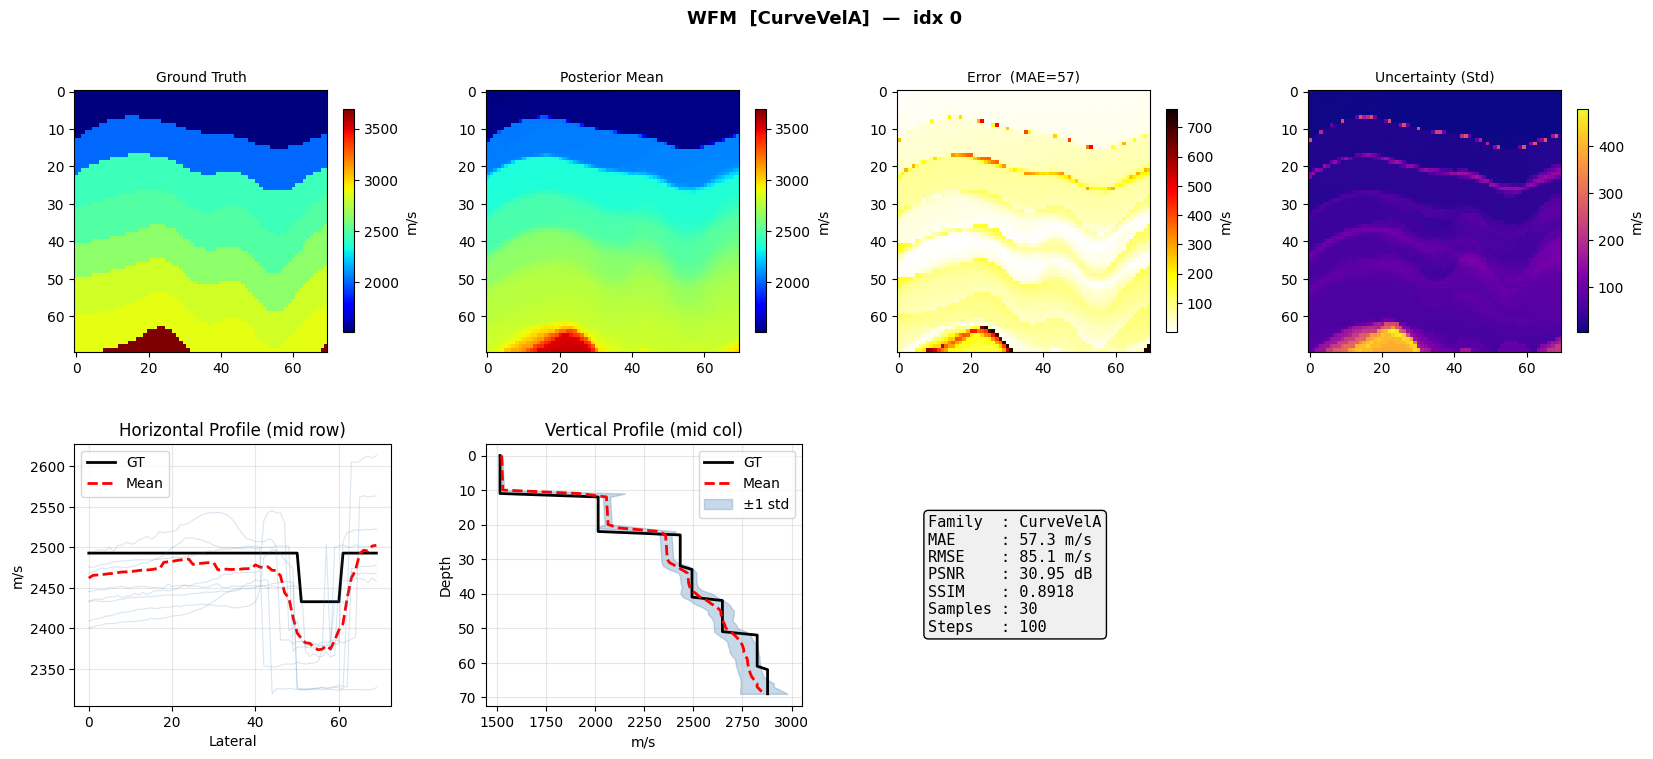

[CurveVelA] idx 1 | MAE 67.5 m/s | RMSE 112.7 m/s | PSNR 28.50 dB | SSIM 0.9451
  Saved → wfm_CurveVelA_idx1.png


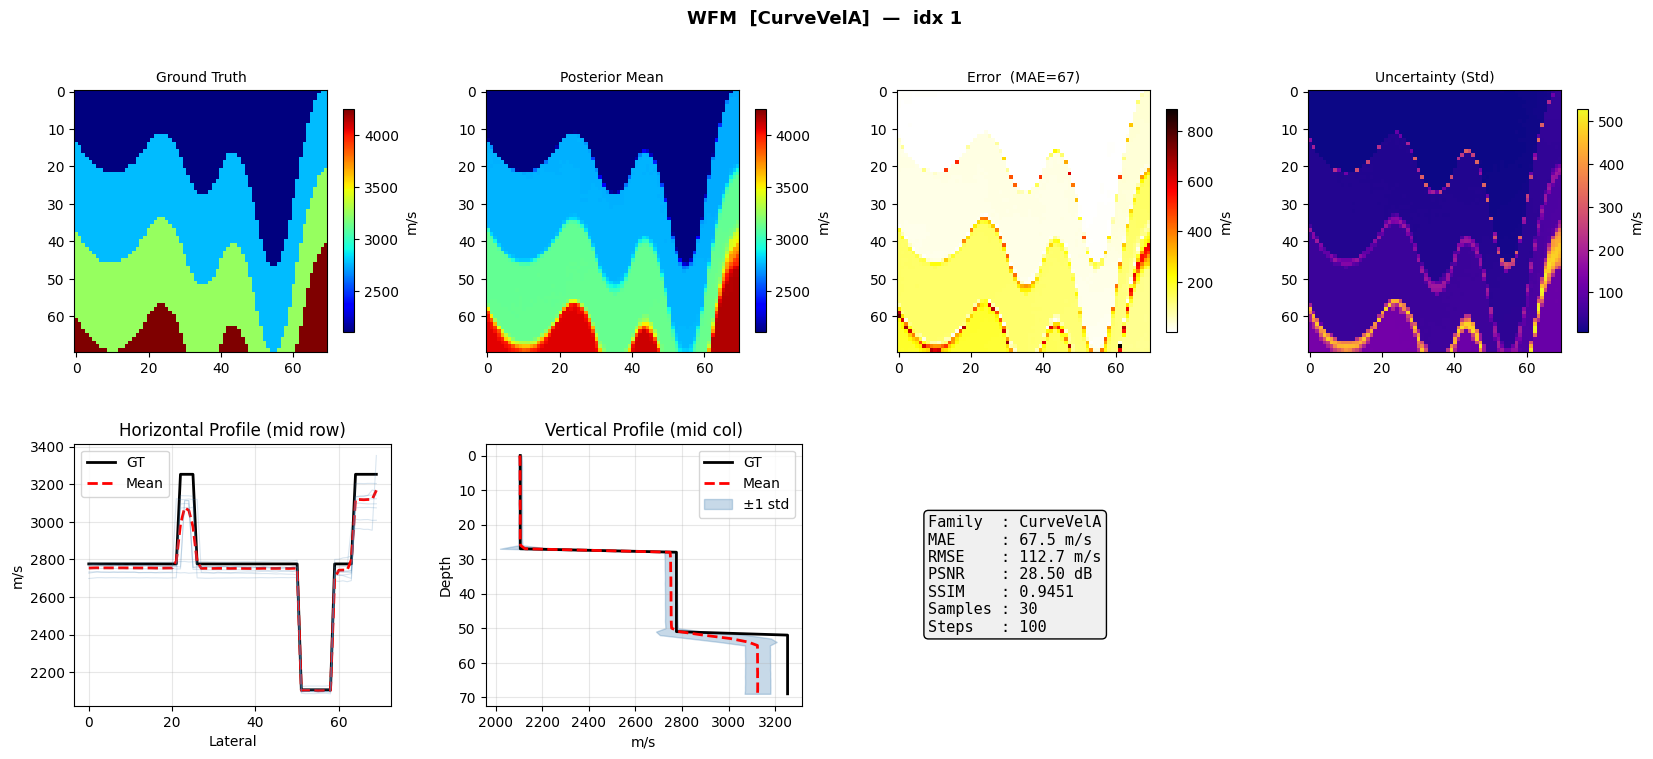

[FlatVelA] idx 6000 | MAE 220.4 m/s | RMSE 313.8 m/s | PSNR 19.61 dB | SSIM 0.8083
  Saved → wfm_FlatVelA_idx6000.png


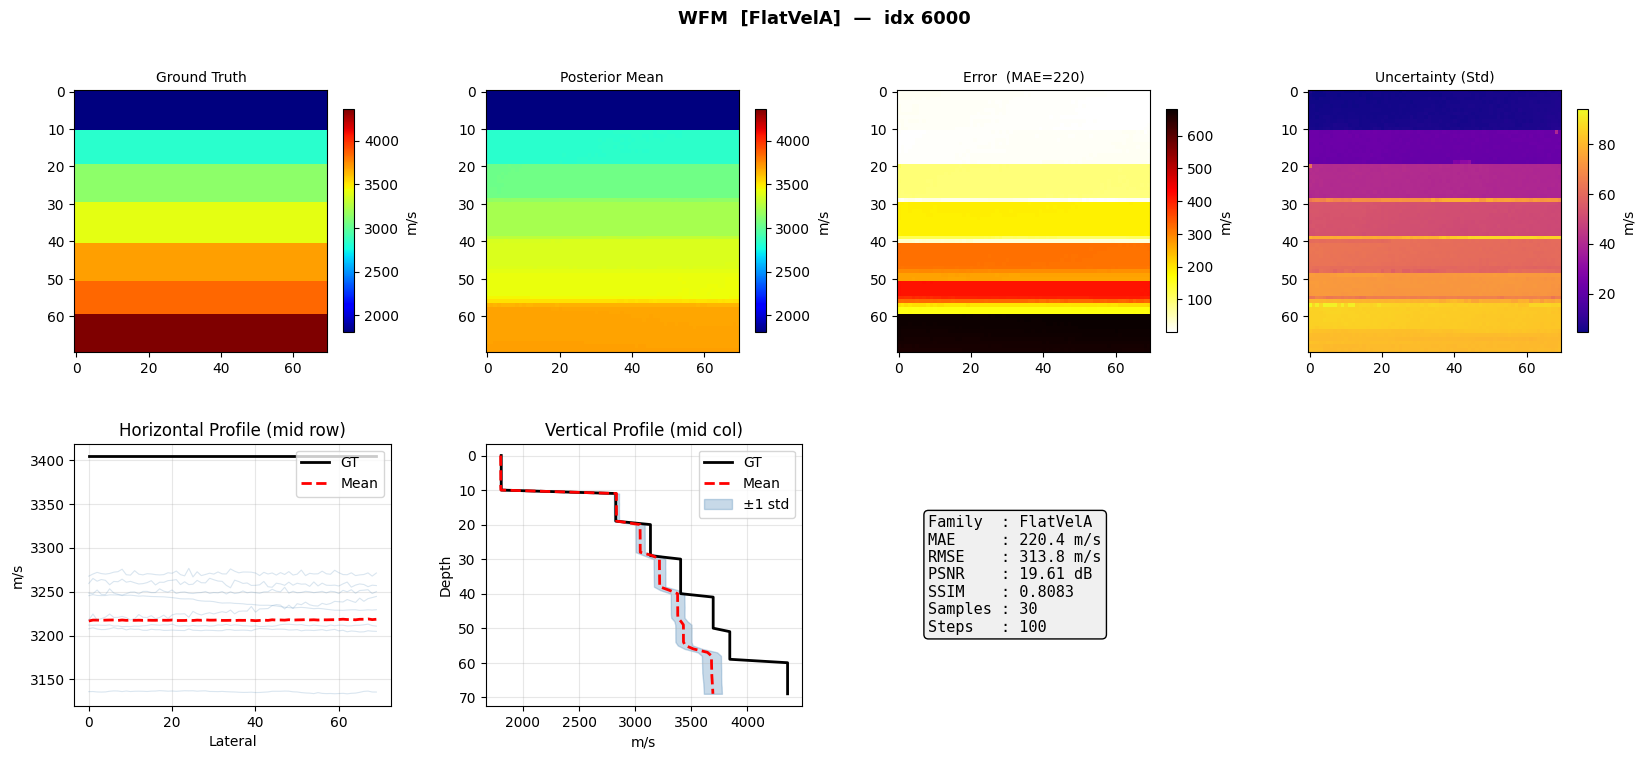

[FlatVelA] idx 6001 | MAE 114.4 m/s | RMSE 190.5 m/s | PSNR 23.94 dB | SSIM 0.8916
  Saved → wfm_FlatVelA_idx6001.png


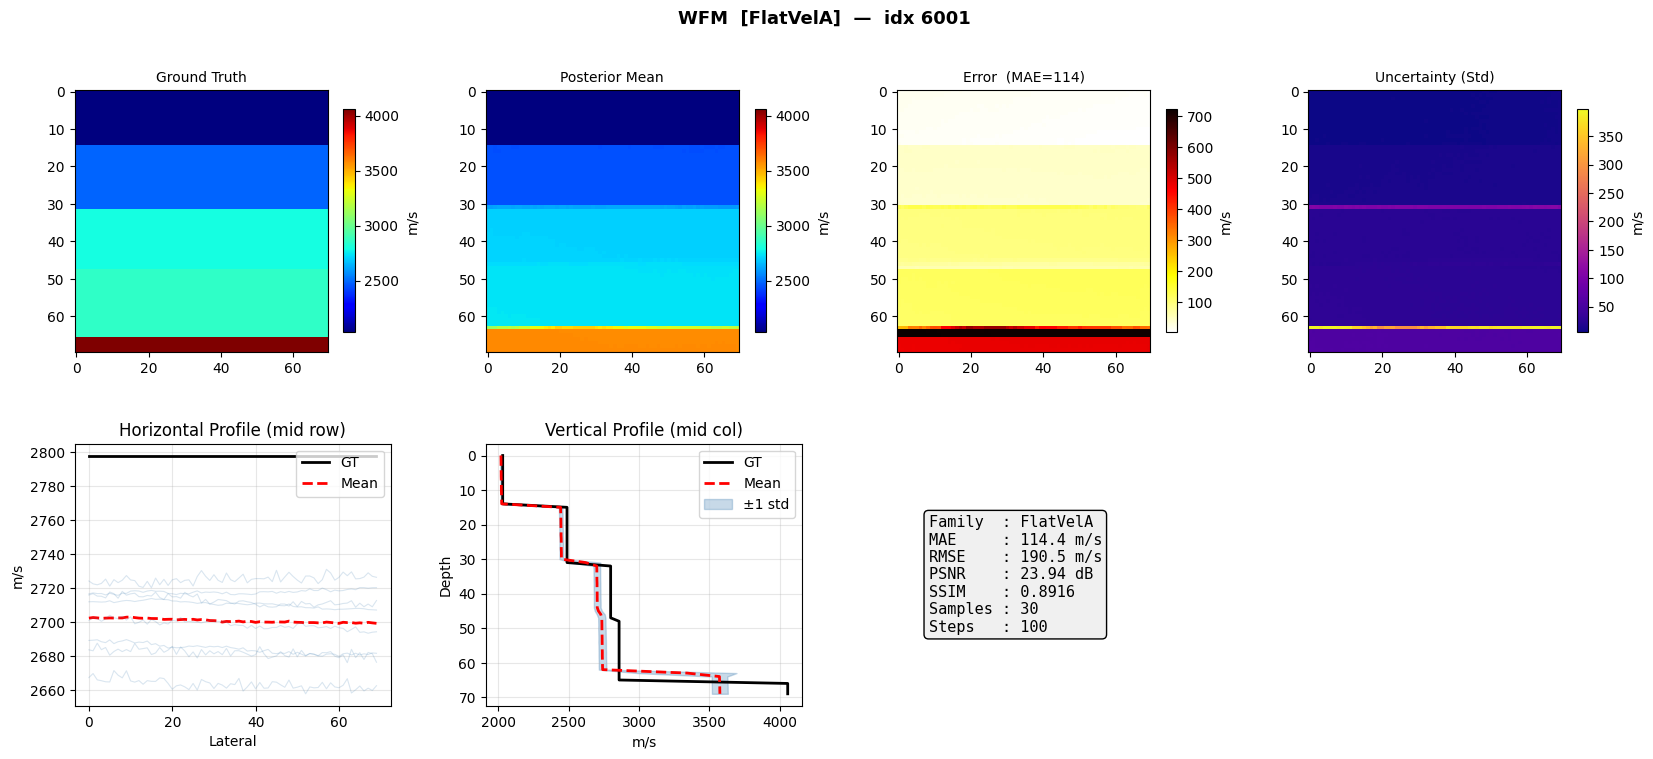

[CurveVelB] idx 12000 | MAE 160.8 m/s | RMSE 301.6 m/s | PSNR 19.95 dB | SSIM 0.8559
  Saved → wfm_CurveVelB_idx12000.png


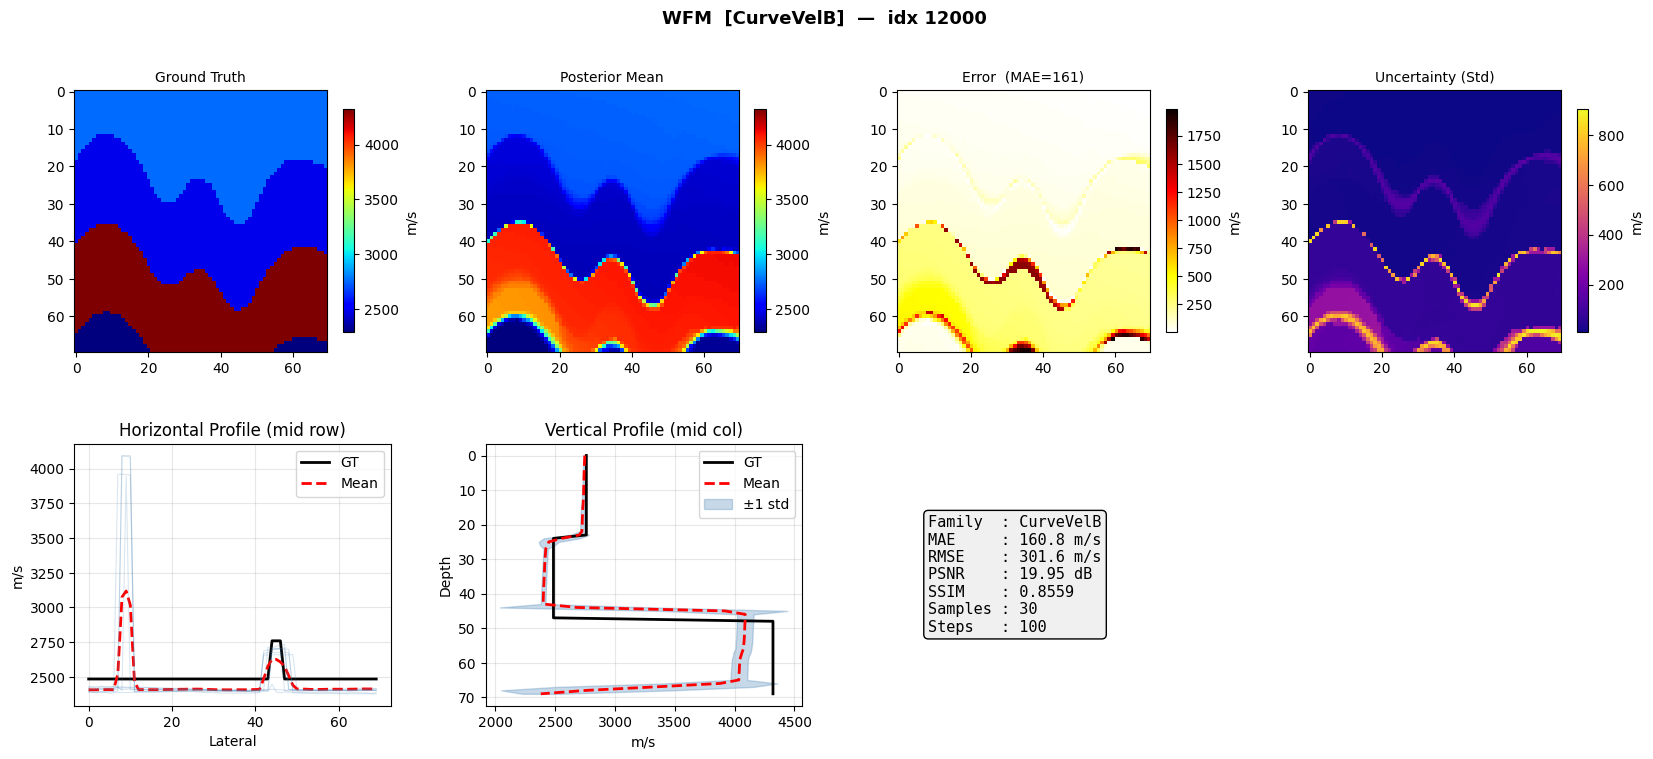

[CurveVelB] idx 12001 | MAE 216.8 m/s | RMSE 384.9 m/s | PSNR 17.84 dB | SSIM 0.7576
  Saved → wfm_CurveVelB_idx12001.png


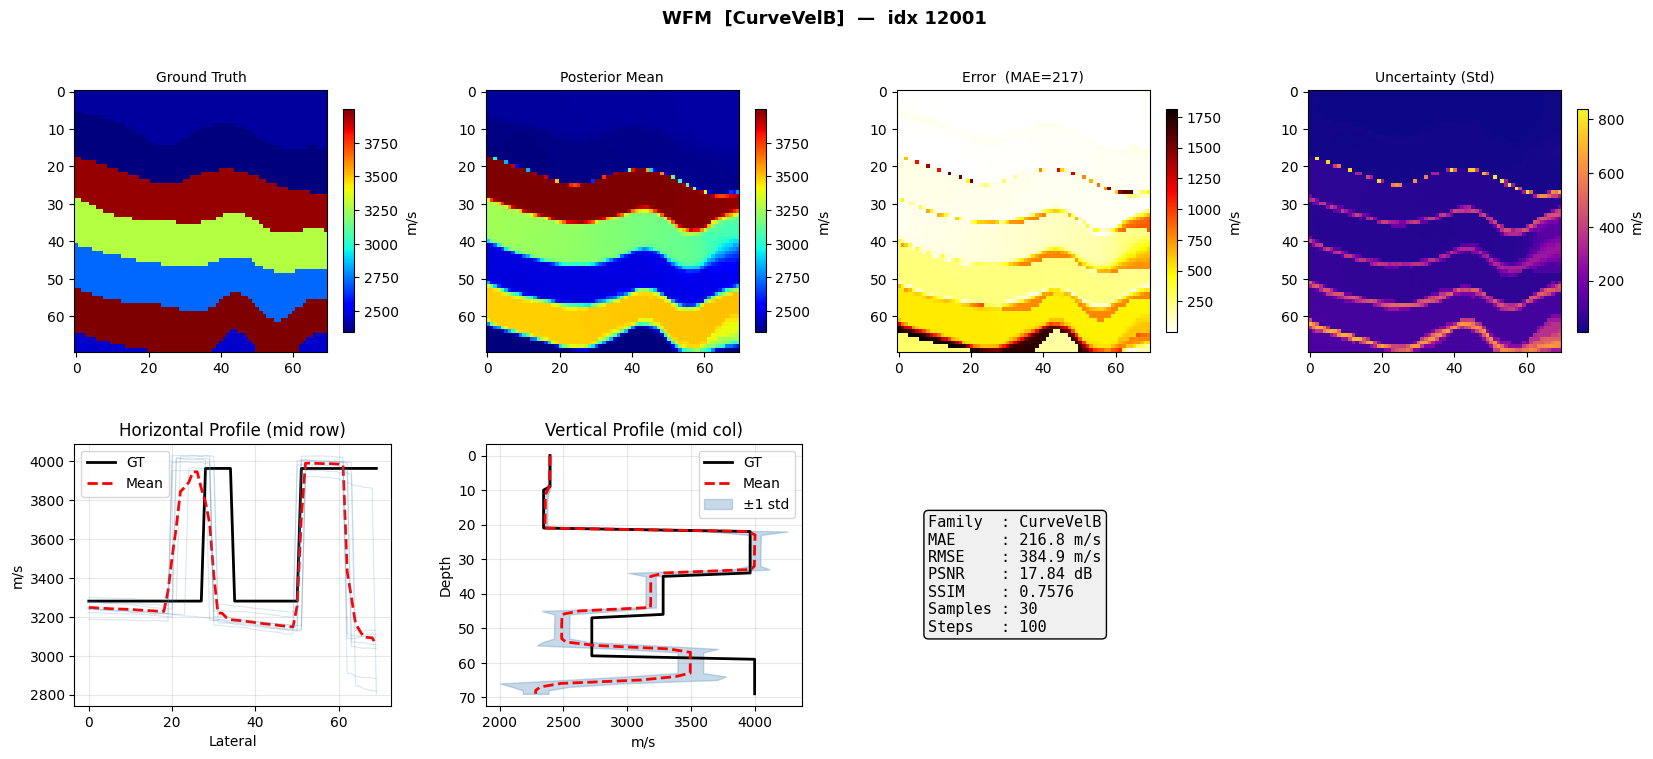

In [ ]:
 # ── 4. load best checkpoint ───────────────────────────────────────
ckpt = torch.load("best_WFM_multifamily.pt", map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"\nLoaded epoch {ckpt['epoch']}  "
          f"val RMSE {ckpt['val_rmse']:.1f} m/s")

    # ── 5. full inference + visualisation ─────────────────────────────
run_inference(model, val_loader, val_dataset,
                  v_min=ckpt['v_min'], v_max=ckpt['v_max'])

In [ ]:
pip install scikit-image

  Using cached scikit_image-0.26.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
  Using cached tifffile-2026.3.3-py3-none-any.whl.metadata (31 kB)
Using cached scikit_image-0.26.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (13.6 MB)
Using cached tifffile-2026.3.3-py3-none-any.whl (243 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
 pip install POT

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.4 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


# WFM trained separately for each dataset

# With more complex unet

In [ ]:
"""
WFM (Wasserstein Flow Matching) — Single Family Training
Trains one model per family, saves best, evaluates on val set.
Families : CurveVelA | FlatVelA | CurveVelB
"""

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.metrics import structural_similarity as skssim

try:
    import ot
except ImportError:
    raise ImportError("pip install POT")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════════════
# 1.  DATASET
# ═══════════════════════════════════════════════════════════════════════

FAMILY_DIRS = {
    "CurveVelA" : ("CurveVel_A", "data", "model"),
    "FlatVelA"  : ("FlatVel_A",  "data", "model"),
    "CurveVelB" : ("CurveVel_B", "data", "model"),
}

GLOBAL_VMIN = 1500.0
GLOBAL_VMAX = 4500.0


def load_family_arrays(base_dir, family_name):
    folder, data_sub, model_sub = FAMILY_DIRS[family_name]
    data_dir  = os.path.join(base_dir, folder, data_sub)
    model_dir = os.path.join(base_dir, folder, model_sub)

    data_files  = sorted(glob.glob(os.path.join(data_dir,  "data*.npy")))
    model_files = sorted(glob.glob(os.path.join(model_dir, "model*.npy")))

    assert len(data_files) > 0, f"No files in {data_dir}"
    assert len(data_files) == len(model_files)

    X = np.concatenate([np.load(f) for f in data_files],  axis=0)
    Y = np.concatenate([np.load(f) for f in model_files], axis=0)
    if Y.ndim == 3:
        Y = Y[:, None]
    return X.astype(np.float32), Y.astype(np.float32)


class SingleFamilyDataset(Dataset):
    def __init__(self, X, Y, vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX):
        self.X    = X
        self.Y    = Y
        self.vmin = vmin
        self.vmax = vmax

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seis = torch.from_numpy(self.X[idx].copy())
        vel  = torch.from_numpy(self.Y[idx].copy())
        vel  = (vel  - self.vmin) / (self.vmax - self.vmin + 1e-8)
        seis = (seis - seis.mean()) / (seis.std() + 1e-8)
        return vel, seis


def build_dataloaders(base_dir, family_name,
                      batch_size=48, val_ratio=0.2, seed=42):
    X, Y = load_family_arrays(base_dir, family_name)
    print(f"  {family_name}  N={len(X)}  "
          f"vmin={Y.min():.1f}  vmax={Y.max():.1f}")

    ds    = SingleFamilyDataset(X, Y)
    n_val = max(1, int(len(ds) * val_ratio))
    n_tr  = len(ds) - n_val
    gen   = torch.Generator().manual_seed(seed)
    tr, va = random_split(ds, [n_tr, n_val], generator=gen)

    train_loader = DataLoader(tr, batch_size=batch_size,
                              shuffle=True,  drop_last=True)
    val_loader   = DataLoader(va, batch_size=batch_size,
                              shuffle=False)
    return train_loader, val_loader


# ═══════════════════════════════════════════════════════════════════════
# 2.  MODEL
# ═══════════════════════════════════════════════════════════════════════

class SeismicEncoder(nn.Module):
    """Compresses (5, 1000, 70) seismic input → (B, out_ch, 70, 70)."""
    def __init__(self, out_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(5,   16,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(16,  32,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(32,  64,  (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(64,  128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(128, 128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),
        )
        self.proj = nn.Conv2d(128, out_channels, 1)

    def forward(self, y):
        return self.proj(self.net(y))   # (B, out_ch, 70, 70)


class TimeEmbed(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, 64),  nn.SiLU(),
            nn.Linear(64, embed_dim), nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, t):
        return self.mlp(t)


class ConvBlock(nn.Module):
    """GroupNorm + FiLM time conditioning."""
    def __init__(self, in_c, out_c, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)
        self.film  = nn.Linear(embed_dim, out_c * 2)

    def forward(self, x, emb):
        sc, sh = self.film(emb).chunk(2, dim=-1)
        h = F.silu(self.norm1(self.conv1(x)))
        h = h * (1 + sc[:,:,None,None]) + sh[:,:,None,None]
        h = F.silu(self.norm2(self.conv2(h)))
        return h


class UNet(nn.Module):
    """UNet with seismic encoder + skip connections + FiLM conditioning."""
    COND_CH = 32
    EMB_DIM = 128

    def __init__(self):
        super().__init__()
        self.seis_enc = SeismicEncoder(self.COND_CH)
        self.t_embed  = TimeEmbed(self.EMB_DIM)

        ic = 1 + self.COND_CH   # velocity + seismic features

        # Encoder
        self.c1   = ConvBlock(ic,   64,  self.EMB_DIM)
        self.c2   = ConvBlock(64,  128,  self.EMB_DIM)
        self.c3   = ConvBlock(128, 256,  self.EMB_DIM)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.mid  = ConvBlock(256, 256, self.EMB_DIM)

        # Decoder
        self.up1  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1   = ConvBlock(128+256, 128, self.EMB_DIM)
        self.up2  = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.d2   = ConvBlock( 64+128,  64, self.EMB_DIM)
        self.up3  = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.d3   = ConvBlock( 32+ 64,  32, self.EMB_DIM)

        self.out  = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, x, t, y):
        emb  = self.t_embed(t)
        cond = self.seis_enc(y)
        inp  = torch.cat([x, cond], 1)

        x1 = self.c1(inp,           emb)
        x2 = self.c2(self.pool(x1), emb)
        x3 = self.c3(self.pool(x2), emb)
        h  = self.mid(self.pool(x3), emb)

        h = self._match(self.up1(h), x3)
        h = self.d1(torch.cat([h, x3], 1), emb)
        h = self._match(self.up2(h), x2)
        h = self.d2(torch.cat([h, x2], 1), emb)
        h = self._match(self.up3(h), x1)
        h = self.d3(torch.cat([h, x1], 1), emb)

        return self.out(h)


# ═══════════════════════════════════════════════════════════════════════
# 3.  WFM LOSS
# ═══════════════════════════════════════════════════════════════════════

def image_gradients(z):
    return z[:,:,1:,:]-z[:,:,:-1,:], z[:,:,:,1:]-z[:,:,:,:-1]


def wfm_loss(model, x1, y, grad_weight=0.1):
    """OT sample pairing + flow matching loss."""
    B  = x1.size(0)
    x0 = torch.randn_like(x1)

    # OT matching in pixel space
    x0_np = x0.view(B,-1).detach().cpu().double().numpy()
    x1_np = x1.view(B,-1).detach().cpu().double().numpy()

    c = ot.dist(x0_np, x1_np, metric='sqeuclidean')
    c = c / (c.max() + 1e-8)
    g = ot.emd(np.ones(B)/B, np.ones(B)/B, c)

    # soft sampling from transport plan
    gt  = torch.tensor(g, dtype=torch.float32, device=x1.device)
    gt  = gt / (gt.sum(1, keepdim=True) + 1e-8)
    idx = torch.multinomial(gt, 1).squeeze(1)

    x1_match = x1[idx]
    y_match  = y[idx]

    # flow matching
    t      = torch.rand(B, 1, device=x1.device)
    xt     = (1-t.view(B,1,1,1))*x0 + t.view(B,1,1,1)*x1_match
    target = x1_match - x0
    pred   = model(xt, t, y_match)

    mse    = ((pred - target)**2).mean()
    ph, pw = image_gradients(pred)
    th, tw = image_gradients(target)
    return mse + grad_weight*(((ph-th)**2).mean() + ((pw-tw)**2).mean())


# ═══════════════════════════════════════════════════════════════════════
# 4.  SAMPLING
# ═══════════════════════════════════════════════════════════════════════

@torch.no_grad()
def sample_velocity(model, y, steps=100):
    model.eval()
    B  = y.size(0)
    x  = torch.randn(B, 1, 70, 70, device=y.device)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((B, 1), i/steps, device=y.device)
        x = x + model(x, t, y) * dt
    return x


@torch.no_grad()
def sample_multiple(model, y, n_samples=10, steps=100):
    """
    n_samples stochastic forward passes from different x0.
    Returns (n_samples, B, 1, H, W).
    """
    model.eval()
    all_preds = []
    for _ in range(n_samples):
        all_preds.append(sample_velocity(model, y, steps=steps))
    return torch.stack(all_preds, dim=0)


# ═══════════════════════════════════════════════════════════════════════
# 5.  METRICS
# ═══════════════════════════════════════════════════════════════════════

def denormalize(x, vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX):
    return x * (vmax - vmin) + vmin


def compute_metrics(pred, gt):
    dr  = float(GLOBAL_VMAX - GLOBAL_VMIN)
    mse = np.mean((pred - gt)**2)
    return {
        "MAE" : float(np.mean(np.abs(pred - gt))),
        "RMSE": float(np.sqrt(mse)),
        "PSNR": float(10 * np.log10(dr**2 / (mse + 1e-8))),
        "SSIM": float(skssim(gt, pred, data_range=dr)),
        "REL" : float(np.mean(np.abs(pred-gt)) /
                      (gt.max()-gt.min()+1e-8) * 100),
    }


# ═══════════════════════════════════════════════════════════════════════
# 6.  EVALUATE  (defined BEFORE train_one_family so it can be called inside)
# ═══════════════════════════════════════════════════════════════════════

def evaluate(model, val_loader, steps=100):
    """Returns mean metrics over full val set in m/s."""
    model.eval()
    all_metrics = []

    with torch.no_grad():
        for vel, seis in val_loader:
            vel  = vel.to(device)
            seis = seis.to(device)

            pred    = sample_velocity(model, seis, steps=steps)
            pred_np = denormalize(pred.cpu().numpy())
            gt_np   = denormalize(vel.cpu().numpy())

            for i in range(pred_np.shape[0]):
                all_metrics.append(
                    compute_metrics(pred_np[i,0], gt_np[i,0]))

    keys = all_metrics[0].keys()
    return {k: float(np.mean([m[k] for m in all_metrics]))
            for k in keys}


# ═══════════════════════════════════════════════════════════════════════
# 7.  TRAIN ONE FAMILY
# ═══════════════════════════════════════════════════════════════════════

def train_one_family(model, train_loader, val_loader,
                     family_name, epochs=500, save_path=None):

    if save_path is None:
        save_path = f"WFM_{family_name}.pt"

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.05,
    )

    best_rmse    = float('inf')
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total = 0.0

        pbar = tqdm(train_loader,
                    desc=f'[{family_name}] Epoch {epoch:4d}/{epochs}',
                    leave=False)
        for vel, seis in pbar:
            vel  = vel.to(device)
            seis = seis.to(device)

            loss = wfm_loss(model, vel, seis, grad_weight=0.1)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sch.step()
            total += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}')

        train_loss = total / len(train_loader)
        loss_history.append(train_loss)

        # validate every 5 epochs with fast steps=20
        if epoch % 5 == 0:
            results  = evaluate(model, val_loader, steps=20)
            val_rmse = results["RMSE"]
            print(f"  [{family_name}] Epoch {epoch:4d} | "
                  f"Loss {train_loss:.4f} | "
                  f"RMSE {val_rmse:.1f} m/s | "
                  f"Best {best_rmse:.1f} m/s")

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                torch.save({
                    'epoch'    : epoch,
                    'model'    : model.state_dict(),
                    'val_rmse' : val_rmse,
                    'family'   : family_name,
                }, save_path)
                print(f"    ✓ Saved  (RMSE={best_rmse:.1f} m/s)")

    return loss_history, best_rmse


# ═══════════════════════════════════════════════════════════════════════
# 8.  VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════

def visualize_family(model, val_loader, family_name,
                     save_dir='.', n_samples=10, steps=100,
                     n_show=2, vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX):
    """
    For each of n_show val samples:
      Col 1 : Ground Truth
      Col 2 : Posterior Mean   (mean over n_samples stochastic runs)
      Col 3 : Error Map        |mean − GT|
      Col 4 : Uncertainty Map  (std over n_samples stochastic runs)
    """
    model.eval()

    # collect n_show samples
    vel_list, seis_list = [], []
    for vel, seis in val_loader:
        vel_list.append(vel)
        seis_list.append(seis)
        if sum(v.shape[0] for v in vel_list) >= n_show:
            break

    vel_all  = torch.cat(vel_list,  dim=0)[:n_show]   # (n_show, 1, H, W)
    seis_all = torch.cat(seis_list, dim=0)[:n_show]   # (n_show, 5, T, R)
    seis_all = seis_all.to(device)

    # n_samples stochastic predictions → (n_samples, n_show, 1, H, W)
    all_preds = sample_multiple(model, seis_all,
                                n_samples=n_samples, steps=steps)

    gt_ms          = denormalize(vel_all.numpy())           # (n_show, 1, H, W)
    preds_ms       = denormalize(all_preds.cpu().numpy())   # (n_samples, n_show, 1, H, W)
    posterior_mean = preds_ms.mean(axis=0)                  # (n_show, 1, H, W)
    posterior_std  = preds_ms.std(axis=0)                   # (n_show, 1, H, W)
    error_map      = np.abs(posterior_mean - gt_ms)

    col_titles = [
        'Ground Truth',
        'Posterior Mean',
        'Error  |mean − GT|',
        f'Uncertainty  (std, {n_samples} samples)',
    ]

    fig = plt.figure(figsize=(16, 4 * n_show))
    gs  = gridspec.GridSpec(n_show, 4, figure=fig,
                            hspace=0.35, wspace=0.25)

    for row in range(n_show):
        gt   = gt_ms[row, 0]
        mean = posterior_mean[row, 0]
        err  = error_map[row, 0]
        std  = posterior_std[row, 0]

        err_max = max(float(err.max()), 1.0)
        std_max = max(float(std.max()), 1.0)

        panels = [
            (gt,   'seismic', vmin,    vmax,    f'{vmin:.0f} m/s', f'{vmax:.0f} m/s'),
            (mean, 'seismic', vmin,    vmax,    f'{vmin:.0f} m/s', f'{vmax:.0f} m/s'),
            (err,  'hot',     0,       err_max, '0',               f'{err_max:.0f} m/s'),
            (std,  'plasma',  0,       std_max, '0',               f'{std_max:.0f} m/s'),
        ]

        for col, (data, cmap, lo, hi, cbar_lo, cbar_hi) in enumerate(panels):
            ax = fig.add_subplot(gs[row, col])
            im = ax.imshow(data, cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', origin='upper')
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=7)
            cbar.set_ticks([lo, hi])
            cbar.set_ticklabels([cbar_lo, cbar_hi])
            ax.set_xticks([]); ax.set_yticks([])

            if row == 0:
                ax.set_title(col_titles[col], fontsize=11, fontweight='bold')
            if col == 0:
                ax.set_ylabel(f'Sample {row+1}', fontsize=9)

            # per-panel stats as xlabel
            if col == 0:
                ax.set_xlabel(
                    f'GT range: [{data.min():.0f}, {data.max():.0f}] m/s',
                    fontsize=7)
            elif col == 1:
                rmse = np.sqrt(np.mean((mean - gt)**2))
                ax.set_xlabel(f'RMSE={rmse:.1f} m/s', fontsize=7)
            elif col == 2:
                ax.set_xlabel(
                    f'MAE={err.mean():.1f}  Max={err.max():.1f} m/s',
                    fontsize=7)
            elif col == 3:
                ax.set_xlabel(
                    f'Mean std={std.mean():.1f}  Max={std.max():.1f} m/s',
                    fontsize=7)

    fig.suptitle(f'WFM Posterior Visualization — {family_name}',
                 fontsize=14, fontweight='bold', y=1.01)

    os.makedirs(save_dir, exist_ok=True)
    out_path = os.path.join(save_dir, f'viz_{family_name}.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Visualization saved → {out_path}')
    return out_path


def plot_summary_all_families(families, base_dir, save_dir='./viz_outputs'):
    """
    One combined figure: rows = families, cols = GT / Mean / Error / Uncertainty.
    Uses already-saved best checkpoints.
    """
    fig, axes = plt.subplots(len(families), 4,
                             figsize=(16, 4 * len(families)))
    if len(families) == 1:
        axes = axes[None]

    col_titles = ['Ground Truth', 'Posterior Mean',
                  'Error |mean − GT|', 'Uncertainty (std)']

    for row_i, family in enumerate(families):
        ckpt_path = f'WFM_{family}.pt'
        ckpt      = torch.load(ckpt_path, map_location=device,
                               weights_only=False)
        model_tmp = UNet().to(device)
        model_tmp.load_state_dict(ckpt['model'])
        model_tmp.eval()

        _, val_loader_tmp = build_dataloaders(base_dir, family, batch_size=4)

        vel, seis = next(iter(val_loader_tmp))
        vel  = vel[:1]
        seis = seis[:1].to(device)

        preds    = sample_multiple(model_tmp, seis, n_samples=10, steps=50)
        gt_ms    = denormalize(vel.numpy())[0, 0]
        preds_ms = denormalize(preds.cpu().numpy())[:, 0, 0]
        mean_ms  = preds_ms.mean(0)
        std_ms   = preds_ms.std(0)
        err_ms   = np.abs(mean_ms - gt_ms)

        data_panels = [
            (gt_ms,   'seismic', GLOBAL_VMIN,    GLOBAL_VMAX),
            (mean_ms, 'seismic', GLOBAL_VMIN,    GLOBAL_VMAX),
            (err_ms,  'hot',     0,               max(float(err_ms.max()), 1.0)),
            (std_ms,  'plasma',  0,               max(float(std_ms.max()), 1.0)),
        ]

        for col, (data, cmap, lo, hi) in enumerate(data_panels):
            ax = axes[row_i, col]
            im = ax.imshow(data, cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', origin='upper')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.set_xticks([]); ax.set_yticks([])
            if row_i == 0:
                ax.set_title(col_titles[col], fontsize=10, fontweight='bold')
            if col == 0:
                ax.set_ylabel(family, fontsize=10, fontweight='bold')

    plt.suptitle('WFM — All Families Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    summary_path = os.path.join(save_dir, 'summary_all_families.png')
    plt.savefig(summary_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Summary figure → {summary_path}')


def plot_loss_curves(histories, save_dir='./viz_outputs'):
    """Plot training loss curves for all families on one figure."""
    os.makedirs(save_dir, exist_ok=True)
    plt.figure(figsize=(8, 4))
    for family, history in histories.items():
        plt.plot(history, label=family)
    plt.xlabel('Epoch'); plt.ylabel('WFM Loss')
    plt.title('Training Loss — All Families')
    plt.legend(); plt.tight_layout()
    path = os.path.join(save_dir, 'loss_curves.png')
    plt.savefig(path, dpi=150)
    plt.close()
    print(f'  Loss curves → {path}')


# ═══════════════════════════════════════════════════════════════════════
# 9.  COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════

def print_comparison_table(all_results):
    """
    all_results : {'CurveVelA': {MAE:.., RMSE:.., SSIM:..}, ...}
    Baselines from OpenFWI (Deng et al. NeurIPS 2022).
    CurveVelB baselines marked as N/A (not reported in paper).
    """
    baselines = {
        "InversionNet": {
            "CurveVelA" : {"MAE": 205.5, "RMSE": 381.9, "SSIM": 0.8074},
            "FlatVelA"  : {"MAE":  39.3, "RMSE":  63.3, "SSIM": 0.9895},
            "CurveVelB" : {"MAE": float('nan'), "RMSE": float('nan'), "SSIM": float('nan')},
        },
        "VelocityGAN": {
            "CurveVelA" : {"MAE": 144.6, "RMSE": 310.2, "SSIM": 0.8624},
            "FlatVelA"  : {"MAE":  35.4, "RMSE":  53.4, "SSIM": 0.9916},
            "CurveVelB" : {"MAE": float('nan'), "RMSE": float('nan'), "SSIM": float('nan')},
        },
    }

    families = ["CurveVelA", "FlatVelA", "CurveVelB"]

    def fmt(v):
        return f'{v:>9.1f}' if not np.isnan(v) else f'{"N/A":>9}'

    print("\n" + "═"*85)
    print(f"  {'Model':<20}", end="")
    for fam in families:
        print(f"{fam:>27}", end="")
    print()
    print(f"  {'':20}", end="")
    for _ in families:
        print(f"{'MAE':>9}{'RMSE':>9}{'SSIM':>9}", end="")
    print()
    print("─"*85)

    for model_name, fam_res in baselines.items():
        print(f"  {model_name:<20}", end="")
        for fam in families:
            r = fam_res[fam]
            ssim_str = f'{r["SSIM"]:>9.4f}' if not np.isnan(r["SSIM"]) else f'{"N/A":>9}'
            print(f'{fmt(r["MAE"])}{fmt(r["RMSE"])}{ssim_str}', end="")
        print()

    print("─"*85)
    print(f"  {'WFM (ours)':<20}", end="")
    for fam in families:
        r    = all_results.get(fam, {})
        mae  = r.get("MAE",  float('nan'))
        rmse = r.get("RMSE", float('nan'))
        ssim = r.get("SSIM", float('nan'))
        ssim_str = f'{ssim:>9.4f}' if not np.isnan(ssim) else f'{"N/A":>9}'
        print(f'{fmt(mae)}{fmt(rmse)}{ssim_str}', end="")
    print()
    print("═"*85)
    print("  Note: baselines from OpenFWI paper (24K–48K samples).")
    print("        WFM trained on ~1350 samples per family.")
    print("        CurveVelB baselines not reported in original paper.")


# ═══════════════════════════════════════════════════════════════════════
# 10. MAIN
# ═══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    BASE_DIR = "/DATA/Flow_Matching"
    EPOCHS   = 300
    FAMILIES = ["CurveVelA", "FlatVelA", "CurveVelB"]
    VIZ_DIR  = "./viz_outputs"

    all_results   = {}
    loss_histories = {}

    for family in FAMILIES:

        print(f"\n{'='*55}")
        print(f"  Training WFM on  {family}")
        print(f"{'='*55}")

        # data
        train_loader, val_loader = build_dataloaders(
            BASE_DIR, family, batch_size=48)

        # model
        model = UNet().to(device)
        print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

        # train
        save_path = f"WFM_{family}.pt"
        history, best_rmse = train_one_family(
            model, train_loader, val_loader,
            family_name = family,
            epochs      = EPOCHS,
            save_path   = save_path,
        )
        loss_histories[family] = history

        # load best checkpoint
        ckpt = torch.load(save_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model'])
        model.eval()
        print(f"\n  Loaded best epoch {ckpt['epoch']} "
              f"(RMSE={ckpt['val_rmse']:.1f} m/s)")

        # final evaluation with steps=100
        print(f"  Running full val evaluation (steps=100) …")
        results = evaluate(model, val_loader, steps=100)
        all_results[family] = results

        print(f"\n  ── {family} Final Results ──")
        for k, v in results.items():
            print(f"    {k:<6}: {v:.4f}")

        # per-family visualization
        print(f"  Generating visualizations …")
        visualize_family(
            model, val_loader,
            family_name = family,
            save_dir    = VIZ_DIR,
            n_samples   = 10,
            steps       = 100,
            n_show      = 2,
        )

    # comparison table
    print_comparison_table(all_results)

    # loss curves
    plot_loss_curves(loss_histories, save_dir=VIZ_DIR)

    # combined summary figure
    print("\n  Generating combined summary figure …")
    plot_summary_all_families(FAMILIES, BASE_DIR, save_dir=VIZ_DIR)

    print(f"\n  All outputs saved to: {VIZ_DIR}")

Device: cuda

  Training WFM on  CurveVelA
  CurveVelA  N=30000  vmin=1500.0  vmax=4500.0
  Parameters: 3,974,113


  [CurveVelA] Epoch    0 | Loss 0.3042 | RMSE 671.3 m/s | Best inf m/s
    ✓ Saved  (RMSE=671.3 m/s)


  [CurveVelA] Epoch    5 | Loss 0.0473 | RMSE 576.3 m/s | Best 671.3 m/s
    ✓ Saved  (RMSE=576.3 m/s)


  [CurveVelA] Epoch   10 | Loss 0.0288 | RMSE 478.0 m/s | Best 576.3 m/s
    ✓ Saved  (RMSE=478.0 m/s)


  [CurveVelA] Epoch   15 | Loss 0.0215 | RMSE 373.0 m/s | Best 478.0 m/s
    ✓ Saved  (RMSE=373.0 m/s)


...

  [CurveVelB] Epoch  280 | Loss 0.0136 | RMSE 354.6 m/s | Best 354.4 m/s


  [CurveVelB] Epoch  285 | Loss 0.0137 | RMSE 354.5 m/s | Best 354.4 m/s


  [CurveVelB] Epoch  290 | Loss 0.0137 | RMSE 354.9 m/s | Best 354.4 m/s


  [CurveVelB] Epoch  295 | Loss 0.0134 | RMSE 354.1 m/s | Best 354.4 m/s
    ✓ Saved  (RMSE=354.1 m/s)



  Loaded best epoch 295 (RMSE=354.1 m/s)
  Running full val evaluation (steps=100) …

  ── CurveVelB Final Results ──
    MAE   : 191.0700
    RMSE  : 357.0516
    PSNR  : 19.1262
    SSIM  : 0.7259
    REL   : 9.2775
  Generating visualizations …
  Visualization saved → ./viz_outputs/viz_CurveVelB.png

═════════════════════════════════════════════════════════════════════════════════════
  Model                                 CurveVelA                   FlatVelA                  CurveVelB
                            MAE     RMSE     SSIM      MAE     RMSE     SSIM      MAE     RMSE     SSIM
─────────────────────────────────────────────────────────────────────────────────────
  InversionNet            205.5    381.9   0.8074     39.3     63.3   0.9895      N/A      N/A      N/A
  VelocityGAN             144.6    310.2   0.8624     35.4     53.4   0.9916      N/A      N/A      N/A
─────────────────────────────────────────────────────────────────────────────────────
  WFM (ours)        

# CFM on different dataset

In [ ]:
"""
CFM (Conditional Flow Matching) — Single Family Training
Trains one model per family, saves best, evaluates on val set.
Families : CurveVelA | FlatVelA | CurveVelB

Key difference from WFM:
  - No OT transport plan / POT library
  - Simple linear interpolation:  x_t = (1-t)*x0 + t*x1
  - Target vector field:          v   = x1 - x0
  - x0 ~ N(0,I)  independent of  x1
"""

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.metrics import structural_similarity as skssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════════════
# 1.  DATASET
# ═══════════════════════════════════════════════════════════════════════

FAMILY_DIRS = {
    "CurveVelA" : ("CurveVel_A", "data", "model"),
    "FlatVelA"  : ("FlatVel_A",  "data", "model"),
    "CurveVelB" : ("CurveVel_B", "data", "model"),
}

GLOBAL_VMIN = 1500.0
GLOBAL_VMAX = 4500.0


def load_family_arrays(base_dir, family_name):
    folder, data_sub, model_sub = FAMILY_DIRS[family_name]
    data_dir  = os.path.join(base_dir, folder, data_sub)
    model_dir = os.path.join(base_dir, folder, model_sub)

    data_files  = sorted(glob.glob(os.path.join(data_dir,  "data*.npy")))
    model_files = sorted(glob.glob(os.path.join(model_dir, "model*.npy")))

    assert len(data_files) > 0, f"No files in {data_dir}"
    assert len(data_files) == len(model_files)

    X = np.concatenate([np.load(f) for f in data_files],  axis=0)
    Y = np.concatenate([np.load(f) for f in model_files], axis=0)
    if Y.ndim == 3:
        Y = Y[:, None]
    return X.astype(np.float32), Y.astype(np.float32)


class SingleFamilyDataset(Dataset):
    def __init__(self, X, Y, vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX):
        self.X    = X
        self.Y    = Y
        self.vmin = vmin
        self.vmax = vmax

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seis = torch.from_numpy(self.X[idx].copy())
        vel  = torch.from_numpy(self.Y[idx].copy())
        vel  = (vel  - self.vmin) / (self.vmax - self.vmin + 1e-8)
        seis = (seis - seis.mean()) / (seis.std() + 1e-8)
        return vel, seis


def build_dataloaders(base_dir, family_name,
                      batch_size=48, val_ratio=0.2, seed=42):
    X, Y = load_family_arrays(base_dir, family_name)
    print(f"  {family_name}  N={len(X)}  "
          f"vmin={Y.min():.1f}  vmax={Y.max():.1f}")

    ds    = SingleFamilyDataset(X, Y)
    n_val = max(1, int(len(ds) * val_ratio))
    n_tr  = len(ds) - n_val
    gen   = torch.Generator().manual_seed(seed)
    tr, va = random_split(ds, [n_tr, n_val], generator=gen)

    train_loader = DataLoader(tr, batch_size=batch_size,
                              shuffle=True,  drop_last=True)
    val_loader   = DataLoader(va, batch_size=batch_size,
                              shuffle=False)
    return train_loader, val_loader


# ═══════════════════════════════════════════════════════════════════════
# 2.  MODEL
# ═══════════════════════════════════════════════════════════════════════

class SeismicEncoder(nn.Module):
    """Compresses (5, 1000, 70) seismic input → (B, out_ch, 70, 70)."""
    def __init__(self, out_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(5,   16,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(16,  32,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(32,  64,  (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(64,  128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(128, 128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),
        )
        self.proj = nn.Conv2d(128, out_channels, 1)

    def forward(self, y):
        return self.proj(self.net(y))   # (B, out_ch, 70, 70)


class TimeEmbed(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, 64),  nn.SiLU(),
            nn.Linear(64, embed_dim), nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, t):
        return self.mlp(t)


class ConvBlock(nn.Module):
    """GroupNorm + FiLM time conditioning."""
    def __init__(self, in_c, out_c, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)
        self.film  = nn.Linear(embed_dim, out_c * 2)

    def forward(self, x, emb):
        sc, sh = self.film(emb).chunk(2, dim=-1)
        h = F.silu(self.norm1(self.conv1(x)))
        h = h * (1 + sc[:,:,None,None]) + sh[:,:,None,None]
        h = F.silu(self.norm2(self.conv2(h)))
        return h


class UNet(nn.Module):
    """UNet with seismic encoder + skip connections + FiLM conditioning."""
    COND_CH = 32
    EMB_DIM = 128

    def __init__(self):
        super().__init__()
        self.seis_enc = SeismicEncoder(self.COND_CH)
        self.t_embed  = TimeEmbed(self.EMB_DIM)

        ic = 1 + self.COND_CH   # velocity + seismic features

        # Encoder
        self.c1   = ConvBlock(ic,   64,  self.EMB_DIM)
        self.c2   = ConvBlock(64,  128,  self.EMB_DIM)
        self.c3   = ConvBlock(128, 256,  self.EMB_DIM)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.mid  = ConvBlock(256, 256, self.EMB_DIM)

        # Decoder
        self.up1  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1   = ConvBlock(128+256, 128, self.EMB_DIM)
        self.up2  = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.d2   = ConvBlock( 64+128,  64, self.EMB_DIM)
        self.up3  = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.d3   = ConvBlock( 32+ 64,  32, self.EMB_DIM)

        self.out  = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, x, t, y):
        emb  = self.t_embed(t)
        cond = self.seis_enc(y)
        inp  = torch.cat([x, cond], 1)

        x1 = self.c1(inp,           emb)
        x2 = self.c2(self.pool(x1), emb)
        x3 = self.c3(self.pool(x2), emb)
        h  = self.mid(self.pool(x3), emb)

        h = self._match(self.up1(h), x3)
        h = self.d1(torch.cat([h, x3], 1), emb)
        h = self._match(self.up2(h), x2)
        h = self.d2(torch.cat([h, x2], 1), emb)
        h = self._match(self.up3(h), x1)
        h = self.d3(torch.cat([h, x1], 1), emb)

        return self.out(h)


# ═══════════════════════════════════════════════════════════════════════
# 3.  CFM LOSS
# ═══════════════════════════════════════════════════════════════════════

def image_gradients(z):
    return z[:,:,1:,:]-z[:,:,:-1,:], z[:,:,:,1:]-z[:,:,:,:-1]


def cfm_loss(model, x1, y, grad_weight=0.1):
    """
    Conditional Flow Matching loss.

    Path:   x_t = (1 - t) * x0  +  t * x1
    Target: v*  = x1 - x0

    x0 is sampled independently from N(0, I) for each x1.
    No OT pairing — each (x0, x1) pair defines its own straight-line path.
    The model learns the conditional vector field  v_theta(x_t, t | y) ≈ v*.
    """
    B  = x1.size(0)

    # Sample noise independently — no transport plan needed
    x0 = torch.randn_like(x1)

    # Sample time uniformly in (0, 1)
    t = torch.rand(B, 1, device=x1.device)

    # Interpolate along the straight-line path
    xt     = (1 - t.view(B, 1, 1, 1)) * x0 + t.view(B, 1, 1, 1) * x1

    # Ground-truth vector field  v* = x1 - x0
    target = x1 - x0

    # Model prediction
    pred = model(xt, t, y)

    # MSE loss on the vector field
    mse = ((pred - target) ** 2).mean()

    # Optional gradient regularisation (same as WFM version)
    ph, pw = image_gradients(pred)
    th, tw = image_gradients(target)
    grad_loss = ((ph - th) ** 2).mean() + ((pw - tw) ** 2).mean()

    return mse + grad_weight * grad_loss


# ═══════════════════════════════════════════════════════════════════════
# 4.  SAMPLING
# ═══════════════════════════════════════════════════════════════════════

@torch.no_grad()
def sample_velocity(model, y, steps=100):
    """
    Euler integration of the learned vector field from t=0 to t=1.
    x_0 ~ N(0, I),  dx = v_theta(x_t, t | y) * dt
    """
    model.eval()
    B  = y.size(0)
    x  = torch.randn(B, 1, 70, 70, device=y.device)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=y.device)
        x = x + model(x, t, y) * dt
    return x


@torch.no_grad()
def sample_multiple(model, y, n_samples=10, steps=100):
    """
    n_samples stochastic forward passes from different x0.
    Returns (n_samples, B, 1, H, W).
    """
    model.eval()
    all_preds = []
    for _ in range(n_samples):
        all_preds.append(sample_velocity(model, y, steps=steps))
    return torch.stack(all_preds, dim=0)


# ═══════════════════════════════════════════════════════════════════════
# 5.  METRICS
# ═══════════════════════════════════════════════════════════════════════

def denormalize(x, vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX):
    return x * (vmax - vmin) + vmin


def compute_metrics(pred, gt):
    dr  = float(GLOBAL_VMAX - GLOBAL_VMIN)
    mse = np.mean((pred - gt)**2)
    return {
        "MAE" : float(np.mean(np.abs(pred - gt))),
        "RMSE": float(np.sqrt(mse)),
        "PSNR": float(10 * np.log10(dr**2 / (mse + 1e-8))),
        "SSIM": float(skssim(gt, pred, data_range=dr)),
        "REL" : float(np.mean(np.abs(pred-gt)) /
                      (gt.max()-gt.min()+1e-8) * 100),
    }


# ═══════════════════════════════════════════════════════════════════════
# 6.  EVALUATE
# ═══════════════════════════════════════════════════════════════════════

def evaluate(model, val_loader, steps=100):
    """Returns mean metrics over full val set in m/s."""
    model.eval()
    all_metrics = []

    with torch.no_grad():
        for vel, seis in val_loader:
            vel  = vel.to(device)
            seis = seis.to(device)

            pred    = sample_velocity(model, seis, steps=steps)
            pred_np = denormalize(pred.cpu().numpy())
            gt_np   = denormalize(vel.cpu().numpy())

            for i in range(pred_np.shape[0]):
                all_metrics.append(
                    compute_metrics(pred_np[i, 0], gt_np[i, 0]))

    keys = all_metrics[0].keys()
    return {k: float(np.mean([m[k] for m in all_metrics]))
            for k in keys}


# ═══════════════════════════════════════════════════════════════════════
# 7.  TRAIN ONE FAMILY
# ═══════════════════════════════════════════════════════════════════════

def train_one_family(model, train_loader, val_loader,
                     family_name, epochs=500, save_path=None):

    if save_path is None:
        save_path = f"CFM_{family_name}.pt"

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.05,
    )

    best_rmse    = float('inf')
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total = 0.0

        pbar = tqdm(train_loader,
                    desc=f'[{family_name}] Epoch {epoch:4d}/{epochs}',
                    leave=False)
        for vel, seis in pbar:
            vel  = vel.to(device)
            seis = seis.to(device)

            loss = cfm_loss(model, vel, seis, grad_weight=0.1)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sch.step()
            total += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}')

        train_loss = total / len(train_loader)
        loss_history.append(train_loss)

        # validate every 5 epochs with fast steps=20
        if epoch % 5 == 0:
            results  = evaluate(model, val_loader, steps=20)
            val_rmse = results["RMSE"]
            print(f"  [{family_name}] Epoch {epoch:4d} | "
                  f"Loss {train_loss:.4f} | "
                  f"RMSE {val_rmse:.1f} m/s | "
                  f"Best {best_rmse:.1f} m/s")

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                torch.save({
                    'epoch'    : epoch,
                    'model'    : model.state_dict(),
                    'val_rmse' : val_rmse,
                    'family'   : family_name,
                }, save_path)
                print(f"    ✓ Saved  (RMSE={best_rmse:.1f} m/s)")

    return loss_history, best_rmse


# ═══════════════════════════════════════════════════════════════════════
# 8.  VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════

def visualize_family(model, val_loader, family_name,
                     save_dir='.', n_samples=10, steps=100,
                     n_show=2, vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX):
    """
    For each of n_show val samples:
      Col 1 : Ground Truth
      Col 2 : Posterior Mean   (mean over n_samples stochastic runs)
      Col 3 : Error Map        |mean − GT|
      Col 4 : Uncertainty Map  (std over n_samples stochastic runs)
    """
    model.eval()

    vel_list, seis_list = [], []
    for vel, seis in val_loader:
        vel_list.append(vel)
        seis_list.append(seis)
        if sum(v.shape[0] for v in vel_list) >= n_show:
            break

    vel_all  = torch.cat(vel_list,  dim=0)[:n_show]
    seis_all = torch.cat(seis_list, dim=0)[:n_show]
    seis_all = seis_all.to(device)

    all_preds = sample_multiple(model, seis_all,
                                n_samples=n_samples, steps=steps)

    gt_ms          = denormalize(vel_all.numpy())
    preds_ms       = denormalize(all_preds.cpu().numpy())
    posterior_mean = preds_ms.mean(axis=0)
    posterior_std  = preds_ms.std(axis=0)
    error_map      = np.abs(posterior_mean - gt_ms)

    col_titles = [
        'Ground Truth',
        'Posterior Mean',
        'Error  |mean − GT|',
        f'Uncertainty  (std, {n_samples} samples)',
    ]

    fig = plt.figure(figsize=(16, 4 * n_show))
    gs  = gridspec.GridSpec(n_show, 4, figure=fig,
                            hspace=0.35, wspace=0.25)

    for row in range(n_show):
        gt   = gt_ms[row, 0]
        mean = posterior_mean[row, 0]
        err  = error_map[row, 0]
        std  = posterior_std[row, 0]

        err_max = max(float(err.max()), 1.0)
        std_max = max(float(std.max()), 1.0)

        panels = [
            (gt,   'seismic', vmin,    vmax,    f'{vmin:.0f} m/s', f'{vmax:.0f} m/s'),
            (mean, 'seismic', vmin,    vmax,    f'{vmin:.0f} m/s', f'{vmax:.0f} m/s'),
            (err,  'hot',     0,       err_max, '0',               f'{err_max:.0f} m/s'),
            (std,  'plasma',  0,       std_max, '0',               f'{std_max:.0f} m/s'),
        ]

        for col, (data, cmap, lo, hi, cbar_lo, cbar_hi) in enumerate(panels):
            ax = fig.add_subplot(gs[row, col])
            im = ax.imshow(data, cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', origin='upper')
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=7)
            cbar.set_ticks([lo, hi])
            cbar.set_ticklabels([cbar_lo, cbar_hi])
            ax.set_xticks([]); ax.set_yticks([])

            if row == 0:
                ax.set_title(col_titles[col], fontsize=11, fontweight='bold')
            if col == 0:
                ax.set_ylabel(f'Sample {row+1}', fontsize=9)

            if col == 0:
                ax.set_xlabel(
                    f'GT range: [{data.min():.0f}, {data.max():.0f}] m/s',
                    fontsize=7)
            elif col == 1:
                rmse = np.sqrt(np.mean((mean - gt)**2))
                ax.set_xlabel(f'RMSE={rmse:.1f} m/s', fontsize=7)
            elif col == 2:
                ax.set_xlabel(
                    f'MAE={err.mean():.1f}  Max={err.max():.1f} m/s',
                    fontsize=7)
            elif col == 3:
                ax.set_xlabel(
                    f'Mean std={std.mean():.1f}  Max={std.max():.1f} m/s',
                    fontsize=7)

    fig.suptitle(f'CFM Posterior Visualization — {family_name}',
                 fontsize=14, fontweight='bold', y=1.01)

    os.makedirs(save_dir, exist_ok=True)
    out_path = os.path.join(save_dir, f'viz_{family_name}.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Visualization saved → {out_path}')
    return out_path


def plot_summary_all_families(families, base_dir, save_dir='./viz_outputs'):
    """
    One combined figure: rows = families, cols = GT / Mean / Error / Uncertainty.
    Uses already-saved best checkpoints.
    """
    fig, axes = plt.subplots(len(families), 4,
                             figsize=(16, 4 * len(families)))
    if len(families) == 1:
        axes = axes[None]

    col_titles = ['Ground Truth', 'Posterior Mean',
                  'Error |mean − GT|', 'Uncertainty (std)']

    for row_i, family in enumerate(families):
        ckpt_path = f'CFM_{family}.pt'
        ckpt      = torch.load(ckpt_path, map_location=device,
                               weights_only=False)
        model_tmp = UNet().to(device)
        model_tmp.load_state_dict(ckpt['model'])
        model_tmp.eval()

        _, val_loader_tmp = build_dataloaders(base_dir, family, batch_size=4)

        vel, seis = next(iter(val_loader_tmp))
        vel  = vel[:1]
        seis = seis[:1].to(device)

        preds    = sample_multiple(model_tmp, seis, n_samples=10, steps=50)
        gt_ms    = denormalize(vel.numpy())[0, 0]
        preds_ms = denormalize(preds.cpu().numpy())[:, 0, 0]
        mean_ms  = preds_ms.mean(0)
        std_ms   = preds_ms.std(0)
        err_ms   = np.abs(mean_ms - gt_ms)

        data_panels = [
            (gt_ms,   'seismic', GLOBAL_VMIN,    GLOBAL_VMAX),
            (mean_ms, 'seismic', GLOBAL_VMIN,    GLOBAL_VMAX),
            (err_ms,  'hot',     0,               max(float(err_ms.max()), 1.0)),
            (std_ms,  'plasma',  0,               max(float(std_ms.max()), 1.0)),
        ]

        for col, (data, cmap, lo, hi) in enumerate(data_panels):
            ax = axes[row_i, col]
            im = ax.imshow(data, cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', origin='upper')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.set_xticks([]); ax.set_yticks([])
            if row_i == 0:
                ax.set_title(col_titles[col], fontsize=10, fontweight='bold')
            if col == 0:
                ax.set_ylabel(family, fontsize=10, fontweight='bold')

    plt.suptitle('CFM — All Families Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    summary_path = os.path.join(save_dir, 'summary_all_families.png')
    plt.savefig(summary_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Summary figure → {summary_path}')


def plot_loss_curves(histories, save_dir='./viz_CFM_outputs'):
    """Plot training loss curves for all families on one figure."""
    os.makedirs(save_dir, exist_ok=True)
    plt.figure(figsize=(8, 4))
    for family, history in histories.items():
        plt.plot(history, label=family)
    plt.xlabel('Epoch'); plt.ylabel('CFM Loss')
    plt.title('Training Loss — All Families')
    plt.legend(); plt.tight_layout()
    path = os.path.join(save_dir, 'loss_curves.png')
    plt.savefig(path, dpi=150)
    plt.close()
    print(f'  Loss curves → {path}')


# ═══════════════════════════════════════════════════════════════════════
# 9.  COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════

def print_comparison_table(all_results):
    """
    all_results : {'CurveVelA': {MAE:.., RMSE:.., SSIM:..}, ...}
    Baselines from OpenFWI (Deng et al. NeurIPS 2022).
    CurveVelB baselines marked as N/A (not reported in paper).
    """
    baselines = {
        "InversionNet": {
            "CurveVelA" : {"MAE": 205.5, "RMSE": 381.9, "SSIM": 0.8074},
            "FlatVelA"  : {"MAE":  39.3, "RMSE":  63.3, "SSIM": 0.9895},
            "CurveVelB" : {"MAE": float('nan'), "RMSE": float('nan'), "SSIM": float('nan')},
        },
        "VelocityGAN": {
            "CurveVelA" : {"MAE": 144.6, "RMSE": 310.2, "SSIM": 0.8624},
            "FlatVelA"  : {"MAE":  35.4, "RMSE":  53.4, "SSIM": 0.9916},
            "CurveVelB" : {"MAE": float('nan'), "RMSE": float('nan'), "SSIM": float('nan')},
        },
    }

    families = ["CurveVelA", "FlatVelA", "CurveVelB"]

    def fmt(v):
        return f'{v:>9.1f}' if not np.isnan(v) else f'{"N/A":>9}'

    print("\n" + "═"*85)
    print(f"  {'Model':<20}", end="")
    for fam in families:
        print(f"{fam:>27}", end="")
    print()
    print(f"  {'':20}", end="")
    for _ in families:
        print(f"{'MAE':>9}{'RMSE':>9}{'SSIM':>9}", end="")
    print()
    print("─"*85)

    for model_name, fam_res in baselines.items():
        print(f"  {model_name:<20}", end="")
        for fam in families:
            r = fam_res[fam]
            ssim_str = f'{r["SSIM"]:>9.4f}' if not np.isnan(r["SSIM"]) else f'{"N/A":>9}'
            print(f'{fmt(r["MAE"])}{fmt(r["RMSE"])}{ssim_str}', end="")
        print()

    print("─"*85)
    print(f"  {'CFM (ours)':<20}", end="")
    for fam in families:
        r    = all_results.get(fam, {})
        mae  = r.get("MAE",  float('nan'))
        rmse = r.get("RMSE", float('nan'))
        ssim = r.get("SSIM", float('nan'))
        ssim_str = f'{ssim:>9.4f}' if not np.isnan(ssim) else f'{"N/A":>9}'
        print(f'{fmt(mae)}{fmt(rmse)}{ssim_str}', end="")
    print()
    print("═"*85)
    print("  Note: baselines from OpenFWI paper (24K–48K samples).")
    print("        CFM trained on ~1350 samples per family.")
    print("        CurveVelB baselines not reported in original paper.")


# ═══════════════════════════════════════════════════════════════════════
# 10. MAIN
# ═══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    BASE_DIR = "/DATA/Flow_Matching"
    EPOCHS   = 300
    FAMILIES = ["CurveVelA", "FlatVelA", "CurveVelB"]
    VIZ_DIR  = "./viz_CFM_outputs"

    all_results    = {}
    loss_histories = {}

    for family in FAMILIES:

        print(f"\n{'='*55}")
        print(f"  Training CFM on  {family}")
        print(f"{'='*55}")

        # data
        train_loader, val_loader = build_dataloaders(
            BASE_DIR, family, batch_size=48)

        # model
        model = UNet().to(device)
        print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

        # train
        save_path = f"CFM_{family}.pt"
        history, best_rmse = train_one_family(
            model, train_loader, val_loader,
            family_name = family,
            epochs      = EPOCHS,
            save_path   = save_path,
        )
        loss_histories[family] = history

        # load best checkpoint
        ckpt = torch.load(save_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model'])
        model.eval()
        print(f"\n  Loaded best epoch {ckpt['epoch']} "
              f"(RMSE={ckpt['val_rmse']:.1f} m/s)")

        # final evaluation with steps=100
        print(f"  Running full val evaluation (steps=100) …")
        results = evaluate(model, val_loader, steps=100)
        all_results[family] = results

        print(f"\n  ── {family} Final Results ──")
        for k, v in results.items():
            print(f"    {k:<6}: {v:.4f}")

        # per-family visualization
        print(f"  Generating visualizations …")
        visualize_family(
            model, val_loader,
            family_name = family,
            save_dir    = VIZ_DIR,
            n_samples   = 10,
            steps       = 100,
            n_show      = 2,
        )

    # comparison table
    print_comparison_table(all_results)

    # loss curves
    plot_loss_curves(loss_histories, save_dir=VIZ_DIR)

    # combined summary figure
    print("\n  Generating combined summary figure …")
    plot_summary_all_families(FAMILIES, BASE_DIR, save_dir=VIZ_DIR)

    print(f"\n  All outputs saved to: {VIZ_DIR}")

Device: cuda

  Training CFM on  CurveVelA


KeyboardInterrupt: 

# NA CFM

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║         NA-CFM + AuxUQ  —  Notebook Style (Run Section by Section)  ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
#  SECTION 0  │  Imports & Constants
#  SECTION 1  │  Dataset & DataLoaders
#  SECTION 2  │  NA-CFM Model
#  SECTION 3  │  NA-CFM Loss & Training
#  SECTION 4  │  Sampling & Evaluation
#  SECTION 5  │  [RUN AFTER STAGE 1] σ_d Sweep Diagnostic
#  SECTION 6  │  [RUN IF SWEEP PASSES] AuxUQ Dataset Generation
#  SECTION 7  │  AuxUQ Network & Training
#  SECTION 8  │  Final Visualization & Calibration


# ═══════════════════════════════════════════════════════════════════════
# SECTION 0 — Imports & Constants
# ═══════════════════════════════════════════════════════════════════════

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.metrics import structural_similarity as skssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── paths ────────────────────────────────────────────────────────────
BASE_DIR = "/DATA/Flow_Matching"
FAMILIES = ["CurveVelA", "FlatVelA", "FlatFaultA"]
VIZ_DIR  = "./viz_NACFM_AuxUQ"
os.makedirs(VIZ_DIR, exist_ok=True)

# ── velocity normalisation ───────────────────────────────────────────
GLOBAL_VMIN = 1500.0
GLOBAL_VMAX = 4500.0

# ── σ_d log-uniform range ────────────────────────────────────────────
SIGMA_LOG_LO = 1e-3
SIGMA_LOG_HI = 1.0

# ── AuxUQ loss ───────────────────────────────────────────────────────
LOG_EPS = 1e-4

# ── folder layout ────────────────────────────────────────────────────
FAMILY_DIRS = {
    "CurveVelA"  : ("CurveVel_A",  "data", "model"),
    "FlatVelA"   : ("FlatVel_A",   "data", "model"),
    "FlatFaultA" : ("FlatFault_A", "data", "model"),
}


# ═══════════════════════════════════════════════════════════════════════
# SECTION 1 — Dataset & DataLoaders
# ═══════════════════════════════════════════════════════════════════════

def load_family_arrays(base_dir, family_name):
    folder, data_sub, model_sub = FAMILY_DIRS[family_name]
    data_dir  = os.path.join(base_dir, folder, data_sub)
    model_dir = os.path.join(base_dir, folder, model_sub)

    data_files  = sorted(glob.glob(os.path.join(data_dir,  "data*.npy")))
    model_files = sorted(glob.glob(os.path.join(model_dir, "model*.npy")))

    assert len(data_files) > 0, f"No files in {data_dir}"
    assert len(data_files) == len(model_files)

    X = np.concatenate([np.load(f) for f in data_files],  axis=0)
    Y = np.concatenate([np.load(f) for f in model_files], axis=0)
    if Y.ndim == 3:
        Y = Y[:, None]
    return X.astype(np.float32), Y.astype(np.float32)


def sample_log_uniform(batch_size, lo=SIGMA_LOG_LO, hi=SIGMA_LOG_HI,
                        device=None):
    """σ ~ LogUniform(lo, hi),  shape (B, 1)"""
    log_s = torch.rand(batch_size, 1) * (np.log(hi) - np.log(lo)) + np.log(lo)
    s     = torch.exp(log_s)
    return s.to(device) if device is not None else s


class NACFMDataset(Dataset):
    """
    Returns (vel_norm, d_noisy, σ_d).
    σ_d is resampled every call → model sees full noise range every epoch.
    """
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seis = torch.from_numpy(self.X[idx].copy())
        vel  = torch.from_numpy(self.Y[idx].copy())

        vel  = (vel  - GLOBAL_VMIN) / (GLOBAL_VMAX - GLOBAL_VMIN + 1e-8)
        seis = (seis - seis.mean()) / (seis.std() + 1e-8)

        sigma   = sample_log_uniform(1).squeeze(0)   # (1,)
        d_noisy = seis + torch.randn_like(seis) * sigma

        return vel, d_noisy, sigma


def build_dataloaders(base_dir, family_name,
                      batch_size=32, val_ratio=0.2, seed=42):
    X, Y = load_family_arrays(base_dir, family_name)
    print(f"  {family_name}  N={len(X)}  "
          f"vmin={Y.min():.1f}  vmax={Y.max():.1f}")

    ds    = NACFMDataset(X, Y)
    n_val = max(1, int(len(ds) * val_ratio))
    n_tr  = len(ds) - n_val
    gen   = torch.Generator().manual_seed(seed)
    tr, va = random_split(ds, [n_tr, n_val], generator=gen)

    train_loader = DataLoader(tr, batch_size=batch_size, shuffle=True,
                              drop_last=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(va, batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader


# ── quick test ───────────────────────────────────────────────────────
# train_loader, val_loader = build_dataloaders(BASE_DIR, "CurveVelA")
# vel, d_noisy, sigma = next(iter(train_loader))
# print(vel.shape, d_noisy.shape, sigma.shape)
# Expected: (32,1,70,70)  (32,5,1000,70)  (32,1)


# ═══════════════════════════════════════════════════════════════════════
# SECTION 2 — NA-CFM Model
# ═══════════════════════════════════════════════════════════════════════

class SeismicEncoder(nn.Module):
    """
    (B,5,1000,70) → (B, out_ch, 70, 70)
    σ_d is injected via FiLM on log(σ_d) after the spatial projection.
    """
    def __init__(self, out_channels=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(5,   16,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(16,  32,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(32,  64,  (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(64,  128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(128, 128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),
        )
        self.proj       = nn.Conv2d(128, out_channels, 1)
        self.sigma_film = nn.Sequential(
            nn.Linear(1, 64), nn.SiLU(),
            nn.Linear(64, out_channels * 2),   # scale + shift
        )

    def forward(self, y, sigma):
        feat      = self.proj(self.conv(y))                      # (B,C,70,70)
        log_sigma = torch.log(sigma.clamp(min=1e-6))             # (B,1)
        sc, sh    = self.sigma_film(log_sigma).chunk(2, dim=-1)  # each (B,C)
        return feat * (1 + sc[:,:,None,None]) + sh[:,:,None,None]


class TimeEmbed(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, 64),         nn.SiLU(),
            nn.Linear(64, embed_dim), nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )
    def forward(self, t):
        return self.mlp(t)


class ConvBlock(nn.Module):
    """GroupNorm + FiLM time conditioning."""
    def __init__(self, in_c, out_c, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)
        self.film  = nn.Linear(embed_dim, out_c * 2)

    def forward(self, x, emb):
        sc, sh = self.film(emb).chunk(2, dim=-1)
        h = F.silu(self.norm1(self.conv1(x)))
        h = h * (1 + sc[:,:,None,None]) + sh[:,:,None,None]
        return F.silu(self.norm2(self.conv2(h)))


class NACFMUNet(nn.Module):
    """
    UNet for NA-CFM.
    forward(x, t, y, sigma)
      x     : (B,1,70,70)      noisy velocity at time t
      t     : (B,1)            flow-matching time
      y     : (B,5,1000,70)    noisy seismic d_noisy
      sigma : (B,1)            noise level σ_d
    """
    COND_CH = 32
    EMB_DIM = 128

    def __init__(self):
        super().__init__()
        self.seis_enc = SeismicEncoder(self.COND_CH)
        self.t_embed  = TimeEmbed(self.EMB_DIM)
        ic = 1 + self.COND_CH

        self.c1   = ConvBlock(ic,   64,  self.EMB_DIM)
        self.c2   = ConvBlock(64,  128,  self.EMB_DIM)
        self.c3   = ConvBlock(128, 256,  self.EMB_DIM)
        self.pool = nn.MaxPool2d(2)
        self.mid  = ConvBlock(256, 256,  self.EMB_DIM)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1  = ConvBlock(128+256, 128, self.EMB_DIM)
        self.up2 = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.d2  = ConvBlock( 64+128,  64, self.EMB_DIM)
        self.up3 = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.d3  = ConvBlock( 32+ 64,  32, self.EMB_DIM)
        self.out = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, x, t, y, sigma):
        emb  = self.t_embed(t)
        cond = self.seis_enc(y, sigma)
        inp  = torch.cat([x, cond], 1)

        x1 = self.c1(inp,           emb)
        x2 = self.c2(self.pool(x1), emb)
        x3 = self.c3(self.pool(x2), emb)
        h  = self.mid(self.pool(x3), emb)

        h = self._match(self.up1(h), x3)
        h = self.d1(torch.cat([h, x3], 1), emb)
        h = self._match(self.up2(h), x2)
        h = self.d2(torch.cat([h, x2], 1), emb)
        h = self._match(self.up3(h), x1)
        h = self.d3(torch.cat([h, x1], 1), emb)
        return self.out(h)


# ── quick test ───────────────────────────────────────────────────────
# model = NACFMUNet().to(device)
# print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
# out = model(torch.randn(2,1,70,70).to(device),
#             torch.rand(2,1).to(device),
#             torch.randn(2,5,1000,70).to(device),
#             torch.rand(2,1).to(device))
# print(out.shape)  # (2,1,70,70)


# ═══════════════════════════════════════════════════════════════════════
# SECTION 3 — NA-CFM Loss & Training
# ═══════════════════════════════════════════════════════════════════════

def image_gradients(z):
    return z[:,:,1:,:] - z[:,:,:-1,:], z[:,:,:,1:] - z[:,:,:,:-1]


def nacfm_loss(model, x1, y, sigma, grad_weight=0.1):
    B  = x1.size(0)
    x0 = torch.randn_like(x1)
    t  = torch.rand(B, 1, device=x1.device)

    xt     = (1 - t.view(B,1,1,1)) * x0 + t.view(B,1,1,1) * x1
    target = x1 - x0
    pred   = model(xt, t, y, sigma)

    mse  = ((pred - target)**2).mean()
    ph, pw = image_gradients(pred)
    th, tw = image_gradients(target)
    grad_loss = ((ph-th)**2).mean() + ((pw-tw)**2).mean()
    return mse + grad_weight * grad_loss


def train_nacfm(model, train_loader, val_loader,
                family_name, epochs=300, save_path=None):

    if save_path is None:
        save_path = f"NACFM_{family_name}.pt"

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.05,
    )

    best_rmse    = float('inf')
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total = 0.0
        pbar  = tqdm(train_loader,
                     desc=f'[NACFM|{family_name}] {epoch:4d}/{epochs}',
                     leave=False)

        for vel, d_noisy, sigma in pbar:
            vel     = vel.to(device)
            d_noisy = d_noisy.to(device)
            sigma   = sigma.to(device)

            loss = nacfm_loss(model, vel, d_noisy, sigma)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step()

            total += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}')

        loss_history.append(total / len(train_loader))

        if epoch % 5 == 0:
            results  = evaluate_nacfm(model, val_loader, steps=20)
            val_rmse = results["RMSE"]
            print(f"  [{family_name}] Epoch {epoch:4d} | "
                  f"Loss {loss_history[-1]:.4f} | "
                  f"RMSE {val_rmse:.1f} | Best {best_rmse:.1f}")

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                torch.save({'epoch': epoch, 'model': model.state_dict(),
                            'val_rmse': val_rmse, 'family': family_name},
                           save_path)
                print(f"    ✓ Saved (RMSE={best_rmse:.1f} m/s)")

    return loss_history, best_rmse


# ── RUN STAGE 1 ──────────────────────────────────────────────────────
#
# nacfm_histories = {}
#
# for family in FAMILIES:
#     print(f"\n{'='*55}\n  Training NA-CFM : {family}\n{'='*55}")
#     train_loader, val_loader = build_dataloaders(BASE_DIR, family, batch_size=32)
#     model = NACFMUNet().to(device)
#     hist, best = train_nacfm(model, train_loader, val_loader,
#                              family_name=family, epochs=300)
#     nacfm_histories[family] = hist
#
# # plot loss curves
# plt.figure(figsize=(8,4))
# for fam, h in nacfm_histories.items():
#     plt.plot(h, label=fam)
# plt.xlabel('Epoch'); plt.ylabel('Loss')
# plt.title('NA-CFM Training Loss'); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# SECTION 4 — Sampling & Evaluation  (shared by all later sections)
# ═══════════════════════════════════════════════════════════════════════

def denormalize(x):
    return x * (GLOBAL_VMAX - GLOBAL_VMIN) + GLOBAL_VMIN


def compute_metrics(pred, gt):
    dr  = float(GLOBAL_VMAX - GLOBAL_VMIN)
    mse = np.mean((pred - gt)**2)
    return {
        "MAE" : float(np.mean(np.abs(pred - gt))),
        "RMSE": float(np.sqrt(mse)),
        "PSNR": float(10 * np.log10(dr**2 / (mse + 1e-8))),
        "SSIM": float(skssim(gt, pred, data_range=dr)),
        "REL" : float(np.mean(np.abs(pred-gt)) / (gt.max()-gt.min()+1e-8) * 100),
    }


@torch.no_grad()
def sample_velocity(model, y, sigma, steps=100):
    """Single Euler rollout: x_0 ~ N(0,I) → x_1."""
    model.eval()
    B  = y.size(0)
    x  = torch.randn(B, 1, 70, 70, device=y.device)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=y.device)
        x = x + model(x, t, y, sigma) * dt
    return x


@torch.no_grad()
def sample_posterior(model, y, sigma, n_samples=50, steps=100):
    """n_samples independent draws → (n_samples, B, 1, 70, 70)."""
    model.eval()
    return torch.stack(
        [sample_velocity(model, y, sigma, steps) for _ in range(n_samples)], 0)


@torch.no_grad()
def evaluate_nacfm(model, val_loader, steps=50):
    model.eval()
    all_metrics = []
    for vel, d_noisy, sigma in val_loader:
        vel     = vel.to(device)
        d_noisy = d_noisy.to(device)
        sigma   = sigma.to(device)
        pred    = sample_velocity(model, d_noisy, sigma, steps=steps)
        pred_np = denormalize(pred.cpu().numpy())
        gt_np   = denormalize(vel.cpu().numpy())
        for i in range(pred_np.shape[0]):
            all_metrics.append(compute_metrics(pred_np[i,0], gt_np[i,0]))
    keys = all_metrics[0].keys()
    return {k: float(np.mean([m[k] for m in all_metrics])) for k in keys}


# ── Load best checkpoints & evaluate ────────────────────────────────
#
# for family in FAMILIES:
#     ckpt  = torch.load(f"NACFM_{family}.pt", map_location=device, weights_only=False)
#     model = NACFMUNet().to(device)
#     model.load_state_dict(ckpt['model'])
#     _, val_loader = build_dataloaders(BASE_DIR, family, batch_size=32)
#     results = evaluate_nacfm(model, val_loader, steps=100)
#     print(f"\n{family}")
#     for k, v in results.items():
#         print(f"  {k}: {v:.4f}")


In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# SECTION 5 — σ_d Sweep Diagnostic  ← RUN THIS AFTER STAGE 1
# ═══════════════════════════════════════════════════════════════════════
#
# PURPOSE:
#   Verify that NA-CFM has learned the σ_d → σ_m positive correlation
#   before committing to the expensive AuxUQ dataset generation.
#
# GO / NO-GO criteria:
#   ✓  Figure 2 : σ_m strictly increases with σ_d  (monotonicity)
#   ✓  Figure 1 : std maps are spatially structured (not uniform blobs)
#   ✓  Figure 3 : RMSE degrades gracefully, no sharp cliff
#   ✗  Any failure → check SeismicEncoder FiLM conditioning

SIGMA_SWEEP  = [0.01, 0.03, 0.07, 0.15, 0.30, 0.60, 1.00]
SWEEP_DIR    = "./viz_sigma_sweep"
SHALLOW_ROWS = slice(0,  23)
DEEP_ROWS    = slice(46, 70)
os.makedirs(SWEEP_DIR, exist_ok=True)


@torch.no_grad()
def run_sigma_sweep(model, base_seis, sigma_values, n_samples=50, steps=50):
    """Returns {σ_val: {'mu', 'std', 'preds'}} all on CPU."""
    model.eval()
    base_seis = base_seis.to(device)
    results   = {}
    for sv in tqdm(sigma_values, desc="  σ_d sweep"):
        sigma_t = torch.full((1, 1), sv, device=device)
        d_noisy = base_seis + torch.randn_like(base_seis) * sv
        preds   = sample_posterior(model, d_noisy, sigma_t,
                                   n_samples=n_samples, steps=steps)
        results[sv] = {'mu'   : preds.mean(0).cpu(),
                       'std'  : preds.std(0).cpu(),
                       'preds': preds.cpu()}
    return results


def plot_sweep_spatial(sweep, gt_vel, family):
    """Figure 1 — GT / μ_vel / σ_m / Error for every σ_d level."""
    gt_ms  = denormalize(gt_vel.numpy())[0, 0]
    n_rows = len(SIGMA_SWEEP)
    fig    = plt.figure(figsize=(16, 3.5 * n_rows))
    gs     = gridspec.GridSpec(n_rows, 4, hspace=0.45, wspace=0.25)
    titles = ['Ground Truth', 'Posterior Mean μ_vel',
              'Uncertainty σ_m', 'Error |μ − GT|']

    for row, sv in enumerate(SIGMA_SWEEP):
        mu_ms  = denormalize(sweep[sv]['mu'].numpy())[0, 0]
        std_ms = sweep[sv]['std'].numpy()[0, 0] * (GLOBAL_VMAX - GLOBAL_VMIN)
        err_ms = np.abs(mu_ms - gt_ms)
        rmse   = float(np.sqrt(np.mean((mu_ms - gt_ms)**2)))

        for col, (data, cmap, lo, hi) in enumerate([
            (gt_ms,  'seismic', GLOBAL_VMIN, GLOBAL_VMAX),
            (mu_ms,  'seismic', GLOBAL_VMIN, GLOBAL_VMAX),
            (std_ms, 'plasma',  0, max(float(std_ms.max()), 1.0)),
            (err_ms, 'hot',     0, max(float(err_ms.max()), 1.0)),
        ]):
            ax = fig.add_subplot(gs[row, col])
            im = ax.imshow(data, cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', origin='upper')
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.ax.tick_params(labelsize=7)
            cb.set_ticks([lo, hi]); cb.set_ticklabels([f'{lo:.0f}', f'{hi:.0f}'])
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0: ax.set_title(titles[col], fontsize=11, fontweight='bold')
        fig.axes[row*4].set_ylabel(f'σ_d={sv:.2f}\nRMSE={rmse:.0f}',
                                   fontsize=8, fontweight='bold')

    fig.suptitle(f'σ_d Sweep — Spatial [{family}]',
                 fontsize=13, fontweight='bold', y=1.01)
    out = os.path.join(SWEEP_DIR, f'sweep_spatial_{family}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  → {out}')


def plot_sweep_monotonicity(all_sweeps):
    """Figure 2 — whole-map mean σ_m + shallow vs deep bands per family."""
    fig, axes = plt.subplots(1, 1 + len(all_sweeps),
                             figsize=(5*(1+len(all_sweeps)), 4))
    ax0 = axes[0]
    for fam, sw in all_sweeps.items():
        means = [sw[sv]['std'].numpy()[0,0].mean()*(GLOBAL_VMAX-GLOBAL_VMIN)
                 for sv in SIGMA_SWEEP]
        ax0.plot(SIGMA_SWEEP, means, marker='o', label=fam)
    ax0.set(xlabel='σ_d', ylabel='Mean σ_m (m/s)',
            title='Monotonicity Check\n(whole map)', xscale='log')
    ax0.legend(fontsize=8); ax0.grid(alpha=0.3)

    for ax, (fam, sw) in zip(axes[1:], all_sweeps.items()):
        sh = [sw[sv]['std'].numpy()[0,0][SHALLOW_ROWS,:].mean()*(GLOBAL_VMAX-GLOBAL_VMIN)
              for sv in SIGMA_SWEEP]
        dp = [sw[sv]['std'].numpy()[0,0][DEEP_ROWS,   :].mean()*(GLOBAL_VMAX-GLOBAL_VMIN)
              for sv in SIGMA_SWEEP]
        ax.plot(SIGMA_SWEEP, sh, marker='s', color='steelblue', label='Shallow (top 1/3)')
        ax.plot(SIGMA_SWEEP, dp, marker='^', color='tomato',    label='Deep (bot 1/3)')
        ax.set(xlabel='σ_d', ylabel='Mean σ_m (m/s)',
               title=f'Depth bands\n{fam}', xscale='log')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(SWEEP_DIR, 'sweep_monotonicity.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  → {out}')


def plot_sweep_quality(all_sweeps, all_gt_vels):
    """Figure 3 — RMSE vs σ_d + relative degradation."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for fam, sw in all_sweeps.items():
        gt_ms = denormalize(all_gt_vels[fam].numpy())[0, 0]
        rmses = [float(np.sqrt(np.mean(
                    (denormalize(sw[sv]['mu'].numpy())[0,0] - gt_ms)**2)))
                 for sv in SIGMA_SWEEP]
        axes[0].plot(SIGMA_SWEEP, rmses, marker='o', label=fam)
        axes[1].plot(SIGMA_SWEEP, [r/rmses[0] for r in rmses], marker='o', label=fam)

    axes[0].set(xlabel='σ_d', ylabel='RMSE (m/s)',
                title='Posterior Mean Quality', xscale='log')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[1].axhline(1.0, color='k', linestyle='--', lw=1)
    axes[1].set(xlabel='σ_d', ylabel='RMSE / baseline',
                title='Relative Degradation', xscale='log')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(SWEEP_DIR, 'sweep_quality.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  → {out}')


def plot_sweep_growth_rate(sweep, family):
    """Bonus — per-pixel slope of σ_m vs log(σ_d)."""
    log_s   = np.log(SIGMA_SWEEP)
    stack   = np.stack([sweep[sv]['std'].numpy()[0,0]*(GLOBAL_VMAX-GLOBAL_VMIN)
                        for sv in SIGMA_SWEEP])   # (7,70,70)
    ls_mean = log_s.mean()
    ls_var  = ((log_s - ls_mean)**2).sum()
    cov     = ((log_s[:,None,None]-ls_mean) * (stack-stack.mean(0)[None])).sum(0)
    slope   = cov / ls_var
    ratio   = stack[-1] / (stack[0] + 1e-4)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(slope, cmap='RdBu_r', aspect='auto', origin='upper')
    plt.colorbar(im0, ax=axes[0]).set_label('dσ_m / d(log σ_d) [m/s]')
    axes[0].set_title('Uncertainty Growth Rate\n(per pixel)')
    axes[0].set_xticks([]); axes[0].set_yticks([])

    im1 = axes[1].imshow(ratio, cmap='hot', aspect='auto', origin='upper')
    plt.colorbar(im1, ax=axes[1]).set_label(
        f'σ_m(σ_d={SIGMA_SWEEP[-1]}) / σ_m(σ_d={SIGMA_SWEEP[0]})')
    axes[1].set_title('Uncertainty Amplification Ratio')
    axes[1].set_xticks([]); axes[1].set_yticks([])

    plt.suptitle(f'Spatial Sensitivity — {family}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(SWEEP_DIR, f'sweep_growth_{family}.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  → {out}')


# ── RUN SECTION 5 ────────────────────────────────────────────────────
#
all_sweeps  = {}
all_gt_vels = {}

for family in FAMILIES:
    print(f"\n── Sweep : {family} ──")
    ckpt  = torch.load(f"NACFM_{family}.pt", map_location=device, weights_only=False)
    model = NACFMUNet().to(device)
    model.load_state_dict(ckpt['model'])

    _, val_loader = build_dataloaders(BASE_DIR, family, batch_size=8)
    vel, d_noisy, sigma = next(iter(val_loader))
    gt_vel, base_seis   = vel[:1], d_noisy[:1]   # one fixed sample

    sweep = run_sigma_sweep(model, base_seis, SIGMA_SWEEP,
                            n_samples=50, steps=50)
    all_sweeps[family]  = sweep
    all_gt_vels[family] = gt_vel

    plot_sweep_spatial(sweep, gt_vel, family)   # Figure 1
    plot_sweep_growth_rate(sweep, family)       # Bonus

plot_sweep_monotonicity(all_sweeps)             # Figure 2
plot_sweep_quality(all_sweeps, all_gt_vels)     # Figure 3

# ── DECISION POINT ───────────────────────────────────────────────────
# If all three checks pass → proceed to Section 6 (AuxUQ data generation)
# If not → revisit SeismicEncoder sigma_film or widen/narrow SIGMA range


In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# SECTION 6 — AuxUQ Dataset Generation  ← RUN ONLY IF SWEEP PASSES
# ═══════════════════════════════════════════════════════════════════════

@torch.no_grad()
def build_auxuq_dataset(nacfm_model, data_loader,
                        n_samples=50, steps=50, save_path=None):
    """
    For each batch:
      1. Sample fresh σ_d ~ LogUniform
      2. Build d_noisy from the standardised-clean seismic
      3. Draw 50 NA-CFM posterior samples → compute μ_vel and σ_vel map
    Returns four numpy arrays: d_noisy, mu_vel, sigma_d, sigma_vel
    """
    nacfm_model.eval()
    all_d, all_mu, all_sd, all_sv = [], [], [], []

    for vel, d_clean_normed, _ in tqdm(data_loader, desc="  Building AuxUQ data"):
        B       = vel.size(0)
        sigma_d = sample_log_uniform(B).to(device)
        noise   = torch.randn_like(d_clean_normed.to(device)) * sigma_d.view(B,1,1,1)
        d_noisy = d_clean_normed.to(device) + noise

        preds     = sample_posterior(nacfm_model, d_noisy, sigma_d,
                                     n_samples=n_samples, steps=steps)
        mu_vel    = preds.mean(0)
        sigma_vel = preds.std(0)

        all_d.append(d_noisy.cpu());  all_mu.append(mu_vel.cpu())
        all_sd.append(sigma_d.cpu()); all_sv.append(sigma_vel.cpu())

    arrs = [torch.cat(a, 0).numpy() for a in [all_d, all_mu, all_sd, all_sv]]
    print(f"  AuxUQ dataset: {arrs[0].shape[0]} samples")

    if save_path:
        np.savez_compressed(save_path,
                            d_noisy=arrs[0], mu_vel=arrs[1],
                            sigma_d=arrs[2], sigma_vel=arrs[3])
        print(f"  Saved → {save_path}")
    return tuple(arrs)


def make_auxuq_loaders(d_noisy, mu_vel, sigma_d, sigma_vel,
                       batch_size=32, val_ratio=0.15, seed=42):
    ds    = TensorDataset(*[torch.from_numpy(a)
                            for a in [d_noisy, mu_vel, sigma_d, sigma_vel]])
    n_val = max(1, int(len(ds) * val_ratio))
    gen   = torch.Generator().manual_seed(seed)
    tr, va = random_split(ds, [len(ds)-n_val, n_val], generator=gen)
    return (DataLoader(tr, batch_size=batch_size, shuffle=True,  drop_last=True),
            DataLoader(va, batch_size=batch_size, shuffle=False))

# ── RUN SECTION 6 ────────────────────────────────────────────────────
#
auxuq_data = {}   # store per family

for family in FAMILIES:
    print(f"\n── Building AuxUQ data : {family} ──")
    ckpt  = torch.load(f"NACFM_{family}.pt", map_location=device, weights_only=False)
    nacfm = NACFMUNet().to(device)
    nacfm.load_state_dict(ckpt['model'])

    train_loader, _ = build_dataloaders(BASE_DIR, family, batch_size=32)

    arrs = build_auxuq_dataset(nacfm, train_loader,
                               n_samples=50, steps=50,
                               save_path=f"auxuq_data_{family}.npz")
    auxuq_data[family] = arrs

# inspect one family
d, mu, sd, sv = auxuq_data["CurveVelA"]
print(d.shape, mu.shape, sd.shape, sv.shape)
print(f"sigma_d range: [{sd.min():.4f}, {sd.max():.4f}]")
print(f"sigma_vel range: [{sv.min():.6f}, {sv.max():.6f}]")


In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# SECTION 7 — AuxUQ Network & Training
# ═══════════════════════════════════════════════════════════════════════

class AuxUQSeismicEnc(nn.Module):
    """Lighter seismic encoder for AuxUQ (no σ_d FiLM — σ_d is a channel)."""
    def __init__(self, out_channels=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(5,  16, (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(16, 32, (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(32, 64, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(64, 64, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),
        )
        self.proj = nn.Conv2d(64, out_channels, 1)

    def forward(self, y):
        return self.proj(self.net(y))


class AuxConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)

    def forward(self, x):
        h = F.silu(self.norm1(self.conv1(x)))
        return F.silu(self.norm2(self.conv2(h)))


class AuxUQNet(nn.Module):
    """
    Input : seis_features(16) + μ_vel(1) + log(σ_d) broadcast(1) = 18ch
    Output: per-pixel σ_vel  (1ch, 70×70),  always > 0 via exp()
    """
    SEIS_CH = 16

    def __init__(self):
        super().__init__()
        self.seis_enc = AuxUQSeismicEnc(self.SEIS_CH)
        ic = self.SEIS_CH + 2   # +mu_vel +log_sigma_d

        self.e1   = AuxConvBlock(ic,  64)
        self.e2   = AuxConvBlock(64, 128)
        self.e3   = AuxConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.mid  = AuxConvBlock(256, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1  = AuxConvBlock(128+256, 128)
        self.up2 = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.d2  = AuxConvBlock( 64+128,  64)
        self.up3 = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.d3  = AuxConvBlock( 32+ 64,  32)
        self.out = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, d_noisy, mu_vel, sigma_d):
        sf     = self.seis_enc(d_noisy)
        log_sd = torch.log(sigma_d.clamp(min=1e-6))
        log_sd = log_sd[:,:,None,None].expand(-1,-1,sf.size(-2),sf.size(-1))
        inp    = torch.cat([sf, mu_vel, log_sd], 1)

        e1 = self.e1(inp)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        h  = self.mid(self.pool(e3))

        h = self._match(self.up1(h), e3); h = self.d1(torch.cat([h,e3],1))
        h = self._match(self.up2(h), e2); h = self.d2(torch.cat([h,e2],1))
        h = self._match(self.up3(h), e1); h = self.d3(torch.cat([h,e1],1))
        return torch.exp(self.out(h)).clamp(min=1e-6, max=10.0)


def auxuq_loss(pred, target):
    """Log-domain MSE — equal relative weight across uncertainty scales."""
    return ((torch.log(pred + LOG_EPS) - torch.log(target + LOG_EPS))**2).mean()


def train_auxuq(auxuq_model, train_loader, val_loader,
                family_name, epochs=100, save_path=None):

    if save_path is None:
        save_path = f"AuxUQ_{family_name}.pt"

    opt = torch.optim.AdamW(auxuq_model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val = float('inf')
    hist_tr, hist_val = [], []

    for epoch in range(epochs):
        auxuq_model.train(); total = 0.0
        for d_noisy, mu_vel, sigma_d, sigma_vel in tqdm(
                train_loader,
                desc=f'[AuxUQ|{family_name}] {epoch:4d}/{epochs}',
                leave=False):
            d_noisy   = d_noisy.to(device);   mu_vel  = mu_vel.to(device)
            sigma_d   = sigma_d.to(device);   sigma_vel = sigma_vel.to(device)
            pred = auxuq_model(d_noisy, mu_vel, sigma_d)
            loss = auxuq_loss(pred, sigma_vel)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(auxuq_model.parameters(), 1.0)
            opt.step(); total += loss.item()
        sch.step()
        hist_tr.append(total / len(train_loader))

        auxuq_model.eval(); vt = 0.0
        with torch.no_grad():
            for d_noisy, mu_vel, sigma_d, sigma_vel in val_loader:
                pred = auxuq_model(d_noisy.to(device), mu_vel.to(device),
                                   sigma_d.to(device))
                vt  += auxuq_loss(pred, sigma_vel.to(device)).item()
        hist_val.append(vt / len(val_loader))

        if epoch % 10 == 0:
            print(f"  [{family_name}] Epoch {epoch:4d} | "
                  f"Train {hist_tr[-1]:.4f} | Val {hist_val[-1]:.4f} | "
                  f"Best {best_val:.4f}")

        if hist_val[-1] < best_val:
            best_val = hist_val[-1]
            torch.save({'epoch': epoch, 'model': auxuq_model.state_dict(),
                        'val_loss': best_val, 'family': family_name}, save_path)

    print(f"  Best val log-MSE = {best_val:.4f} → {save_path}")
    return hist_tr, hist_val


# ── RUN SECTION 7 ────────────────────────────────────────────────────
#
auxuq_histories = {}

for family in FAMILIES:
    print(f"\n── Training AuxUQ : {family} ──")

    # load pre-built dataset (or use in-memory auxuq_data[family])
    data = np.load(f"auxuq_data_{family}.npz")
    aux_tr, aux_va = make_auxuq_loaders(
        data['d_noisy'], data['mu_vel'], data['sigma_d'], data['sigma_vel'])

    auxuq = AuxUQNet().to(device)
    print(f"  Params: {sum(p.numel() for p in auxuq.parameters()):,}")

    hist_tr, hist_val = train_auxuq(auxuq, aux_tr, aux_va,
                                    family_name=family, epochs=100)
    auxuq_histories[family] = {'train': hist_tr, 'val': hist_val}

# plot AuxUQ loss curves
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(5*len(FAMILIES), 4))
for ax, fam in zip(axes, FAMILIES):
    ax.plot(auxuq_histories[fam]['train'], label='train')
    ax.plot(auxuq_histories[fam]['val'],   label='val', linestyle='--')
    ax.set(title=fam, xlabel='Epoch', ylabel='Log-MSE Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()



In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# SECTION 8 — Final Visualization & Calibration
# ═══════════════════════════════════════════════════════════════════════

def visualize_uq(nacfm, auxuq, val_loader, family,
                 n_show=3, n_samples=50, steps=100):
    """
    5-column figure:
      GT | Posterior Mean | Error | MC Std | AuxUQ Std
    """
    nacfm.eval(); auxuq.eval()
    vl, dl, sl = [], [], []
    for v, d, s in val_loader:
        vl.append(v); dl.append(d); sl.append(s)
        if sum(x.size(0) for x in vl) >= n_show: break

    vel_all = torch.cat(vl,0)[:n_show]
    d_all   = torch.cat(dl,0)[:n_show].to(device)
    s_all   = torch.cat(sl,0)[:n_show].to(device)

    preds   = sample_posterior(nacfm, d_all, s_all, n_samples=n_samples, steps=steps)
    mu_norm = preds.mean(0)
    mc_std  = preds.std(0)
    with torch.no_grad():
        ax_std = auxuq(d_all, mu_norm, s_all)

    gt_ms     = denormalize(vel_all.numpy())
    mu_ms     = denormalize(mu_norm.cpu().numpy())
    err_ms    = np.abs(mu_ms - gt_ms)
    mc_ms     = mc_std.cpu().numpy()  * (GLOBAL_VMAX - GLOBAL_VMIN)
    aux_ms    = ax_std.cpu().numpy()  * (GLOBAL_VMAX - GLOBAL_VMIN)

    titles = ['Ground Truth', 'Posterior Mean',
              'Error |μ−GT|', f'MC Std ({n_samples})', 'AuxUQ Std (1-pass)']
    fig = plt.figure(figsize=(20, 4*n_show))
    gs  = gridspec.GridSpec(n_show, 5, hspace=0.4, wspace=0.25)

    for row in range(n_show):
        sv = float(s_all[row].cpu())
        rmse = float(np.sqrt(np.mean((mu_ms[row,0]-gt_ms[row,0])**2)))
        for col, (data, cmap, lo, hi) in enumerate([
            (gt_ms[row,0],  'seismic', GLOBAL_VMIN,               GLOBAL_VMAX),
            (mu_ms[row,0],  'seismic', GLOBAL_VMIN,               GLOBAL_VMAX),
            (err_ms[row,0], 'hot',     0, max(float(err_ms[row,0].max()), 1.0)),
            (mc_ms[row,0],  'plasma',  0, max(float(mc_ms[row,0].max()),  1.0)),
            (aux_ms[row,0], 'plasma',  0, max(float(aux_ms[row,0].max()), 1.0)),
        ]):
            ax = fig.add_subplot(gs[row, col])
            im = ax.imshow(data, cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', origin='upper')
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.ax.tick_params(labelsize=7)
            cb.set_ticks([lo,hi]); cb.set_ticklabels([f'{lo:.0f}',f'{hi:.0f}'])
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0: ax.set_title(titles[col], fontsize=10, fontweight='bold')
        fig.axes[row*5+0].set_ylabel(f'S{row+1}  σ_d={sv:.3f}', fontsize=8)
        fig.axes[row*5+1].set_xlabel(f'RMSE={rmse:.1f} m/s', fontsize=7)
        fig.axes[row*5+3].set_xlabel(
            f'Mean={mc_ms[row,0].mean():.1f} Max={mc_ms[row,0].max():.1f}',fontsize=7)
        fig.axes[row*5+4].set_xlabel(
            f'Mean={aux_ms[row,0].mean():.1f} Max={aux_ms[row,0].max():.1f}',fontsize=7)

    fig.suptitle(f'NA-CFM + AuxUQ — {family}',
                 fontsize=13, fontweight='bold', y=1.01)
    out = os.path.join(VIZ_DIR, f'uq_{family}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  → {out}')


def plot_calibration(nacfm, auxuq, val_loader, family,
                     n_samples=20, steps=50):
    """Hexbin: MC std (x) vs AuxUQ std (y) — diagonal = well calibrated."""
    nacfm.eval(); auxuq.eval()
    mc_all, ax_all = [], []
    with torch.no_grad():
        for vel, d_noisy, sigma in tqdm(val_loader, desc='  Calibration'):
            d_noisy = d_noisy.to(device); sigma = sigma.to(device)
            preds   = sample_posterior(nacfm, d_noisy, sigma,
                                       n_samples=n_samples, steps=steps)
            mu_norm = preds.mean(0)
            mc_std  = preds.std(0)
            ax_std  = auxuq(d_noisy, mu_norm, sigma)
            mc_all.append(mc_std.cpu().flatten().numpy())
            ax_all.append(ax_std.cpu().flatten().numpy())

    mc  = np.concatenate(mc_all)  * (GLOBAL_VMAX - GLOBAL_VMIN)
    ax  = np.concatenate(ax_all)  * (GLOBAL_VMAX - GLOBAL_VMIN)
    lim = max(float(np.percentile(mc, 99)), float(np.percentile(ax, 99)))

    plt.figure(figsize=(5,5))
    plt.hexbin(mc, ax, gridsize=60, cmap='Blues',
               extent=[0,lim,0,lim], bins='log')
    plt.plot([0,lim],[0,lim],'r--',lw=1.5,label='y = x')
    plt.xlabel('MC Std (m/s)'); plt.ylabel('AuxUQ Std (m/s)')
    plt.title(f'Calibration — {family}'); plt.legend(); plt.tight_layout()
    out = os.path.join(VIZ_DIR, f'calibration_{family}.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  → {out}')


def plot_error_vs_uncertainty(nacfm, auxuq, val_loader, family,
                               n_samples=20, steps=50):
    """
    Scatter: per-pixel |μ−GT| (x) vs AuxUQ std (y).
    A well-calibrated model shows positive correlation here.
    This is the key plot for your presentation.
    """
    nacfm.eval(); auxuq.eval()
    err_all, aux_all = [], []
    with torch.no_grad():
        for vel, d_noisy, sigma in tqdm(val_loader, desc='  Error vs UQ'):
            vel     = vel.to(device)
            d_noisy = d_noisy.to(device); sigma = sigma.to(device)
            preds   = sample_posterior(nacfm, d_noisy, sigma,
                                       n_samples=n_samples, steps=steps)
            mu_norm = preds.mean(0)
            ax_std  = auxuq(d_noisy, mu_norm, sigma)
            err     = torch.abs(mu_norm - vel) * (GLOBAL_VMAX - GLOBAL_VMIN)
            ax_ms   = ax_std * (GLOBAL_VMAX - GLOBAL_VMIN)
            err_all.append(err.cpu().flatten().numpy())
            aux_all.append(ax_ms.cpu().flatten().numpy())

    err_np = np.concatenate(err_all)
    aux_np = np.concatenate(aux_all)
    lim    = max(float(np.percentile(err_np, 99)),
                 float(np.percentile(aux_np, 99)))

    corr = float(np.corrcoef(err_np, aux_np)[0,1])

    plt.figure(figsize=(5,5))
    plt.hexbin(err_np, aux_np, gridsize=60, cmap='Reds',
               extent=[0,lim,0,lim], bins='log')
    plt.xlabel('Actual Error |μ−GT| (m/s)')
    plt.ylabel('AuxUQ Predicted Std (m/s)')
    plt.title(f'Error vs Uncertainty — {family}\nPearson r = {corr:.3f}')
    plt.tight_layout()
    out = os.path.join(VIZ_DIR, f'error_vs_uq_{family}.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  r={corr:.3f}  → {out}')


# ── RUN SECTION 8 ────────────────────────────────────────────────────

for family in FAMILIES:
    print(f"\n── Visualization : {family} ──")

    # load NA-CFM
    ckpt1 = torch.load(f"NACFM_{family}.pt", map_location=device, weights_only=False)
    nacfm = NACFMUNet().to(device)
    nacfm.load_state_dict(ckpt1['model'])

    # load AuxUQ
    ckpt2 = torch.load(f"AuxUQ_{family}.pt", map_location=device, weights_only=False)
    auxuq = AuxUQNet().to(device)
    auxuq.load_state_dict(ckpt2['model'])

    _, val_loader = build_dataloaders(BASE_DIR, family, batch_size=16)

    visualize_uq(nacfm, auxuq, val_loader, family,
                 n_show=3, n_samples=50, steps=100)

    plot_calibration(nacfm, auxuq, val_loader, family,
                     n_samples=20, steps=50)

    plot_error_vs_uncertainty(nacfm, auxuq, val_loader, family,
                              n_samples=20, steps=50)

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║         NA-CFM + AuxUQ  —  Notebook Style (Run Section by Section)  ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
#  SECTION 0  │  Imports & Constants
#  SECTION 1  │  Dataset & DataLoaders
#  SECTION 2  │  NA-CFM Model
#  SECTION 3  │  NA-CFM Loss & Training
#  SECTION 4  │  Sampling & Evaluation
#  SECTION 5  │  [RUN AFTER STAGE 1] σ_d Sweep Diagnostic
#  SECTION 6  │  [RUN IF SWEEP PASSES] AuxUQ Dataset Generation
#  SECTION 7  │  AuxUQ Network & Training
#  SECTION 8  │  Final Visualization & Calibration


# ═══════════════════════════════════════════════════════════════════════
# SECTION 0 — Imports & Constants
# ═══════════════════════════════════════════════════════════════════════

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.metrics import structural_similarity as skssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── paths ────────────────────────────────────────────────────────────
BASE_DIR = "/DATA/Flow_Matching"
FAMILIES = ["CurveVelA", "FlatVelA", "FlatFaultA"]
VIZ_DIR  = "./viz_NACFM_AuxUQ"
os.makedirs(VIZ_DIR, exist_ok=True)

# ── velocity normalisation ───────────────────────────────────────────
GLOBAL_VMIN = 1500.0
GLOBAL_VMAX = 4500.0

# ── σ_d log-uniform range ────────────────────────────────────────────
SIGMA_LOG_LO = 1e-3
SIGMA_LOG_HI = 1.0

# ── AuxUQ loss ───────────────────────────────────────────────────────
LOG_EPS = 1e-4

# ── folder layout ────────────────────────────────────────────────────
FAMILY_DIRS = {
    "CurveVelA"  : ("CurveVel_A",  "data", "model"),
    "FlatVelA"   : ("FlatVel_A",   "data", "model"),
    "FlatFaultA" : ("FlatFault_A", "data", "model"),
}


# ═══════════════════════════════════════════════════════════════════════
# SECTION 1 — Dataset & DataLoaders
# ═══════════════════════════════════════════════════════════════════════

def load_family_arrays(base_dir, family_name):
    folder, data_sub, model_sub = FAMILY_DIRS[family_name]
    data_dir  = os.path.join(base_dir, folder, data_sub)
    model_dir = os.path.join(base_dir, folder, model_sub)

    data_files  = sorted(glob.glob(os.path.join(data_dir,  "data*.npy")))
    model_files = sorted(glob.glob(os.path.join(model_dir, "model*.npy")))

    assert len(data_files) > 0, f"No files in {data_dir}"
    assert len(data_files) == len(model_files)

    X = np.concatenate([np.load(f) for f in data_files],  axis=0)
    Y = np.concatenate([np.load(f) for f in model_files], axis=0)
    if Y.ndim == 3:
        Y = Y[:, None]
    return X.astype(np.float32), Y.astype(np.float32)


def sample_log_uniform(batch_size, lo=SIGMA_LOG_LO, hi=SIGMA_LOG_HI,
                        device=None):
    """σ ~ LogUniform(lo, hi),  shape (B, 1)"""
    log_s = torch.rand(batch_size, 1) * (np.log(hi) - np.log(lo)) + np.log(lo)
    s     = torch.exp(log_s)
    return s.to(device) if device is not None else s


class NACFMDataset(Dataset):
    """
    Returns (vel_norm, d_noisy, σ_d).
    σ_d is resampled every call → model sees full noise range every epoch.
    """
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seis = torch.from_numpy(self.X[idx].copy())
        vel  = torch.from_numpy(self.Y[idx].copy())

        vel  = (vel  - GLOBAL_VMIN) / (GLOBAL_VMAX - GLOBAL_VMIN + 1e-8)
        seis = (seis - seis.mean()) / (seis.std() + 1e-8)

        sigma   = sample_log_uniform(1).squeeze(0)   # (1,)
        d_noisy = seis + torch.randn_like(seis) * sigma

        return vel, d_noisy, sigma


def build_dataloaders(base_dir, family_name,
                      batch_size=32, val_ratio=0.2, seed=42):
    X, Y = load_family_arrays(base_dir, family_name)
    print(f"  {family_name}  N={len(X)}  "
          f"vmin={Y.min():.1f}  vmax={Y.max():.1f}")

    ds    = NACFMDataset(X, Y)
    n_val = max(1, int(len(ds) * val_ratio))
    n_tr  = len(ds) - n_val
    gen   = torch.Generator().manual_seed(seed)
    tr, va = random_split(ds, [n_tr, n_val], generator=gen)

    train_loader = DataLoader(tr, batch_size=batch_size, shuffle=True,
                              drop_last=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(va, batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader


# ── quick test ───────────────────────────────────────────────────────
# train_loader, val_loader = build_dataloaders(BASE_DIR, "CurveVelA")
# vel, d_noisy, sigma = next(iter(train_loader))
# print(vel.shape, d_noisy.shape, sigma.shape)
# Expected: (32,1,70,70)  (32,5,1000,70)  (32,1)


# ═══════════════════════════════════════════════════════════════════════
# SECTION 2 — NA-CFM Model
# ═══════════════════════════════════════════════════════════════════════

class SeismicEncoder(nn.Module):
    """
    (B,5,1000,70) → (B, out_ch, 70, 70)
    σ_d is injected via FiLM on log(σ_d) after the spatial projection.
    """
    def __init__(self, out_channels=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(5,   16,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(16,  32,  (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(32,  64,  (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(64,  128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(128, 128, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),
        )
        self.proj       = nn.Conv2d(128, out_channels, 1)
        self.sigma_film = nn.Sequential(
            nn.Linear(1, 64), nn.SiLU(),
            nn.Linear(64, out_channels * 2),   # scale + shift
        )

    def forward(self, y, sigma):
        feat      = self.proj(self.conv(y))                      # (B,C,70,70)
        log_sigma = torch.log(sigma.clamp(min=1e-6))             # (B,1)
        sc, sh    = self.sigma_film(log_sigma).chunk(2, dim=-1)  # each (B,C)
        return feat * (1 + sc[:,:,None,None]) + sh[:,:,None,None]


class TimeEmbed(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, 64),         nn.SiLU(),
            nn.Linear(64, embed_dim), nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )
    def forward(self, t):
        return self.mlp(t)


class ConvBlock(nn.Module):
    """GroupNorm + FiLM time conditioning."""
    def __init__(self, in_c, out_c, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)
        self.film  = nn.Linear(embed_dim, out_c * 2)

    def forward(self, x, emb):
        sc, sh = self.film(emb).chunk(2, dim=-1)
        h = F.silu(self.norm1(self.conv1(x)))
        h = h * (1 + sc[:,:,None,None]) + sh[:,:,None,None]
        return F.silu(self.norm2(self.conv2(h)))


class NACFMUNet(nn.Module):
    """
    UNet for NA-CFM.
    forward(x, t, y, sigma)
      x     : (B,1,70,70)      noisy velocity at time t
      t     : (B,1)            flow-matching time
      y     : (B,5,1000,70)    noisy seismic d_noisy
      sigma : (B,1)            noise level σ_d
    """
    COND_CH = 32
    EMB_DIM = 128

    def __init__(self):
        super().__init__()
        self.seis_enc = SeismicEncoder(self.COND_CH)
        self.t_embed  = TimeEmbed(self.EMB_DIM)
        ic = 1 + self.COND_CH

        self.c1   = ConvBlock(ic,   64,  self.EMB_DIM)
        self.c2   = ConvBlock(64,  128,  self.EMB_DIM)
        self.c3   = ConvBlock(128, 256,  self.EMB_DIM)
        self.pool = nn.MaxPool2d(2)
        self.mid  = ConvBlock(256, 256,  self.EMB_DIM)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1  = ConvBlock(128+256, 128, self.EMB_DIM)
        self.up2 = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.d2  = ConvBlock( 64+128,  64, self.EMB_DIM)
        self.up3 = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.d3  = ConvBlock( 32+ 64,  32, self.EMB_DIM)
        self.out = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, x, t, y, sigma):
        emb  = self.t_embed(t)
        cond = self.seis_enc(y, sigma)
        inp  = torch.cat([x, cond], 1)

        x1 = self.c1(inp,           emb)
        x2 = self.c2(self.pool(x1), emb)
        x3 = self.c3(self.pool(x2), emb)
        h  = self.mid(self.pool(x3), emb)

        h = self._match(self.up1(h), x3)
        h = self.d1(torch.cat([h, x3], 1), emb)
        h = self._match(self.up2(h), x2)
        h = self.d2(torch.cat([h, x2], 1), emb)
        h = self._match(self.up3(h), x1)
        h = self.d3(torch.cat([h, x1], 1), emb)
        return self.out(h)


# ── quick test ───────────────────────────────────────────────────────
# model = NACFMUNet().to(device)
# print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
# out = model(torch.randn(2,1,70,70).to(device),
#             torch.rand(2,1).to(device),
#             torch.randn(2,5,1000,70).to(device),
#             torch.rand(2,1).to(device))
# print(out.shape)  # (2,1,70,70)


# ═══════════════════════════════════════════════════════════════════════
# SECTION 3 — NA-CFM Loss & Training
# ═══════════════════════════════════════════════════════════════════════

def image_gradients(z):
    return z[:,:,1:,:] - z[:,:,:-1,:], z[:,:,:,1:] - z[:,:,:,:-1]


def nacfm_loss(model, x1, y, sigma, grad_weight=0.1):
    B  = x1.size(0)
    x0 = torch.randn_like(x1)
    t  = torch.rand(B, 1, device=x1.device)

    xt     = (1 - t.view(B,1,1,1)) * x0 + t.view(B,1,1,1) * x1
    target = x1 - x0
    pred   = model(xt, t, y, sigma)

    mse  = ((pred - target)**2).mean()
    ph, pw = image_gradients(pred)
    th, tw = image_gradients(target)
    grad_loss = ((ph-th)**2).mean() + ((pw-tw)**2).mean()
    return mse + grad_weight * grad_loss


def train_nacfm(model, train_loader, val_loader,
                family_name, epochs=300, save_path=None):

    if save_path is None:
        save_path = f"NACFM_{family_name}.pt"

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.05,
    )

    best_rmse    = float('inf')
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total = 0.0
        pbar  = tqdm(train_loader,
                     desc=f'[NACFM|{family_name}] {epoch:4d}/{epochs}',
                     leave=False)

        for vel, d_noisy, sigma in pbar:
            vel     = vel.to(device)
            d_noisy = d_noisy.to(device)
            sigma   = sigma.to(device)

            loss = nacfm_loss(model, vel, d_noisy, sigma)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step()

            total += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}')

        loss_history.append(total / len(train_loader))

        if epoch % 5 == 0:
            results  = evaluate_nacfm(model, val_loader, steps=20)
            val_rmse = results["RMSE"]
            print(f"  [{family_name}] Epoch {epoch:4d} | "
                  f"Loss {loss_history[-1]:.4f} | "
                  f"RMSE {val_rmse:.1f} | Best {best_rmse:.1f}")

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                torch.save({'epoch': epoch, 'model': model.state_dict(),
                            'val_rmse': val_rmse, 'family': family_name},
                           save_path)
                print(f"    ✓ Saved (RMSE={best_rmse:.1f} m/s)")

    return loss_history, best_rmse


# ── RUN STAGE 1 ──────────────────────────────────────────────────────
#
# nacfm_histories = {}
#
# for family in FAMILIES:
#     print(f"\n{'='*55}\n  Training NA-CFM : {family}\n{'='*55}")
#     train_loader, val_loader = build_dataloaders(BASE_DIR, family, batch_size=32)
#     model = NACFMUNet().to(device)
#     hist, best = train_nacfm(model, train_loader, val_loader,
#                              family_name=family, epochs=300)
#     nacfm_histories[family] = hist
#
# # plot loss curves
# plt.figure(figsize=(8,4))
# for fam, h in nacfm_histories.items():
#     plt.plot(h, label=fam)
# plt.xlabel('Epoch'); plt.ylabel('Loss')
# plt.title('NA-CFM Training Loss'); plt.legend(); plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════════════════════
# SECTION 4 — Sampling & Evaluation  (shared by all later sections)
# ═══════════════════════════════════════════════════════════════════════

def denormalize(x):
    return x * (GLOBAL_VMAX - GLOBAL_VMIN) + GLOBAL_VMIN


def compute_metrics(pred, gt):
    dr  = float(GLOBAL_VMAX - GLOBAL_VMIN)
    mse = np.mean((pred - gt)**2)
    return {
        "MAE" : float(np.mean(np.abs(pred - gt))),
        "RMSE": float(np.sqrt(mse)),
        "PSNR": float(10 * np.log10(dr**2 / (mse + 1e-8))),
        "SSIM": float(skssim(gt, pred, data_range=dr)),
        "REL" : float(np.mean(np.abs(pred-gt)) / (gt.max()-gt.min()+1e-8) * 100),
    }


@torch.no_grad()
def sample_velocity(model, y, sigma, steps=100):
    """Single Euler rollout: x_0 ~ N(0,I) → x_1."""
    model.eval()
    B  = y.size(0)
    x  = torch.randn(B, 1, 70, 70, device=y.device)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=y.device)
        x = x + model(x, t, y, sigma) * dt
    return x


@torch.no_grad()
def sample_posterior(model, y, sigma, n_samples=50, steps=100):
    """n_samples independent draws → (n_samples, B, 1, 70, 70)."""
    model.eval()
    return torch.stack(
        [sample_velocity(model, y, sigma, steps) for _ in range(n_samples)], 0)


@torch.no_grad()
def evaluate_nacfm(model, val_loader, steps=50):
    model.eval()
    all_metrics = []
    for vel, d_noisy, sigma in val_loader:
        vel     = vel.to(device)
        d_noisy = d_noisy.to(device)
        sigma   = sigma.to(device)
        pred    = sample_velocity(model, d_noisy, sigma, steps=steps)
        pred_np = denormalize(pred.cpu().numpy())
        gt_np   = denormalize(vel.cpu().numpy())
        for i in range(pred_np.shape[0]):
            all_metrics.append(compute_metrics(pred_np[i,0], gt_np[i,0]))
    keys = all_metrics[0].keys()
    return {k: float(np.mean([m[k] for m in all_metrics])) for k in keys}


# ── Load best checkpoints & evaluate ────────────────────────────────
#
# for family in FAMILIES:
#     ckpt  = torch.load(f"NACFM_{family}.pt", map_location=device, weights_only=False)
#     model = NACFMUNet().to(device)
#     model.load_state_dict(ckpt['model'])
#     _, val_loader = build_dataloaders(BASE_DIR, family, batch_size=32)
#     results = evaluate_nacfm(model, val_loader, steps=100)
#     print(f"\n{family}")
#     for k, v in results.items():
#         print(f"  {k}: {v:.4f}")


# ═══════════════════════════════════════════════════════════════════════
# SECTION 5 — σ_d Sweep Diagnostic  ← RUN THIS AFTER STAGE 1
# ═══════════════════════════════════════════════════════════════════════
#
# PURPOSE:
#   Verify that NA-CFM has learned the σ_d → σ_m positive correlation
#   before committing to the expensive AuxUQ dataset generation.
#
# GO / NO-GO criteria:
#   ✓  Figure 2 : σ_m strictly increases with σ_d  (monotonicity)
#   ✓  Figure 1 : std maps are spatially structured (not uniform blobs)
#   ✓  Figure 3 : RMSE degrades gracefully, no sharp cliff
#   ✗  Any failure → check SeismicEncoder FiLM conditioning

SIGMA_SWEEP  = [0.01, 0.03, 0.07, 0.15, 0.30, 0.60, 1.00]
SWEEP_DIR    = "./viz_sigma_sweep"
SHALLOW_ROWS = slice(0,  23)
DEEP_ROWS    = slice(46, 70)
os.makedirs(SWEEP_DIR, exist_ok=True)


@torch.no_grad()
def run_sigma_sweep(model, base_seis, sigma_values, n_samples=50, steps=50):
    """Returns {σ_val: {'mu', 'std', 'preds'}} all on CPU."""
    model.eval()
    base_seis = base_seis.to(device)
    results   = {}
    for sv in tqdm(sigma_values, desc="  σ_d sweep"):
        sigma_t = torch.full((1, 1), sv, device=device)
        d_noisy = base_seis + torch.randn_like(base_seis) * sv
        preds   = sample_posterior(model, d_noisy, sigma_t,
                                   n_samples=n_samples, steps=steps)
        results[sv] = {'mu'   : preds.mean(0).cpu(),
                       'std'  : preds.std(0).cpu(),
                       'preds': preds.cpu()}
    return results


def plot_sweep_spatial(sweep, gt_vel, family):
    """Figure 1 — GT / μ_vel / σ_m / Error for every σ_d level."""
    gt_ms  = denormalize(gt_vel.numpy())[0, 0]
    n_rows = len(SIGMA_SWEEP)
    fig    = plt.figure(figsize=(16, 3.5 * n_rows))
    gs     = gridspec.GridSpec(n_rows, 4, hspace=0.45, wspace=0.25)
    titles = ['Ground Truth', 'Posterior Mean μ_vel',
              'Uncertainty σ_m', 'Error |μ − GT|']

    for row, sv in enumerate(SIGMA_SWEEP):
        mu_ms  = denormalize(sweep[sv]['mu'].numpy())[0, 0]
        std_ms = sweep[sv]['std'].numpy()[0, 0] * (GLOBAL_VMAX - GLOBAL_VMIN)
        err_ms = np.abs(mu_ms - gt_ms)
        rmse   = float(np.sqrt(np.mean((mu_ms - gt_ms)**2)))

        for col, (data, cmap, lo, hi) in enumerate([
            (gt_ms,  'seismic', GLOBAL_VMIN, GLOBAL_VMAX),
            (mu_ms,  'seismic', GLOBAL_VMIN, GLOBAL_VMAX),
            (std_ms, 'plasma',  0, max(float(std_ms.max()), 1.0)),
            (err_ms, 'hot',     0, max(float(err_ms.max()), 1.0)),
        ]):
            ax = fig.add_subplot(gs[row, col])
            im = ax.imshow(data, cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', origin='upper')
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.ax.tick_params(labelsize=7)
            cb.set_ticks([lo, hi]); cb.set_ticklabels([f'{lo:.0f}', f'{hi:.0f}'])
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0: ax.set_title(titles[col], fontsize=11, fontweight='bold')
        fig.axes[row*4].set_ylabel(f'σ_d={sv:.2f}\nRMSE={rmse:.0f}',
                                   fontsize=8, fontweight='bold')

    fig.suptitle(f'σ_d Sweep — Spatial [{family}]',
                 fontsize=13, fontweight='bold', y=1.01)
    out = os.path.join(SWEEP_DIR, f'sweep_spatial_{family}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  → {out}')


def plot_sweep_monotonicity(all_sweeps):
    """Figure 2 — whole-map mean σ_m + shallow vs deep bands per family."""
    fig, axes = plt.subplots(1, 1 + len(all_sweeps),
                             figsize=(5*(1+len(all_sweeps)), 4))
    ax0 = axes[0]
    for fam, sw in all_sweeps.items():
        means = [sw[sv]['std'].numpy()[0,0].mean()*(GLOBAL_VMAX-GLOBAL_VMIN)
                 for sv in SIGMA_SWEEP]
        ax0.plot(SIGMA_SWEEP, means, marker='o', label=fam)
    ax0.set(xlabel='σ_d', ylabel='Mean σ_m (m/s)',
            title='Monotonicity Check\n(whole map)', xscale='log')
    ax0.legend(fontsize=8); ax0.grid(alpha=0.3)

    for ax, (fam, sw) in zip(axes[1:], all_sweeps.items()):
        sh = [sw[sv]['std'].numpy()[0,0][SHALLOW_ROWS,:].mean()*(GLOBAL_VMAX-GLOBAL_VMIN)
              for sv in SIGMA_SWEEP]
        dp = [sw[sv]['std'].numpy()[0,0][DEEP_ROWS,   :].mean()*(GLOBAL_VMAX-GLOBAL_VMIN)
              for sv in SIGMA_SWEEP]
        ax.plot(SIGMA_SWEEP, sh, marker='s', color='steelblue', label='Shallow (top 1/3)')
        ax.plot(SIGMA_SWEEP, dp, marker='^', color='tomato',    label='Deep (bot 1/3)')
        ax.set(xlabel='σ_d', ylabel='Mean σ_m (m/s)',
               title=f'Depth bands\n{fam}', xscale='log')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(SWEEP_DIR, 'sweep_monotonicity.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  → {out}')


def plot_sweep_quality(all_sweeps, all_gt_vels):
    """Figure 3 — RMSE vs σ_d + relative degradation."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for fam, sw in all_sweeps.items():
        gt_ms = denormalize(all_gt_vels[fam].numpy())[0, 0]
        rmses = [float(np.sqrt(np.mean(
                    (denormalize(sw[sv]['mu'].numpy())[0,0] - gt_ms)**2)))
                 for sv in SIGMA_SWEEP]
        axes[0].plot(SIGMA_SWEEP, rmses, marker='o', label=fam)
        axes[1].plot(SIGMA_SWEEP, [r/rmses[0] for r in rmses], marker='o', label=fam)

    axes[0].set(xlabel='σ_d', ylabel='RMSE (m/s)',
                title='Posterior Mean Quality', xscale='log')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[1].axhline(1.0, color='k', linestyle='--', lw=1)
    axes[1].set(xlabel='σ_d', ylabel='RMSE / baseline',
                title='Relative Degradation', xscale='log')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(SWEEP_DIR, 'sweep_quality.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  → {out}')


def plot_sweep_growth_rate(sweep, family):
    """Bonus — per-pixel slope of σ_m vs log(σ_d)."""
    log_s   = np.log(SIGMA_SWEEP)
    stack   = np.stack([sweep[sv]['std'].numpy()[0,0]*(GLOBAL_VMAX-GLOBAL_VMIN)
                        for sv in SIGMA_SWEEP])   # (7,70,70)
    ls_mean = log_s.mean()
    ls_var  = ((log_s - ls_mean)**2).sum()
    cov     = ((log_s[:,None,None]-ls_mean) * (stack-stack.mean(0)[None])).sum(0)
    slope   = cov / ls_var
    ratio   = stack[-1] / (stack[0] + 1e-4)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(slope, cmap='RdBu_r', aspect='auto', origin='upper')
    plt.colorbar(im0, ax=axes[0]).set_label('dσ_m / d(log σ_d) [m/s]')
    axes[0].set_title('Uncertainty Growth Rate\n(per pixel)')
    axes[0].set_xticks([]); axes[0].set_yticks([])

    im1 = axes[1].imshow(ratio, cmap='hot', aspect='auto', origin='upper')
    plt.colorbar(im1, ax=axes[1]).set_label(
        f'σ_m(σ_d={SIGMA_SWEEP[-1]}) / σ_m(σ_d={SIGMA_SWEEP[0]})')
    axes[1].set_title('Uncertainty Amplification Ratio')
    axes[1].set_xticks([]); axes[1].set_yticks([])

    plt.suptitle(f'Spatial Sensitivity — {family}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(SWEEP_DIR, f'sweep_growth_{family}.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  → {out}')


# ── RUN SECTION 5 ────────────────────────────────────────────────────
#
# all_sweeps  = {}
# all_gt_vels = {}
#
# for family in FAMILIES:
#     print(f"\n── Sweep : {family} ──")
#     ckpt  = torch.load(f"NACFM_{family}.pt", map_location=device, weights_only=False)
#     model = NACFMUNet().to(device)
#     model.load_state_dict(ckpt['model'])
#
#     _, val_loader = build_dataloaders(BASE_DIR, family, batch_size=8)
#     vel, d_noisy, sigma = next(iter(val_loader))
#     gt_vel, base_seis   = vel[:1], d_noisy[:1]   # one fixed sample
#
#     sweep = run_sigma_sweep(model, base_seis, SIGMA_SWEEP,
#                             n_samples=50, steps=50)
#     all_sweeps[family]  = sweep
#     all_gt_vels[family] = gt_vel
#
#     plot_sweep_spatial(sweep, gt_vel, family)   # Figure 1
#     plot_sweep_growth_rate(sweep, family)       # Bonus
#
# plot_sweep_monotonicity(all_sweeps)             # Figure 2
# plot_sweep_quality(all_sweeps, all_gt_vels)     # Figure 3
#
# ── DECISION POINT ───────────────────────────────────────────────────
# If all three checks pass → proceed to Section 6 (AuxUQ data generation)
# If not → revisit SeismicEncoder sigma_film or widen/narrow SIGMA range


# ═══════════════════════════════════════════════════════════════════════
# SECTION 6 — AuxUQ Dataset Generation  ← RUN ONLY IF SWEEP PASSES
# ═══════════════════════════════════════════════════════════════════════

@torch.no_grad()
def build_auxuq_dataset(nacfm_model, data_loader,
                        n_samples=50, steps=50, save_path=None):
    """
    For each batch:
      1. Sample fresh σ_d ~ LogUniform
      2. Build d_noisy from the standardised-clean seismic
      3. Draw 50 NA-CFM posterior samples → compute μ_vel and σ_vel map
    Returns four numpy arrays: d_noisy, mu_vel, sigma_d, sigma_vel
    """
    nacfm_model.eval()
    all_d, all_mu, all_sd, all_sv = [], [], [], []

    for vel, d_clean_normed, _ in tqdm(data_loader, desc="  Building AuxUQ data"):
        B       = vel.size(0)
        sigma_d = sample_log_uniform(B).to(device)
        noise   = torch.randn_like(d_clean_normed.to(device)) * sigma_d.view(B,1,1,1)
        d_noisy = d_clean_normed.to(device) + noise

        preds     = sample_posterior(nacfm_model, d_noisy, sigma_d,
                                     n_samples=n_samples, steps=steps)
        mu_vel    = preds.mean(0)
        sigma_vel = preds.std(0)

        all_d.append(d_noisy.cpu());  all_mu.append(mu_vel.cpu())
        all_sd.append(sigma_d.cpu()); all_sv.append(sigma_vel.cpu())

    arrs = [torch.cat(a, 0).numpy() for a in [all_d, all_mu, all_sd, all_sv]]
    print(f"  AuxUQ dataset: {arrs[0].shape[0]} samples")

    if save_path:
        np.savez_compressed(save_path,
                            d_noisy=arrs[0], mu_vel=arrs[1],
                            sigma_d=arrs[2], sigma_vel=arrs[3])
        print(f"  Saved → {save_path}")
    return tuple(arrs)


def make_auxuq_loaders(d_noisy, mu_vel, sigma_d, sigma_vel,
                       batch_size=32, val_ratio=0.15, seed=42):
    ds    = TensorDataset(*[torch.from_numpy(a)
                            for a in [d_noisy, mu_vel, sigma_d, sigma_vel]])
    n_val = max(1, int(len(ds) * val_ratio))
    gen   = torch.Generator().manual_seed(seed)
    tr, va = random_split(ds, [len(ds)-n_val, n_val], generator=gen)
    return (DataLoader(tr, batch_size=batch_size, shuffle=True,  drop_last=True),
            DataLoader(va, batch_size=batch_size, shuffle=False))


# ── RUN SECTION 6 ────────────────────────────────────────────────────
#
# auxuq_data = {}   # store per family
#
# for family in FAMILIES:
#     print(f"\n── Building AuxUQ data : {family} ──")
#     ckpt  = torch.load(f"NACFM_{family}.pt", map_location=device, weights_only=False)
#     nacfm = NACFMUNet().to(device)
#     nacfm.load_state_dict(ckpt['model'])
#
#     train_loader, _ = build_dataloaders(BASE_DIR, family, batch_size=32)
#
#     arrs = build_auxuq_dataset(nacfm, train_loader,
#                                n_samples=50, steps=50,
#                                save_path=f"auxuq_data_{family}.npz")
#     auxuq_data[family] = arrs
#
# # inspect one family
# d, mu, sd, sv = auxuq_data["CurveVelA"]
# print(d.shape, mu.shape, sd.shape, sv.shape)
# print(f"sigma_d range: [{sd.min():.4f}, {sd.max():.4f}]")
# print(f"sigma_vel range: [{sv.min():.6f}, {sv.max():.6f}]")


# ═══════════════════════════════════════════════════════════════════════
# SECTION 7 — AuxUQ Network & Training
# ═══════════════════════════════════════════════════════════════════════

class AuxUQSeismicEnc(nn.Module):
    """Lighter seismic encoder for AuxUQ (no σ_d FiLM — σ_d is a channel)."""
    def __init__(self, out_channels=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(5,  16, (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(16, 32, (7,3), stride=(2,1), padding=(3,1)), nn.ReLU(),
            nn.Conv2d(32, 64, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.Conv2d(64, 64, (5,3), stride=(2,1), padding=(2,1)), nn.ReLU(),
            nn.AdaptiveAvgPool2d((70, 70)),
        )
        self.proj = nn.Conv2d(64, out_channels, 1)

    def forward(self, y):
        return self.proj(self.net(y))


class AuxConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c,  out_c, 3, padding=1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_c), out_c)
        self.norm2 = nn.GroupNorm(min(8, out_c), out_c)

    def forward(self, x):
        h = F.silu(self.norm1(self.conv1(x)))
        return F.silu(self.norm2(self.conv2(h)))


class AuxUQNet(nn.Module):
    """
    Input : seis_features(16) + μ_vel(1) + log(σ_d) broadcast(1) = 18ch
    Output: per-pixel σ_vel  (1ch, 70×70),  always > 0 via exp()
    """
    SEIS_CH = 16

    def __init__(self):
        super().__init__()
        self.seis_enc = AuxUQSeismicEnc(self.SEIS_CH)
        ic = self.SEIS_CH + 2   # +mu_vel +log_sigma_d

        self.e1   = AuxConvBlock(ic,  64)
        self.e2   = AuxConvBlock(64, 128)
        self.e3   = AuxConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.mid  = AuxConvBlock(256, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d1  = AuxConvBlock(128+256, 128)
        self.up2 = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.d2  = AuxConvBlock( 64+128,  64)
        self.up3 = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.d3  = AuxConvBlock( 32+ 64,  32)
        self.out = nn.Conv2d(32, 1, 1)

    @staticmethod
    def _match(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:],
                              mode='bilinear', align_corners=False)
        return x

    def forward(self, d_noisy, mu_vel, sigma_d):
        sf     = self.seis_enc(d_noisy)
        log_sd = torch.log(sigma_d.clamp(min=1e-6))
        log_sd = log_sd[:,:,None,None].expand(-1,-1,sf.size(-2),sf.size(-1))
        inp    = torch.cat([sf, mu_vel, log_sd], 1)

        e1 = self.e1(inp)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        h  = self.mid(self.pool(e3))

        h = self._match(self.up1(h), e3); h = self.d1(torch.cat([h,e3],1))
        h = self._match(self.up2(h), e2); h = self.d2(torch.cat([h,e2],1))
        h = self._match(self.up3(h), e1); h = self.d3(torch.cat([h,e1],1))
        return torch.exp(self.out(h)).clamp(min=1e-6, max=10.0)


def auxuq_loss(pred, target):
    """Log-domain MSE — equal relative weight across uncertainty scales."""
    return ((torch.log(pred + LOG_EPS) - torch.log(target + LOG_EPS))**2).mean()


def train_auxuq(auxuq_model, train_loader, val_loader,
                family_name, epochs=100, save_path=None):

    if save_path is None:
        save_path = f"AuxUQ_{family_name}.pt"

    opt = torch.optim.AdamW(auxuq_model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val = float('inf')
    hist_tr, hist_val = [], []

    for epoch in range(epochs):
        auxuq_model.train(); total = 0.0
        for d_noisy, mu_vel, sigma_d, sigma_vel in tqdm(
                train_loader,
                desc=f'[AuxUQ|{family_name}] {epoch:4d}/{epochs}',
                leave=False):
            d_noisy   = d_noisy.to(device);   mu_vel  = mu_vel.to(device)
            sigma_d   = sigma_d.to(device);   sigma_vel = sigma_vel.to(device)
            pred = auxuq_model(d_noisy, mu_vel, sigma_d)
            loss = auxuq_loss(pred, sigma_vel)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(auxuq_model.parameters(), 1.0)
            opt.step(); total += loss.item()
        sch.step()
        hist_tr.append(total / len(train_loader))

        auxuq_model.eval(); vt = 0.0
        with torch.no_grad():
            for d_noisy, mu_vel, sigma_d, sigma_vel in val_loader:
                pred = auxuq_model(d_noisy.to(device), mu_vel.to(device),
                                   sigma_d.to(device))
                vt  += auxuq_loss(pred, sigma_vel.to(device)).item()
        hist_val.append(vt / len(val_loader))

        if epoch % 10 == 0:
            print(f"  [{family_name}] Epoch {epoch:4d} | "
                  f"Train {hist_tr[-1]:.4f} | Val {hist_val[-1]:.4f} | "
                  f"Best {best_val:.4f}")

        if hist_val[-1] < best_val:
            best_val = hist_val[-1]
            torch.save({'epoch': epoch, 'model': auxuq_model.state_dict(),
                        'val_loss': best_val, 'family': family_name}, save_path)

    print(f"  Best val log-MSE = {best_val:.4f} → {save_path}")
    return hist_tr, hist_val


# ── RUN SECTION 7 ────────────────────────────────────────────────────
#
# auxuq_histories = {}
#
# for family in FAMILIES:
#     print(f"\n── Training AuxUQ : {family} ──")
#
#     # load pre-built dataset (or use in-memory auxuq_data[family])
#     data = np.load(f"auxuq_data_{family}.npz")
#     aux_tr, aux_va = make_auxuq_loaders(
#         data['d_noisy'], data['mu_vel'], data['sigma_d'], data['sigma_vel'])
#
#     auxuq = AuxUQNet().to(device)
#     print(f"  Params: {sum(p.numel() for p in auxuq.parameters()):,}")
#
#     hist_tr, hist_val = train_auxuq(auxuq, aux_tr, aux_va,
#                                     family_name=family, epochs=100)
#     auxuq_histories[family] = {'train': hist_tr, 'val': hist_val}
#
# # plot AuxUQ loss curves
# fig, axes = plt.subplots(1, len(FAMILIES), figsize=(5*len(FAMILIES), 4))
# for ax, fam in zip(axes, FAMILIES):
#     ax.plot(auxuq_histories[fam]['train'], label='train')
#     ax.plot(auxuq_histories[fam]['val'],   label='val', linestyle='--')
#     ax.set(title=fam, xlabel='Epoch', ylabel='Log-MSE Loss')
#     ax.legend(); ax.grid(alpha=0.3)
# plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════════════════════
# SECTION 8 — Final Visualization & Calibration
# ═══════════════════════════════════════════════════════════════════════

def visualize_uq(nacfm, auxuq, val_loader, family,
                 n_show=3, n_samples=50, steps=100):
    """
    5-column figure:
      GT | Posterior Mean | Error | MC Std | AuxUQ Std
    """
    nacfm.eval(); auxuq.eval()
    vl, dl, sl = [], [], []
    for v, d, s in val_loader:
        vl.append(v); dl.append(d); sl.append(s)
        if sum(x.size(0) for x in vl) >= n_show: break

    vel_all = torch.cat(vl,0)[:n_show]
    d_all   = torch.cat(dl,0)[:n_show].to(device)
    s_all   = torch.cat(sl,0)[:n_show].to(device)

    preds   = sample_posterior(nacfm, d_all, s_all, n_samples=n_samples, steps=steps)
    mu_norm = preds.mean(0)
    mc_std  = preds.std(0)
    with torch.no_grad():
        ax_std = auxuq(d_all, mu_norm, s_all)

    gt_ms     = denormalize(vel_all.numpy())
    mu_ms     = denormalize(mu_norm.cpu().numpy())
    err_ms    = np.abs(mu_ms - gt_ms)
    mc_ms     = mc_std.cpu().numpy()  * (GLOBAL_VMAX - GLOBAL_VMIN)
    aux_ms    = ax_std.cpu().numpy()  * (GLOBAL_VMAX - GLOBAL_VMIN)

    titles = ['Ground Truth', 'Posterior Mean',
              'Error |μ−GT|', f'MC Std ({n_samples})', 'AuxUQ Std (1-pass)']
    fig = plt.figure(figsize=(20, 4*n_show))
    gs  = gridspec.GridSpec(n_show, 5, hspace=0.4, wspace=0.25)

    for row in range(n_show):
        sv = float(s_all[row].cpu())
        rmse = float(np.sqrt(np.mean((mu_ms[row,0]-gt_ms[row,0])**2)))
        for col, (data, cmap, lo, hi) in enumerate([
            (gt_ms[row,0],  'seismic', GLOBAL_VMIN,               GLOBAL_VMAX),
            (mu_ms[row,0],  'seismic', GLOBAL_VMIN,               GLOBAL_VMAX),
            (err_ms[row,0], 'hot',     0, max(float(err_ms[row,0].max()), 1.0)),
            (mc_ms[row,0],  'plasma',  0, max(float(mc_ms[row,0].max()),  1.0)),
            (aux_ms[row,0], 'plasma',  0, max(float(aux_ms[row,0].max()), 1.0)),
        ]):
            ax = fig.add_subplot(gs[row, col])
            im = ax.imshow(data, cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', origin='upper')
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.ax.tick_params(labelsize=7)
            cb.set_ticks([lo,hi]); cb.set_ticklabels([f'{lo:.0f}',f'{hi:.0f}'])
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0: ax.set_title(titles[col], fontsize=10, fontweight='bold')
        fig.axes[row*5+0].set_ylabel(f'S{row+1}  σ_d={sv:.3f}', fontsize=8)
        fig.axes[row*5+1].set_xlabel(f'RMSE={rmse:.1f} m/s', fontsize=7)
        fig.axes[row*5+3].set_xlabel(
            f'Mean={mc_ms[row,0].mean():.1f} Max={mc_ms[row,0].max():.1f}',fontsize=7)
        fig.axes[row*5+4].set_xlabel(
            f'Mean={aux_ms[row,0].mean():.1f} Max={aux_ms[row,0].max():.1f}',fontsize=7)

    fig.suptitle(f'NA-CFM + AuxUQ — {family}',
                 fontsize=13, fontweight='bold', y=1.01)
    out = os.path.join(VIZ_DIR, f'uq_{family}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  → {out}')


def plot_calibration(nacfm, auxuq, val_loader, family,
                     n_samples=20, steps=50):
    """Hexbin: MC std (x) vs AuxUQ std (y) — diagonal = well calibrated."""
    nacfm.eval(); auxuq.eval()
    mc_all, ax_all = [], []
    with torch.no_grad():
        for vel, d_noisy, sigma in tqdm(val_loader, desc='  Calibration'):
            d_noisy = d_noisy.to(device); sigma = sigma.to(device)
            preds   = sample_posterior(nacfm, d_noisy, sigma,
                                       n_samples=n_samples, steps=steps)
            mu_norm = preds.mean(0)
            mc_std  = preds.std(0)
            ax_std  = auxuq(d_noisy, mu_norm, sigma)
            mc_all.append(mc_std.cpu().flatten().numpy())
            ax_all.append(ax_std.cpu().flatten().numpy())

    mc  = np.concatenate(mc_all)  * (GLOBAL_VMAX - GLOBAL_VMIN)
    ax  = np.concatenate(ax_all)  * (GLOBAL_VMAX - GLOBAL_VMIN)
    lim = max(float(np.percentile(mc, 99)), float(np.percentile(ax, 99)))

    plt.figure(figsize=(5,5))
    plt.hexbin(mc, ax, gridsize=60, cmap='Blues',
               extent=[0,lim,0,lim], bins='log')
    plt.plot([0,lim],[0,lim],'r--',lw=1.5,label='y = x')
    plt.xlabel('MC Std (m/s)'); plt.ylabel('AuxUQ Std (m/s)')
    plt.title(f'Calibration — {family}'); plt.legend(); plt.tight_layout()
    out = os.path.join(VIZ_DIR, f'calibration_{family}.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  → {out}')


def plot_error_vs_uncertainty(nacfm, auxuq, val_loader, family,
                               n_samples=20, steps=50):
    """
    Scatter: per-pixel |μ−GT| (x) vs AuxUQ std (y).
    A well-calibrated model shows positive correlation here.
    This is the key plot for your presentation.
    """
    nacfm.eval(); auxuq.eval()
    err_all, aux_all = [], []
    with torch.no_grad():
        for vel, d_noisy, sigma in tqdm(val_loader, desc='  Error vs UQ'):
            vel     = vel.to(device)
            d_noisy = d_noisy.to(device); sigma = sigma.to(device)
            preds   = sample_posterior(nacfm, d_noisy, sigma,
                                       n_samples=n_samples, steps=steps)
            mu_norm = preds.mean(0)
            ax_std  = auxuq(d_noisy, mu_norm, sigma)
            err     = torch.abs(mu_norm - vel) * (GLOBAL_VMAX - GLOBAL_VMIN)
            ax_ms   = ax_std * (GLOBAL_VMAX - GLOBAL_VMIN)
            err_all.append(err.cpu().flatten().numpy())
            aux_all.append(ax_ms.cpu().flatten().numpy())

    err_np = np.concatenate(err_all)
    aux_np = np.concatenate(aux_all)
    lim    = max(float(np.percentile(err_np, 99)),
                 float(np.percentile(aux_np, 99)))

    corr = float(np.corrcoef(err_np, aux_np)[0,1])

    plt.figure(figsize=(5,5))
    plt.hexbin(err_np, aux_np, gridsize=60, cmap='Reds',
               extent=[0,lim,0,lim], bins='log')
    plt.xlabel('Actual Error |μ−GT| (m/s)')
    plt.ylabel('AuxUQ Predicted Std (m/s)')
    plt.title(f'Error vs Uncertainty — {family}\nPearson r = {corr:.3f}')
    plt.tight_layout()
    out = os.path.join(VIZ_DIR, f'error_vs_uq_{family}.png')
    plt.savefig(out, dpi=150); plt.show()
    print(f'  r={corr:.3f}  → {out}')


# ── RUN SECTION 8 ────────────────────────────────────────────────────
#
# for family in FAMILIES:
#     print(f"\n── Visualization : {family} ──")
#
#     # load NA-CFM
#     ckpt1 = torch.load(f"NACFM_{family}.pt", map_location=device, weights_only=False)
#     nacfm = NACFMUNet().to(device)
#     nacfm.load_state_dict(ckpt1['model'])
#
#     # load AuxUQ
#     ckpt2 = torch.load(f"AuxUQ_{family}.pt", map_location=device, weights_only=False)
#     auxuq = AuxUQNet().to(device)
#     auxuq.load_state_dict(ckpt2['model'])
#
#     _, val_loader = build_dataloaders(BASE_DIR, family, batch_size=16)
#
#     visualize_uq(nacfm, auxuq, val_loader, family,
#                  n_show=3, n_samples=50, steps=100)
#
#     plot_calibration(nacfm, auxuq, val_loader, family,
#                      n_samples=20, steps=50)
#
#     plot_error_vs_uncertainty(nacfm, auxuq, val_loader, family,
#                               n_samples=20, steps=50)